In [1]:
# importing packages
import matplotlib.pyplot as plt
import ptitprince as pt
import random
import numpy as np
from numpy.random import default_rng
import pandas as pd
import json
from tqdm import tqdm
from itertools import product
from scipy import stats, special
import seaborn as sns
import networkx as nx
import pickle
import itertools
from dotmotif import Motif, GrandIsoExecutor
from scipy.stats import kruskal, f_oneway, levene, ranksums, mannwhitneyu, ttest_ind, wilcoxon, norm, chi2_contingency, chisquare, fisher_exact
from statsmodels.stats.multitest import multipletests
from sklearn import mixture
from scipy.interpolate import interp1d
from tabulate import tabulate
from statannotations.Annotator import Annotator
from typing import Tuple, Dict, Any
import warnings, time, random
from requests.exceptions import HTTPError
from pathlib import Path
from funconnect.utility import proximities as prx
from scipy.spatial import cKDTree

plt.rcParams.update({'font.size': 20})
plt.rcParams["figure.figsize"] = (10,10)
sns.set_theme(style="whitegrid")
random.seed(747)

# Import Stefan's Library for Data Management of V1DD
from lsmm_data import LSMMData

In [2]:
# Set-Wise Comparison Functions: Determining the intersection of assembly assignment of two pyramidal cells 
# These comparison functions map to C in the statistical methods section.
def shared(pre, post, A):
    try:
        return not A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def disjoint(pre, post, A):
    try:
        return A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def shared_a(pre, post, A):
    return (pre not in no_A) and (post not in no_A) # type: ignore

def shared_no_a(pre, post, A):
    return (pre in no_A) and (post in no_A) # type: ignore

def no_a_a(pre, post, A):
    return (pre in no_A) and (post not in no_A) # type: ignore

def a_no_a(pre, post, A):
    return (pre not in no_A) and (post in no_A) # type: ignore

def no_a_to_any(pre, _, A):
    return (pre in no_A) # type: ignore

def a_to_any(pre, _, A):
    return (pre not in no_A) # type: ignore

comparison_functions = [shared, disjoint, shared_a, shared_no_a, no_a_a, a_no_a, no_a_to_any, a_to_any]
groups = ['shared', 'disjoint', 'shared_a', 'shared_no_a']

In [3]:
# ---------- helpers ----------

def _dir_from_alt(alternative: str) -> int:
    if alternative not in ("greater", "less"):
        raise ValueError("alternative must be 'greater' or 'less'")
    return +1 if alternative == "greater" else -1


def _paired_from_dict(comparison_dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    sk = set(comparison_dict.get('shared', {}).keys())
    dk = set(comparison_dict.get('disjoint', {}).keys())
    common = sorted(sk & dk)
    if not common:
        return np.array([]), np.array([]), np.array([])
    s = np.array([comparison_dict["shared"][k] for k in common], float)
    d = np.array([comparison_dict["disjoint"][k] for k in common], float)
    z = s - d
    return s, d, z


# ---------- effect sizes ----------

def cohens_d(shared, disjoint, *, alternative="greater", paired=False) -> float:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size < 2:
            return np.nan
        z = s - d
        sd = np.std(z, ddof=1)
        if not np.isfinite(sd) or sd == 0:
            return np.nan
        return sign * (np.mean(z) / sd)

    n1, n2 = s.size, d.size
    if n1 < 2 or n2 < 2:
        return np.nan
    sp2 = ((n1 - 1)*np.var(s, ddof=1) + (n2 - 1)*np.var(d, ddof=1)) / (n1 + n2 - 2)
    sp = np.sqrt(sp2)
    if not np.isfinite(sp) or sp == 0:
        return np.nan
    return sign * ((np.mean(s) - np.mean(d)) / sp)


def hodges_lehmann(shared, disjoint, *, alternative="greater", paired=False,
                   max_pairs=5_000_000, rng=None, approx_pairs=2_000_000) -> float:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan
        return float(sign * np.median(s - d))

    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan

    total = n1 * n2
    if total <= max_pairs:
        diffs = np.subtract.outer(s, d).ravel()
        base = np.median(diffs)
    else:
        rng = default_rng() if rng is None else rng
        k = int(min(approx_pairs, total))
        diffs = s[rng.integers(0, n1, size=k)] - d[rng.integers(0, n2, size=k)]
        base = np.median(diffs)

    return float(sign * base)

def ps_and_delta(shared, disjoint, *, alternative="greater", paired=False,
                 eps=0.0, method="asymptotic") -> Tuple[float, float]:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan, np.nan
        z = s - d
        wins = np.sum(z >  eps)
        ties = np.sum(np.abs(z) <= eps)
        n    = z.size
        A_sh = (wins + 0.5 * ties) / n   # P(z>0)+0.5P(z=0)
        delta= 2.0*A_sh - 1.0
        return (A_sh, delta) if sign > 0 else (1.0 - A_sh, -delta)

    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan

    U_sh, _ = stats.mannwhitneyu(s, d, alternative="greater", method=method)
    A_sh = U_sh / (n1 * n2)
    delta = 2.0*A_sh - 1.0
    return (A_sh, delta) if sign > 0 else (1.0 - A_sh, -delta)


# ---------- BCa CI implementation (generic) ----------

def _phi_inv(p: float) -> float:
    """
    Inverse CDF (quantile) for the standard normal distribution.
    Uses scipy.stats.norm.ppf for stability.
    """
    return stats.norm.ppf(p)

def _bca_ci_from_boot_and_jack(theta_hat: float, boot: np.ndarray, jack: np.ndarray, alpha=0.05) -> Tuple[float, float]:
    boot = np.asarray(boot, float)
    jack = np.asarray(jack, float)
    B = np.isfinite(boot).sum()
    if B == 0 or jack.size == 0:
        return (np.nan, np.nan)

    # bias-correction z0
    prop_lt = np.mean(boot < theta_hat)
    z0 = _phi_inv(prop_lt)

    # acceleration a via jackknife influence
    jack_mean = np.mean(jack)
    u = jack_mean - jack
    num = np.sum(u**3)
    den = 6.0 * (np.sum(u**2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # adjusted quantiles
    al = alpha/2
    au = 1 - alpha/2
    z_al = _phi_inv(al)
    z_au = _phi_inv(au)

    adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
    adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))

    lo = np.quantile(boot, adj_al, method="nearest")
    hi = np.quantile(boot, adj_au, method="nearest")
    return (float(lo), float(hi))


def _jackknife_stat(effect_fn, s: np.ndarray, d: np.ndarray, *, paired: bool, alternative: str) -> np.ndarray:
    # Leave-one-out across the combined data (pairs as units when paired)
    if paired:
        n = s.size
        out = np.empty(n)
        for i in range(n):
            mask = np.arange(n) != i
            out[i] = effect_fn(s[mask], d[mask], alternative=alternative, paired=True)
        return out
    else:
        n1, n2 = s.size, d.size
        out = np.empty(n1 + n2)
        # leave-one-out from group 1
        for i in range(n1):
            out[i] = effect_fn(np.delete(s, i), d, alternative=alternative, paired=False)
        # leave-one-out from group 2
        for j in range(n2):
            out[n1 + j] = effect_fn(s, np.delete(d, j), alternative=alternative, paired=False)
        return out


def _ci_wrapper(theta_hat, boot_vals, jack_vals, alpha, method="bca"):
    boot_vals = np.asarray(boot_vals)
    if method == "percentile" or jack_vals.size == 0:
        return (float(np.percentile(boot_vals, 2.5)),
                float(np.percentile(boot_vals, 97.5)))
    elif method == "bca":
        try:
            return _bca_ci_from_boot_and_jack(theta_hat, boot_vals, jack_vals, alpha)
        except ValueError:
            # fallback if adjusted quantiles go out of bounds
            return (float(np.percentile(boot_vals, 2.5)),
                    float(np.percentile(boot_vals, 97.5)))


# ---------- main: bootstrap + reporting ----------

def bootstrap_effects_and_p(
    comparison_dict: Dict[str, Dict[Any, float]],
    *,
    B: int = 1_000,
    seed: int = 747,
    alternative: str = "greater",
    non_zero: bool = False,
    alpha: float = 0.05,
    hl_max_pairs: int = 5_000_000,
    paired: bool = False,
    eps_tie: float = 0.0,
    mw_method: str = "asymptotic",
) -> Dict[str, Any]:

    rng = default_rng(seed)
    sign = _dir_from_alt(alternative)

    # ---------- build data ----------
    if paired:
        s, d, z = _paired_from_dict(comparison_dict)
        if non_zero:
            mask = (s != 0) & (d != 0)
            s, d, z = s[mask], d[mask], z[mask]
        if z.size == 0:
            raise ValueError("No common keys for paired analysis after filtering.")
    else:
        s = np.array(list(comparison_dict["shared"].values()), float)
        d = np.array(list(comparison_dict["disjoint"].values()), float)
        if non_zero:
            s = s[s != 0]
            d = d[d != 0]
        if s.size == 0 or d.size == 0:
            raise ValueError("Empty group(s) for unpaired analysis after filtering.")

    # ---------- point estimates ----------
    d_hat   = cohens_d(s, d, alternative=alternative, paired=paired)
    HL_hat  = hodges_lehmann(s, d, alternative=alternative, paired=paired,
                             max_pairs=hl_max_pairs, rng=rng)
    PS_hat, delta_hat = ps_and_delta(s, d, alternative=alternative, paired=paired,
                                     eps=eps_tie, method=mw_method)

    # test (Wilcoxon or Mann–Whitney)
    if paired:
        alt = "greater" if sign > 0 else "less"
        sr = stats.wilcoxon(s, d, alternative=alt)
        p_point = float(sr.pvalue)
        median_info = f"Median paired difference = {np.median(s - d):.6g}"
    else:
        alt = "greater" if sign > 0 else "less"
        mw = stats.mannwhitneyu(s, d, alternative=alt, method=mw_method)
        p_point = float(mw.pvalue)
        median_info = f"Shared median = {np.median(s):.6g}, Disjoint median = {np.median(d):.6g}"

    # ---------- bootstrap ----------
    if paired:
        n = s.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            sb, db = s[idx], d[idx]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=True)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=True)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=True, eps=eps_tie)
            ps_b[b], delta_b[b] = A_b, del_b
    else:
        n1, n2 = s.size, d.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            si = rng.integers(0, n1, size=n1)
            di = rng.integers(0, n2, size=n2)
            sb, db = s[si], d[di]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=False)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=False,
                                     max_pairs=hl_max_pairs, rng=rng)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=False, method=mw_method)
            ps_b[b], delta_b[b] = A_b, del_b

    # ---------- jackknife for BCa ----------
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        try:
            jack_d    = _jackknife_stat(cohens_d,        s, d, paired=paired, alternative=alternative)
            jack_hl   = _jackknife_stat(hodges_lehmann,  s, d, paired=paired, alternative=alternative)
            jack_ps   = _jackknife_stat(lambda a,b,**kw: ps_and_delta(a,b,**kw)[0],
                                        s, d, paired=paired, alternative=alternative)
            jack_del  = 2.0*jack_ps - 1.0
        except Exception:
            jack_d = jack_hl = jack_ps = jack_del = np.array([])

    # ---------- percentile CIs ----------
    d_CI_pct     = _ci_wrapper(d_hat,   d_b,    np.array([]), alpha, method="percentile")
    hl_CI_pct    = _ci_wrapper(HL_hat,  hl_b,   np.array([]), alpha, method="percentile")
    ps_CI_pct    = _ci_wrapper(PS_hat,  ps_b,   np.array([]), alpha, method="percentile")
    delta_CI_pct = _ci_wrapper(delta_hat, delta_b, np.array([]), alpha, method="percentile")

    # ---------- BCa CIs ----------
    d_CI_bca     = _ci_wrapper(d_hat,   d_b,    jack_d,   alpha, method="bca")
    hl_CI_bca    = _ci_wrapper(HL_hat,  hl_b,   jack_hl,  alpha, method="bca")
    ps_CI_bca    = _ci_wrapper(PS_hat,  ps_b,   jack_ps,  alpha, method="bca")
    delta_CI_bca = _ci_wrapper(delta_hat, delta_b, jack_del, alpha, method="bca")

    # ---------- console output ----------
    mode = "PAIRED" if paired else "UNPAIRED"
    n_info = f"n_pairs={len(s)}" if paired else f"n1={len(s)}, n2={len(d)}"

    print(f"\n[{mode}] Effect sizes (pos = '{alternative}')  {n_info}")
    print(f"  Test p-value: {p_point:.4g}")
    print(f"  {median_info}")

    print("\n  Effect sizes with bootstrapped 95% CI (percentile):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_pct[0]:.6g}, {hl_CI_pct[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_pct[0]:.3f}, {ps_CI_pct[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_pct[0]:.3f}, {delta_CI_pct[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_pct[0]:.3f}, {d_CI_pct[1]:.3f}]")

    print("\n  Effect sizes with bootstrapped 95% CI (BCa):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_bca[0]:.6g}, {hl_CI_bca[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_bca[0]:.3f}, {ps_CI_bca[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_bca[0]:.3f}, {delta_CI_bca[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_bca[0]:.3f}, {d_CI_bca[1]:.3f}]")

    # ---------- results dict ----------
    results = {
        "paired": paired,
        "alternative": alternative,
        "non_zero": non_zero,
        "B": B,
        "point": {"p_value": p_point, "d": float(d_hat), "HL": float(HL_hat),
                  "PS": float(PS_hat), "delta": float(delta_hat)},
        "CI95_percentile": {"d": d_CI_pct, "HL": hl_CI_pct, "PS": ps_CI_pct, "delta": delta_CI_pct},
        "CI95_bca": {"d": d_CI_bca, "HL": hl_CI_bca, "PS": ps_CI_bca, "delta": delta_CI_bca},
        "n": (len(s), len(d)) if not paired else (len(s),),
    }

    return results

In [4]:
def save_figure(figure_name):
        plt.savefig(
        f"./draft_figures/{figure_name}.png",
        dpi=500,
        bbox_inches="tight")

def plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val, save=False, figure_name=None):
    """
    Plots a raincloud plot for two connection type groups, with sample sizes in the y-axis labels.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """
    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Data frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Set up the plot
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="whitegrid")

    # Create the raincloud plot
    ax = pt.RainCloud(
        y="Values",
        x="Group",
        data=data,  
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,  
        alpha=0.8,  
        move=0.25,
        point_size = 6,  
        orient="v" 
    )

    # Set markings for significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax, 
                    pairs,
                    data=data,
                    x="Group",
                    y="Values",
                    order=y_labels # Force the order
                    )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=30)
    annot.annotate()

    # Add plot title and labels
    plt.title(title, size=30)
    plt.xlabel("Connection Type", size=26)
    plt.ylabel(y_lab, size=26)
    plt.xticks(fontsize = 26)
    plt.yticks(fontsize = 26)

    if save == True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()
    plt.close()

def plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, 
                                           y_lab, p_val, for_chains = True,
                                           save=False, figure_name=None
):
    """
    Plots a raincloud plot comparing connection types, 
    plus a smaller side subplot summarizing mean ± SEM for each group.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """

    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Build a frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Compute the statistics for the side plot
    # (Assuming values > 0 for simplicity; modify if needed.)
    shared_log = np.log10(shared_values)
    disjoint_log = np.log10(disjoint_values)

    mean_shared_log = np.mean(shared_log)
    mean_disjoint_log = np.mean(disjoint_log)
    sem_shared_log = stats.sem(shared_log, ddof=1) if n_shared > 1 else 0
    sem_disjoint_log = stats.sem(disjoint_log, ddof=1) if n_disjoint > 1 else 0

    # Set up a figure with two subplots
    fig = plt.figure(figsize=(15, 10))
    # Allocate 2 columns with a narrower column on the right
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[3, 1], wspace=0.3)
    
    # Set up styling
    ax_main = fig.add_subplot(gs[0])
    ax_side = fig.add_subplot(gs[1])
    sns.set_theme(style="whitegrid")

    # --- Main plot (original RainCloud) ---
    pt.RainCloud(
        y="Values",
        x="Group",
        data=data,
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,
        alpha=0.8,
        move=0.25,
        point_size=6,
        orient="v",
        ax=ax_main
    )

    # Annotate significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax_main, 
                      pairs,
                      data=data,
                      x="Group",
                      y="Values",
                      order=y_labels # Force the order
                      )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=28)
    annot.annotate()

    # Axis title and labels
    ax_main.set_title(title, size=24)
    ax_main.set_xlabel("Connection Type", size=24)
    ax_main.set_ylabel(y_lab, size=24)
    ax_main.tick_params(labelsize=24)
    ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax_main.yaxis.get_offset_text().set_fontsize(24)


    # --- Side plot (Mean ± SEM of log(data))---
    # Currently place two horizontal lines and use fill_between for each ± sem region.

    x_vals = [1, 2]  # x positions for shared and disjoint
    mean_logs = [mean_shared_log, mean_disjoint_log]
    sem_logs = [sem_shared_log, sem_disjoint_log]
    colors = [(0.4, 0.6, 0.8, 0.8), 'grey']

    for i, x in enumerate(x_vals):
        m_log = mean_logs[i]
        s_log = sem_logs[i]
        c = colors[i]

        # Horizontal line for mean
        ax_side.hlines(
            y = m_log, 
            xmin = x - 0.15, 
            xmax = x + 0.15, 
            color = c, 
            linewidth = 3
        )
        # Shaded area for ± SEM
        ax_side.fill_betweenx(
            y = [m_log - s_log, m_log + s_log],
            x1 = x - 0.15,
            x2 = x + 0.15,
            color = c,
            alpha = 0.4
        )

    # Tidy up side axis
    ax_side.set_title("Mean ± SEM", size=24)
    ax_side.set_xlim(0.5, 2.5)  
    ax_side.set_xticks(x_vals)
    ax_side.set_xticklabels(["Shared", "Disjoint"], fontsize=24)
    ax_side.tick_params(axis='y', labelsize=24)
    # Show that y-values are on a log base 10 scale
    if for_chains:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight Products) $(\mathrm{\mu m^6})$", size=24)
    else:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight) $(\mathrm{\mu m^3})$", size=24)

    if save and figure_name is not None:
        save_figure(figure_name + "_with_side_plot")

    plt.tight_layout()
    plt.show()
    plt.close()


def ranksum_signedrank_two_group_comparison(comparison_dict, aggregation_method="by connection", directionality=None, data_type="binary", 
                            paired=False, non_zero=False, chain_test = False, chain_description = "Excitatory", save=True, figure_name=None, title_prefix = ""):
    """
    Compares 'shared' and 'disjoint' groups based on connection type and data type.
    Uses a one-sided Wilcoxon rank-sum test and performs a Wilcoxon signed-rank test if paired=True.

    Parameters:
    - comparison_dict (dict): Dictionary with 'shared' and 'disjoint' data.
    - aggregation_method (str): Type of connection ('connection' for pairwise, 'cell' for inbound/outbound by cell).
    - directionality (str): Direction of connectivity for 'cell' type ('inbound' or 'outbound').
    - data_type (str): Data type ('binary' for connectivity, 'synaptic_count' for synaptic counts, 'summed_psd' for nonzero PSD).
    - paired (bool): If True, performs an additional Wilcoxon signed-rank test on paired data.
    - non_zero (bool): If True, filters out zero entries for summed PSD.
    - chain_test (bool): If True, the test is considering chains.
    - chain_description (str): Type of intermediate cell in chain ('excitatory' or 'inhibitory')
    """

    # Set title and labels based on connection_type and data_type
    if aggregation_method == "connection":  # Pairwise connections
        if data_type == "binary":
            title = "Binary Connectivity"
            y_lab = "Binary Connections"
            folder = "pairwise_binary_connectivity"
        elif data_type == "synaptic_count":
            if non_zero == True:
                title = "Synaptic Counts"
                y_lab = "Nonzero Synaptic Count"
                folder = 'synaptic_count'
        elif data_type == "summed_psd":
            if non_zero == True:
                title = "Synaptic Weight"
                y_lab = "Nonzero Synaptic Weight (\u03bcm$^3$)"
                # title = "Nonzero Summed PSD"
                # y_lab = "Nonzero Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_nonzero_summed_psd"
            else:
                title = "Synaptic Weight"
                y_lab = "Synaptic Weight (\u03bcm$^3$)"
                # title = "Summed PSD"
                # y_lab = "Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_summed_psd"
        else:
            raise ValueError("Invalid data_type for pairwise connection.")

    elif aggregation_method == "cell":  # By cell with inbound/outbound directionality
        if directionality not in ["inbound", "outbound"]:
            raise ValueError("For 'cell' connection_type, directionality must be 'inbound' or 'outbound'.")
        
        if data_type == "binary":
            title = f"Probability of {directionality.capitalize()} Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Connection"
            folder = f"{directionality}_connection_probability"
        elif data_type == "synaptic_count":
            title = f"Average Nonzero {directionality.capitalize()} Synaptic Count by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} Synaptic Count"
            folder = f"{directionality}_average_nonzero_synaptic_count"
        elif data_type == "summed_psd":
            title = f"Average Nonzero {directionality.capitalize()} PSD by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} PSD (\u03bcm$^3$)"
            folder = f"{directionality}_average_nonzero_psd"
        else:
            raise ValueError("Invalid data_type for inbound/outbound connection.")
    else:
        raise ValueError("Invalid connection_type. Must be 'connection' or 'cell'.")

    if chain_test:
        if directionality == None:
            title = f"{chain_description} Chain Weight Proucts"
            y_lab = "Synaptic Weight Products"
        elif data_type == 'binary':
            title = f"Probability of {directionality.capitalize()} Chain Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Chain Connection"
        elif data_type == 'summed_psd':
            title = f"Average Nonzero {directionality.capitalize()} PSD Chain Product by Cell"
            y_lab = "Synaptic Weight Products"

    shared_values = np.array(list(comparison_dict["shared"].values()))
    disjoint_values = np.array(list(comparison_dict["disjoint"].values()))
    # Filter out zeros if non_zero is specified for summed_psd
    if non_zero and (data_type == "summed_psd" or data_type == 'synaptic_count'):
        shared_values = shared_values[shared_values != 0]
        disjoint_values = disjoint_values[disjoint_values != 0]

    # Perform the Wilcoxon rank-sum test (one-sided, shared > disjoint)
    if chain_description=='Inhibitory':
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='less')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='less')
    else:
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='greater')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='greater')

    title = f'{title}\nRank-Sum P-value: {rank_sum_p:.2g}'
    # If paired=True, also perform a Wilcoxon signed-rank test on paired observations
    if paired:
        shared_keys = set(comparison_dict.get('shared', {}).keys())
        disjoint_keys = set(comparison_dict.get('disjoint', {}).keys())
        common_keys = shared_keys & disjoint_keys

        if common_keys:
            # Extract paired data for common keys
            shared_paired = np.array([comparison_dict["shared"][key] for key in common_keys])
            disjoint_paired = np.array([comparison_dict["disjoint"][key] for key in common_keys])

            # Perform Wilcoxon signed-rank test on paired data
            if chain_description=='Inhibitory':
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='less')
                print(f"Wilcoxon Signed-Rank Test (paired, shared < disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='less')
            else:
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='greater')
                print(f"Wilcoxon Signed-Rank Test (paired, shared > disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='greater')
            title = f'{title}, Signed-Rank P-value: {signed_rank_p:.2g}'
        else:
            print("No common observations found for paired analysis.")
    title = f'{title_prefix}{title}' 
    plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, figure_name=figure_name)
    for_chains = True if chain_test else False
    plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, for_chains = for_chains, figure_name=figure_name)

def synaptic_count_histogram(values_dict, connection_type, save=False, figure_name=None):
    """
    Plots a histogram of synaptic counts for a given connection type, using integer bins,
    with frequency labels on each bar.

    Parameters:
    - values_dict: dict of {(pre, post): count} pairs
    - connection_type: str, e.g., 'shared', 'disjoint', etc.
    - save: bool, whether to save the figure
    - figure_name: str, path to save the figure if save is True
    """
    values = list(values_dict.values())
    if not values:
        print(f"No values to plot for connection type: {connection_type}")
        return

    max_val = max(values)
    bins = range(0, max_val + 2)  # +2 to include max_val itself as upper bound

    plt.figure(figsize=(8, 6))
    counts, bins, patches = plt.hist(
        values,
        bins=bins,
        color=(0.4, 0.6, 0.8, 0.5),  # semi-transparent blue fill
        edgecolor="grey",
        alpha=0.8,            # grey borders
        align="left"
    )

    plt.title(f'Histogram of Synaptic Counts for {connection_type.capitalize()} Connections')
    plt.xlabel('Synaptic Count')
    plt.ylabel('Frequency')
    plt.xticks(bins)  # show every integer tick
    plt.xlim(left=0, right=max_val + 1)

    # Add frequency labels on top of each bar
    for bin_edge, count in zip(bins, counts):
        if count > 0:
            plt.text(bin_edge, count + 0.5, str(int(count)),
                     ha='center', va='bottom', fontsize=9)

    plt.tight_layout()

    # if save and figure_name is not None:
    #     save_figure(figure_name)

    plt.show()
    plt.close()

# Axonal Skeleton - Dendritic Spine Cotravel

In [5]:
CACHE_DIR = Path("data_files/v1dd/structural/742/skeletons")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def plot_cotravel(axon_disc_verts, axon_disc_edges,
                  dend_disc_verts, dend_disc_edges,
                  proximity_data=None, dend_edges_prx=None):
    """
    3D plot showing discretized axon (red), dendrite (green),
    and proximal co-travel regions (black).
    """

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    # --- Plot axon (red) ---
    for e0, e1 in axon_disc_edges:
        ax.plot(*(axon_disc_verts[[e0, e1]].T / 1000),
                color='r', lw=0.6, alpha=0.5)

    # --- Plot dendrite (green) ---
    for e0, e1 in dend_disc_edges:
        ax.plot(*(dend_disc_verts[[e0, e1]].T / 1000),
                color='g', lw=0.6, alpha=0.5)

    # --- Highlight proximity region (black, thicker) ---
    if proximity_data and dend_edges_prx is not None and len(dend_edges_prx) > 0:
        for e0, e1 in dend_edges_prx:
            ax.plot(*(dend_disc_verts[[e0, e1]].T / 1000),
                    color='k', lw=1.5, alpha=1.0)

    # --- Determine global limits with padding ---
    all_points = np.vstack([axon_disc_verts, dend_disc_verts]) / 1000
    mins, maxs = all_points.min(axis=0), all_points.max(axis=0)
    center = (mins + maxs) / 2
    zoom = 150
    ax.set_xlim(center[0] - zoom, center[0] + zoom)
    ax.set_ylim(center[1] - zoom, center[1] + zoom)
    ax.set_zlim(center[2] - zoom, center[2] + zoom)

    # --- Axis labels and view ---
    ax.set_xlabel("X (µm)")
    ax.set_ylabel("Y (µm)")
    ax.set_zlabel("Z (µm)")
    ax.set_title("Axonal Pre-Cell Skeleton – Dendritic Post-Cell Skeleton")

    # --- Legend with color-coded labels ---
    handles = [
        plt.Line2D([0], [0], color='r', lw=2, label='Axon'),
        plt.Line2D([0], [0], color='g', lw=2, label='Dendrite '),
        plt.Line2D([0], [0], color='k', lw=2, label='Proximity')
    ]
    ax.legend(handles=handles, loc='upper right', frameon=False)

    ax.view_init(elev=30, azim=45)
    plt.tight_layout()
    plt.show()

def compute_cotravel_length(
    pre_id,
    post_id,
    radius=5000,
    max_len=1000,
    plot=False
):
    """
    Compute dendritic co-travel distance between an axonal pre-cell skeleton → dendritic post-cell skeleton pair

    Parameters
    ----------
    pre_id : int
        Presynaptic root ID. Uses cached axon skeleton.
    post_id : int
        Postsynaptic root ID. Uses cached dendrite skeleton.
    radius : float
        Proximity radius in nanometers. Default = 5000 nm (5 µm).
    max_len : float
        Max discretized segment length in nm. Default = 1000 nm
    plot : bool
        If True, plot cotravel in 3D

    Returns
    -------
    dend_cotravel_nm : float
        Total dendritic co-travel distance in nanometers.
    """

    try:
        # ------------------------------------------------------
        # 1️⃣ Load cached skeletons
        # ------------------------------------------------------
        npz_pre  = np.load(CACHE_DIR / f"{pre_id}.npz")
        npz_post = np.load(CACHE_DIR / f"{post_id}.npz")

        # Axon skeleton from pre cell
        axon_verts = npz_pre["coords_ax"]
        axon_edges = npz_pre["edges_ax"]

        # Dendrite skeleton from post cell
        dend_verts = npz_post["coords_de"]
        dend_edges = npz_post["edges_de"]

        # print(f"✅ Loaded cached skeletons:")
        # print(f"    Pre (axon): {pre_id} — {axon_verts.shape[0]} verts")
        # print(f"    Post (dend): {post_id} — {dend_verts.shape[0]} verts")

        # Edge case: no skeleton
        if axon_verts.size == 0 or dend_verts.size == 0:
            # print("⚠️ One or both skeletons empty → cotravel = 0")
            return 0

        # ------------------------------------------------------
        # 2️⃣ Discretize both skeletons
        # ------------------------------------------------------
        axon_segments = axon_verts[axon_edges]
        dend_segments = dend_verts[dend_edges]

        axon_disc = prx.discretize_skeleton(axon_segments, max_len).round().astype(int)
        dend_disc = prx.discretize_skeleton(dend_segments, max_len).round().astype(int)

        axon_disc_verts, axon_disc_edges = prx.convert_skeleton_to_nodes_edges(axon_disc)
        dend_disc_verts, dend_disc_edges = prx.convert_skeleton_to_nodes_edges(dend_disc)

        # ------------------------------------------------------
        # 3️⃣ Compute proximities
        # ------------------------------------------------------
        proximity_data = prx.compute_proximities(axon_disc_verts, dend_disc_verts, radius=radius)

        if not proximity_data:
            # print(f"  No proximities found for ({pre_id} → {post_id})")
            return 0

        axon_prx_inds = np.unique(proximity_data["verts1_inds_prx"])
        dend_prx_inds = np.unique(proximity_data["verts2_inds_prx"])

        axon_disc_edges_prx = prx.filter_edges(axon_disc_edges, axon_prx_inds)
        dend_disc_edges_prx = prx.filter_edges(dend_disc_edges, dend_prx_inds)

        # ------------------------------------------------------
        # 4️⃣ Compute cotravel length
        # ------------------------------------------------------
        axon_len_prx = prx.compute_skeletal_length(axon_disc_verts, axon_disc_edges_prx)
        dend_len_prx = prx.compute_skeletal_length(dend_disc_verts, dend_disc_edges_prx)

        # print(f"✅ Co-travel for ({pre_id} → {post_id}):")
        # print(f"    Axonal  co-travel = {axon_len_prx:.1f} nm")
        # print(f"    Dendritic co-travel = {dend_len_prx:.1f} nm")

        if plot:
            plot_cotravel(
                axon_disc_verts, axon_disc_edges,
                dend_disc_verts, dend_disc_edges,
                proximity_data=proximity_data,
                dend_edges_prx=dend_disc_edges_prx
            )

        return dend_len_prx

    except Exception as e:
        # print(f"❌ compute_cotravel_length_cached failed for ({pre_id}, {post_id}): {e}")
        return 0

# Pyramidal Rectangular Set

In [6]:
# Pull Data from LSMM Data
with open('pyr_cells_rectangular_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Filtering to pyramidal cells only
459


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\lsmm_data\LSMMData.py:405: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['structural']['post_cell']['connectome_index'] = data['structural']['post_cell'].index
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\lsmm_data\LSMMData.py:430: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['structural']['post_cell']['pt_position'] = [[data['structural']['post_cell'].iloc[i]['pt_position_x'],data['structural']['post_cell'].iloc[i]['pt_positi

Generating Connectome...


100%|██████████| 44293/44293 [02:06<00:00, 349.04it/s]


Generating Connectome...


100%|██████████| 44293/44293 [02:05<00:00, 353.44it/s]


In [7]:
### Pull necessary data from V1DD using LSMMData Manager
cell_table = data_a['structural']['pre_cell'].copy()
cell_table['connectome_index'] = cell_table.index
post_cell_table = data_a['structural']['post_cell'].copy()
post_cell_table['connectome_index'] = post_cell_table.index
synapse_table = data_a['structural']['synapse']

# Establish seperate sets for the pre and post synaptic partnes
# This is necessary as the set of connectome index of pre-synaptic cells do not 
# match the post-synaptic cells due to allowing unproofread post-synaptic targets.
individual_assembly_indexes = [mappings_a['connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]
individual_post_assembly_indexes = [mappings_a['post_connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]

coregistered_post_cell_indexes = mappings_a['assemblies_by_post_connectome_index'].keys()
coregistered_cell_indexes = mappings_a['assemblies_by_connectome_index'].keys()

no_a_cell_indexes = mappings_a['connectome_indexes_by_assembly']['No A']
no_a_post_cell_indexes = mappings_a['post_connectome_indexes_by_assembly']['No A']

pooled_assembly_indexes = list(set(coregistered_cell_indexes) - set(no_a_cell_indexes))
pooled_assembly_post_indexes = list(set(coregistered_post_cell_indexes) - set(no_a_post_cell_indexes))
# Each cell has a distinct root id, so it is unnecessary to establish different sets
assembly_to_root_ids = mappings_a['pt_root_ids_by_assembly']
assembly_root_ids_set = set(mappings_a['assemblies_by_pt_root_id'].keys())

# Filter synapses_table to only synapses between two assembly cells (including No A)
synapses_df = synapse_table[synapse_table['pre_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df = synapses_df[synapses_df['post_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df['size'] = synapses_df['size'] * (9 * 9 * 45) / (10**9) # Voxels -> Cubic micrometers

# Filter cell tables to only assembly cells
cell_table = cell_table[cell_table['pt_root_id'].isin(assembly_root_ids_set)]
post_cell_table = post_cell_table[post_cell_table['pt_root_id'].isin(assembly_root_ids_set)]

# Finalized set of Root IDs, which are 
pre_root_ids = set(cell_table['pt_root_id'].values)
post_root_ids = set(post_cell_table['pt_root_id'].values)
all_root_ids = pre_root_ids | post_root_ids
post_only_root_ids = post_root_ids - pre_root_ids

In [8]:
### Prep the sets for Analysis, following our description in the Methods section
# Collect our connectomes of pre and post synaptic sets based on the root_ids of the neurons
w = {}
s = {}
b = {}
c = {}

for pre in pre_root_ids:
    for post in post_root_ids:
        if pre != post:
            w[(pre, post)] = 0
            s[(pre, post)] = 0
            b[(pre, post)] = 0
            c[(pre, post)] = compute_cotravel_length(pre, post)

for i, row in synapses_df.iterrows():
    pre = row['pre_pt_root_id']
    post = row['post_pt_root_id']
    w[(pre, post)] += row['size']
    s[(pre, post)] += 1
    b[(pre, post)] = 1

# Split out assemblies and no_a
assembly_names = set(assembly_to_root_ids.keys()) - set(['No A'])
A_invert = {assembly: set(assembly_to_root_ids[assembly]) for assembly in assembly_names}
no_A = set(assembly_to_root_ids['No A'])
all_coregistered_root_ids = mappings_a['assemblies_by_pt_root_id'].keys()
assembly_root_ids_excluding_no_A = set(all_coregistered_root_ids) - no_A
A = {pt_root_id: set(mappings_a['assemblies_by_pt_root_id'][pt_root_id]) for pt_root_id in all_root_ids if 'No A' not in mappings_a['assemblies_by_pt_root_id'][pt_root_id]}

In [9]:
W_nonzero_pairwise = {}
B_pairwise = {}
S_pairwise = {}
C_pairwise = {}
for connection_type in comparison_functions:
    S_pairwise[connection_type.__name__] = {}
    W_nonzero_pairwise[connection_type.__name__] = {}
    B_pairwise[connection_type.__name__] = {}
    C_pairwise[connection_type.__name__] = {}
    for (j, i) in w.keys():
        if connection_type(j, i, A):
            C_pairwise[connection_type.__name__][(j, i)] = c[(pre, post)]
            B_pairwise[connection_type.__name__][(j, i)] = 1 if w[(j, i)] > 0 else 0
            S_pairwise[connection_type.__name__][(j, i)] = s[(j, i)]
            if w[(j, i)] > 0:
                W_nonzero_pairwise[connection_type.__name__][(j, i)] = w[(j, i)]
                
S_nonzero_out = {}
W_nonzero_out = {}
for connection_type in comparison_functions:
    S_nonzero_out[connection_type.__name__] = {}
    W_nonzero_out[connection_type.__name__] = {}
    for j in pre_root_ids:
        if len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0]) > 0:
            S_nonzero_out[connection_type.__name__][j] = sum([s[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])
            W_nonzero_out[connection_type.__name__][j] = sum([w[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])

S_nonzero_in = {}
W_nonzero_in = {}
for connection_type in comparison_functions:
    S_nonzero_in[connection_type.__name__] = {}
    W_nonzero_in[connection_type.__name__] = {}
    for i in post_root_ids:
        if len([j for j in pre_root_ids if connection_type(j, i, A)]) > 0 and len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0]):
            S_nonzero_in[connection_type.__name__][i] = sum([s[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])
            W_nonzero_in[connection_type.__name__][i] = sum([w[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])

B_out = {}
for connection_type in comparison_functions:
    B_out[connection_type.__name__] = {}
    for j in pre_root_ids:
        if len([i for i in post_root_ids if connection_type(j, i, A) and j != i]) > 0:
            B_out[connection_type.__name__][j] = sum([b[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if connection_type(j, i, A) and j != i])

B_in = {}
for connection_type in comparison_functions:
    B_in[connection_type.__name__] = {}
    for i in post_root_ids:
        if len([j for j in pre_root_ids if connection_type(j, i, A) and i != j]) > 0:
            B_in[connection_type.__name__][i] = sum([b[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if connection_type(j, i, A) and j != i])

In [10]:
save_folder = 'master_freeze_produced_sets/monosynaptic_rectangular/scan_13/rectangular_'
with open(f"{save_folder}W_nonzero_pairwise.pkl", "wb") as f:
    pickle.dump(W_nonzero_pairwise, f)
with open(f"{save_folder}W_nonzero_out.pkl", "wb") as f:
    pickle.dump(W_nonzero_out, f)
with open(f"{save_folder}W_nonzero_in.pkl", "wb") as f:
    pickle.dump(W_nonzero_in, f)
with open(f"{save_folder}B_out.pkl", "wb") as f:
    pickle.dump(W_nonzero_out, f)
with open(f"{save_folder}B_in.pkl", "wb") as f:
    pickle.dump(W_nonzero_in, f)
with open(f"{save_folder}S_nonzero_pairwise.pkl", "wb") as f:
    pickle.dump(S_pairwise, f)
with open(f"{save_folder}S_nonzero_out.pkl", "wb") as f:
    pickle.dump(S_nonzero_out, f)
with open(f"{save_folder}S_nonzero_in.pkl", "wb") as f:
    pickle.dump(S_nonzero_in, f)
with open(f"{save_folder}C_pairwise.pkl", "wb") as f:
    pickle.dump(C_pairwise, f)

# Basic Summary

In [11]:
n_pre = len(pre_root_ids)
n_post = len(post_root_ids)
n_post_only = len(post_only_root_ids)
n_all = len(all_root_ids)
n_synapses = len(synapses_df)

print(f"Number of presynaptic (axonally proofread) neurons: {n_pre}")
print(f"Number of postsynaptic neurons (total): {n_post}")
print(f"Number of post-only neurons (not proofread): {n_post_only}")
print(f"Total unique neurons in connectome: {n_all}")
print(f"Total number of synapses: {n_synapses}")

Number of presynaptic (axonally proofread) neurons: 80
Number of postsynaptic neurons (total): 315
Number of post-only neurons (not proofread): 235
Total unique neurons in connectome: 315
Total number of synapses: 485


# Pre-cells versus Post-only cells by assembly (including No A)

In [12]:
def assembly_sort_key(a):
    if a == 'No A':
        return (1, float('inf'))
    else:
        return (0, int(a.split()[1]))

rows = []

for assembly, roots in assembly_to_root_ids.items():
    roots_set = set(roots)

    pre_count = len(roots_set & pre_root_ids)
    post_only_count = len(roots_set & post_only_root_ids)
    total_count = len(roots_set)

    rows.append({
        'Assembly': assembly,
        'Pre': pre_count,
        'Post_only': post_only_count,
        'Total': total_count,
        'Pre_fraction': pre_count / total_count if total_count > 0 else float('nan')
    })

contingency_df = pd.DataFrame(rows)
contingency_df = contingency_df.sort_values(
    by='Assembly',
    key=lambda col: col.map(assembly_sort_key)
)

print(contingency_df)

contingency_matrix = contingency_df[['Pre', 'Post_only']].values

chi2, p, dof, expected = chi2_contingency(contingency_matrix)
print(f"Chi2 = {chi2:.3f}, dof = {dof}, p = {p:.4g}")

   Assembly  Pre  Post_only  Total  Pre_fraction
0       A 1   35         63    107      0.327103
11      A 2   12         35     52      0.230769
1       A 3   12         22     36      0.333333
2       A 4   12         19     36      0.333333
5       A 5    8         17     25      0.320000
9       A 6    5         15     23      0.217391
3       A 7    9         11     21      0.428571
6       A 8    9         13     25      0.360000
4       A 9    6          9     16      0.375000
8      A 10    7         10     19      0.368421
12     A 11    2         13     17      0.117647
14     A 12    1          9     11      0.090909
10     A 13    1          5      7      0.142857
7      A 14    2          4      7      0.285714
13     A 15    1          2      3      0.333333
15     No A   19         75    117      0.162393
Chi2 = 17.483, dof = 15, p = 0.2908


# CoTravel

In [13]:
full = {}

for (pre, post), cotravel_nm in c.items():

    # Detect connectivity
    conn = b.get((pre, post), 0)

    # Determine assembly connection type
    if shared(pre, post, A):
        ctype = "Shared"
    elif disjoint(pre, post, A):
        ctype = "Disjoint"
    else:
        ctype = "Other"

    # Build record
    full[(pre, post)] = {
        "cotravel_nm": cotravel_nm,
        "cotravel_um": cotravel_nm / 1000.0,
        "connected": int(conn),
        "ctype": ctype
    }


records = []

for (pre, post), vals in full.items():
    records.append({
        "pre": pre,
        "post": post,
        "cotravel_um": vals["cotravel_um"],
        "connected": vals["connected"],
        "ctype": vals["ctype"]
    })

cotravel_df = pd.DataFrame(records)

In [14]:
def compute_min_distance(pre_id, post_id, max_len=1000):
    """
    Compute the minimum Euclidean distance (nm) between discretized
    axonal and dendritic skeleton vertices.

    This is *independent* of compute_cotravel_length().
    """

    try:
        # Load cached skeletons
        npz_pre  = np.load(CACHE_DIR / f"{pre_id}.npz")
        npz_post = np.load(CACHE_DIR / f"{post_id}.npz")

        axon_verts = npz_pre["coords_ax"]
        axon_edges = npz_pre["edges_ax"]

        dend_verts = npz_post["coords_de"]
        dend_edges = npz_post["edges_de"]

        if axon_verts.size == 0 or dend_verts.size == 0:
            return np.inf

        # Discretize skeletons (same logic as cotravel code)
        axon_segments = axon_verts[axon_edges]
        dend_segments = dend_verts[dend_edges]

        axon_disc = prx.discretize_skeleton(axon_segments, max_len).round().astype(int)
        dend_disc = prx.discretize_skeleton(dend_segments, max_len).round().astype(int)

        axon_disc_verts, _ = prx.convert_skeleton_to_nodes_edges(axon_disc)
        dend_disc_verts, _ = prx.convert_skeleton_to_nodes_edges(dend_disc)

        # KD-tree distance
        tree = cKDTree(axon_disc_verts)
        dists, _ = tree.query(dend_disc_verts, k=1)

        return float(dists.min())  # nm

    except Exception as e:
        print(f"⚠️ compute_min_distance failed for ({pre_id} → {post_id}): {e}")
        return np.inf


In [15]:
nonzero_cotravel_df = cotravel_df[
    (cotravel_df.cotravel_um > 0)
].copy()

min_dists = []

for _, row in nonzero_cotravel_df.iterrows():
    md = compute_min_distance(row.pre, row.post)
    min_dists.append(md)

In [16]:
zero_conn = cotravel_df[
    (cotravel_df.connected == 1) &
    (cotravel_df.cotravel_um == 0)
].copy()

print("Zero-cotravel connected pairs:")
display(zero_conn)

min_dists = []

for _, row in zero_conn.iterrows():
    md = compute_min_distance(row.pre, row.post)
    min_dists.append(md)

zero_conn["min_dist_nm"] = min_dists

print(zero_conn[["pre", "post", "min_dist_nm"]])

for _, row in zero_conn.iterrows():
    print(f"Plotting zero-cotravel pair {row.pre} → {row.post}")
    compute_cotravel_length(row.pre, row.post, plot=True)

Zero-cotravel connected pairs:


,pre,post,cotravel_um,connected,ctype
2741,864691132959649821,864691132615685594,0.0,1,Disjoint
3243,864691132972662837,864691132605156037,0.0,1,Other
5812,864691132646510668,864691132598451263,0.0,1,Disjoint
18995,864691132822952809,864691132710673451,0.0,1,Other


                      pre                post   min_dist_nm
2741   864691132959649821  864691132615685594   5587.906316
3243   864691132972662837  864691132605156037   9457.952580
5812   864691132646510668  864691132598451263   9443.634311
18995  864691132822952809  864691132710673451  14805.377976
Plotting zero-cotravel pair 864691132959649821 → 864691132615685594
Plotting zero-cotravel pair 864691132972662837 → 864691132605156037
Plotting zero-cotravel pair 864691132646510668 → 864691132598451263
Plotting zero-cotravel pair 864691132822952809 → 864691132710673451


In [17]:
# ====================================================
# SUMMARY STATISTICS & SANITY CHECKS FOR COTRAVEL_DF
# ====================================================

print("-----------------------------------------------------")
print("Basic Shapes & Counts")
print("-----------------------------------------------------")
print(f"Total pairs:           {len(cotravel_df)}")
print(f"Connected pairs:       {cotravel_df.connected.sum()}")
print(f"Non-connected pairs:   {len(cotravel_df) - cotravel_df.connected.sum()}")

# Basic arrays
all_vals = cotravel_df.cotravel_um.values
nonzero_vals = cotravel_df[cotravel_df.cotravel_um > 0].cotravel_um.values

C_all  = cotravel_df[cotravel_df.connected == 1].cotravel_um.values
NC_all = cotravel_df[cotravel_df.connected == 0].cotravel_um.values

C_nonzero  = cotravel_df[(cotravel_df.connected == 1) & (cotravel_df.cotravel_um > 0)].cotravel_um.values
NC_nonzero = cotravel_df[(cotravel_df.connected == 0) & (cotravel_df.cotravel_um > 0)].cotravel_um.values


def summary(name, arr):
    print(f"\n{name}")
    print("-----------------------------------------------------")
    print(f"n = {len(arr)}")
    if len(arr) == 0:
        print("EMPTY GROUP")
        return
    print(f"min    = {arr.min():.2f}")
    print(f"max    = {arr.max():.2f}")
    print(f"median = {np.median(arr):.2f}")
    print(f"mean   = {np.mean(arr):.2f}")
    print(f"sd     = {np.std(arr):.2f}")


print("\n==================== SUMMARY STATS ====================\n")

summary("ALL cotravel values (including zeros)", all_vals)
summary("NONZERO cotravel values ONLY", nonzero_vals)

summary("CONNECTED pairs (all cotravel)", C_all)
summary("NON-CONNECTED pairs (all cotravel)", NC_all)

summary("CONNECTED pairs (nonzero cotravel only)", C_nonzero)
summary("NON-CONNECTED pairs (nonzero cotravel only)", NC_nonzero)


print("\n==================== SANITY CHECKS ====================\n")

# ------------------------------------------------------
# Check 1: Connected with ZERO cotravel (should be rare)
# ------------------------------------------------------
zero_conn_df = cotravel_df[
    (cotravel_df.connected == 1) &
    (cotravel_df.cotravel_um == 0)
][["pre", "post", "ctype"]]

print(f"Connected pairs with ZERO cotravel: {len(zero_conn_df)}")
if len(zero_conn_df) > 0:
    display(zero_conn_df)


# ------------------------------------------------------
# Check 2: Non-connected with NONZERO cotravel
# ------------------------------------------------------
nonzero_nonconn_df = cotravel_df[
    (cotravel_df.connected == 0) &
    (cotravel_df.cotravel_um > 0)
][["pre", "post", "ctype"]]

print(f"Non-connected pairs with NONZERO cotravel: {len(nonzero_nonconn_df)}")
if len(nonzero_nonconn_df) > 0:
    display(nonzero_nonconn_df)

-----------------------------------------------------
Basic Shapes & Counts
-----------------------------------------------------
Total pairs:           25120
Connected pairs:       456
Non-connected pairs:   24664

==================== SUMMARY STATS ====================


ALL cotravel values (including zeros)
-----------------------------------------------------
n = 25120
min    = 0.00
max    = 721.54
median = 22.37
mean   = 39.96
sd     = 49.95

NONZERO cotravel values ONLY
-----------------------------------------------------
n = 18216
min    = 0.37
max    = 721.54
median = 39.74
mean   = 55.11
sd     = 51.05

CONNECTED pairs (all cotravel)
-----------------------------------------------------
n = 456
min    = 0.00
max    = 398.38
median = 81.86
mean   = 94.36
sd     = 63.38

NON-CONNECTED pairs (all cotravel)
-----------------------------------------------------
n = 24664
min    = 0.00
max    = 721.54
median = 21.76
mean   = 38.96
sd     = 49.11

CONNECTED pairs (nonzero cotravel o

,pre,post,ctype
2741,864691132959649821,864691132615685594,Disjoint
3243,864691132972662837,864691132605156037,Other
5812,864691132646510668,864691132598451263,Disjoint
18995,864691132822952809,864691132710673451,Other


Non-connected pairs with NONZERO cotravel: 17764


,pre,post,ctype
0,864691132807412738,864691132919547915,Disjoint
1,864691132807412738,864691132576897037,Other
2,864691132807412738,864691132577493005,Disjoint
3,864691132807412738,864691132578187284,Other
4,864691132807412738,864691132959649821,Disjoint
...,...,...,...
25113,864691132728731632,864691132623687618,Disjoint
25114,864691132728731632,864691132780926923,Shared
25115,864691132728731632,864691132620871628,Disjoint
25116,864691132728731632,864691132793190383,Shared


Assembly pre-cells: 61
Non-Assembly pre-cells: 19


Computing axonal lengths: 100%|██████████| 80/80 [00:00<00:00, 1201.87it/s]

Median Assembly axon length: 7312.7 µm
Median NonAssembly axon length: 5434.7 µm

=== AXON LENGTH TESTS ===
Mann–Whitney U = 750, p = 0.0546
Hodges–Lehmann median difference = 1233.47 µm
Probability of Superiority A = 0.647
Cliff’s delta = 0.294
Cohen’s d = 0.553



c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:5.460e-02


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


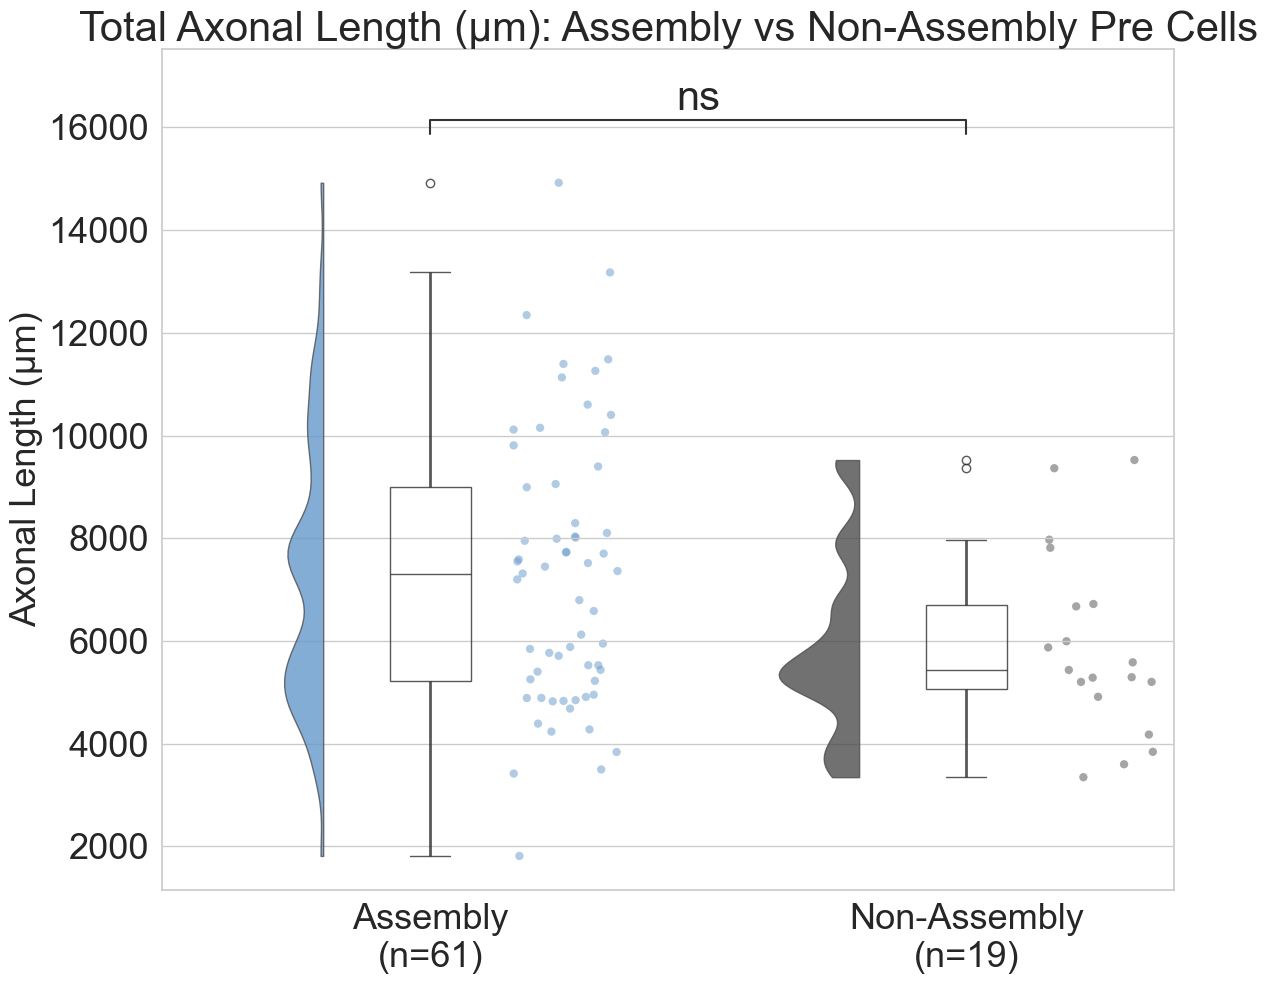

In [18]:
assembly_root_ids = set()
for group, roots in assembly_to_root_ids.items():
    if group != 'No A':
        assembly_root_ids.update(roots)

nonassembly_root_ids = set(assembly_to_root_ids.get('No A', []))

assembly_pre = list(pre_root_ids & assembly_root_ids)
nonassembly_pre = list(pre_root_ids & nonassembly_root_ids)

print(f"Assembly pre-cells: {len(assembly_pre)}")
print(f"Non-Assembly pre-cells: {len(nonassembly_pre)}")


# ---------------------------
# 1. Function: compute axon length from cached .npz
# ---------------------------

def compute_axon_length_from_npz(pre_id):
    """
    Computes total axonal length (µm) from cached .npz files in your format:
        coords_ax = axonal vertices (nm)
        edges_ax  = axonal edges
    """
    try:
        npz = np.load(CACHE_DIR / f"{pre_id}.npz")
        verts = npz["coords_ax"]      # (N,3) nm
        edges = npz["edges_ax"]       # (M,2)

        if verts.size == 0 or edges.size == 0:
            return 0.0

        segs = verts[edges]   # shape (M,2,3)
        lengths_nm = np.linalg.norm(segs[:,0] - segs[:,1], axis=1)

        return lengths_nm.sum() / 1000.0   # convert nm → µm

    except Exception as e:
        print(f"⚠️ Failed {pre_id}: {e}")
        return 0.0


# ---------------------------
# 2. Compute axonal lengths for all pre-cells
# ---------------------------

records = []

for cid in tqdm(pre_root_ids, desc="Computing axonal lengths"):
    axlen = compute_axon_length_from_npz(cid)
    group = "Assembly" if cid in assembly_root_ids else "NonAssembly"

    records.append({
        "cell_id": cid,
        "group": group,
        "axon_len_um": axlen
    })

axon_df = pd.DataFrame(records)

# ---------------------------
# 3. Separate into groups
# ---------------------------

assembly = axon_df[axon_df.group=="Assembly"]["axon_len_um"].values
no_assembly = axon_df[axon_df.group=="NonAssembly"]["axon_len_um"].values

print(f"Median Assembly axon length: {np.median(assembly):.1f} µm")
print(f"Median NonAssembly axon length: {np.median(no_assembly):.1f} µm")

# ---------------------------
# 4. Stats (your effect sizes)
# ---------------------------

mw_stat, mw_p = mannwhitneyu(assembly, no_assembly, alternative="two-sided", method="asymptotic")

hl  = hodges_lehmann(assembly, no_assembly, alternative="greater")
A_sh, delta = ps_and_delta(assembly, no_assembly, alternative="greater")
d   = cohens_d(assembly, no_assembly, alternative="greater")

print("\n=== AXON LENGTH TESTS ===")
print(f"Mann–Whitney U = {mw_stat:.4g}, p = {mw_p:.4g}")
print(f"Hodges–Lehmann median difference = {hl:.2f} µm")
print(f"Probability of Superiority A = {A_sh:.3f}")
print(f"Cliff’s delta = {delta:.3f}")
print(f"Cohen’s d = {d:.3f}")


# ---------------------------
# 5. Raincloud plot (inline)
# ---------------------------

label_A = f"Assembly\n(n={len(assembly)})"
label_N = f"Non-Assembly\n(n={len(no_assembly)})"

plot_df = pd.DataFrame({
    "Values": np.concatenate([assembly, no_assembly]),
    "Group": [label_A]*len(assembly) + [label_N]*len(no_assembly)
})

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

ax = pt.RainCloud(
    x="Group",
    y="Values",
    data=plot_df,
    palette=[(.4, .6, .8, .5), (.3, .3, .3, .5)],
    width_viol=0.3,
    alpha=0.8,
    move=0.25,
    point_size=6,
    orient="v"
)

# Significance annotation
pairs = [(label_A, label_N)]
annot = Annotator(ax,
                  pairs,
                  data=plot_df,
                  x="Group",
                  y="Values",
                  order=[label_A, label_N])

annot.set_pvalues([mw_p])
annot.configure(text_format="star",
                loc="inside",
                fontsize=30)
annot.annotate()

plt.title("Total Axonal Length (µm): Assembly vs Non-Assembly Pre Cells", fontsize=30)
plt.xlabel("", fontsize=26)
plt.ylabel("Axonal Length (µm)", fontsize=26)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26)

plt.tight_layout()
plt.show()
plt.close()

# shared v disjoint connection cotravel

Shared pairs: 4945
Disjoint pairs: 8475
Median Shared Co-Travel:   41.20 µm
Median Disjoint Co-Travel: 41.26 µm

=== SHARED vs DISJOINT COTRAVEL TESTS ===
Mann–Whitney U p = 0.5242
Hodges–Lehmann Δ = 0.01 µm
Probability of Superiority (A) = 0.500
Cliff’s delta = -0.001
Cohen’s d = -0.014
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=3757) vs. Disjoint
(n=6335): Custom statistical test, P_val:5.242e-01


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


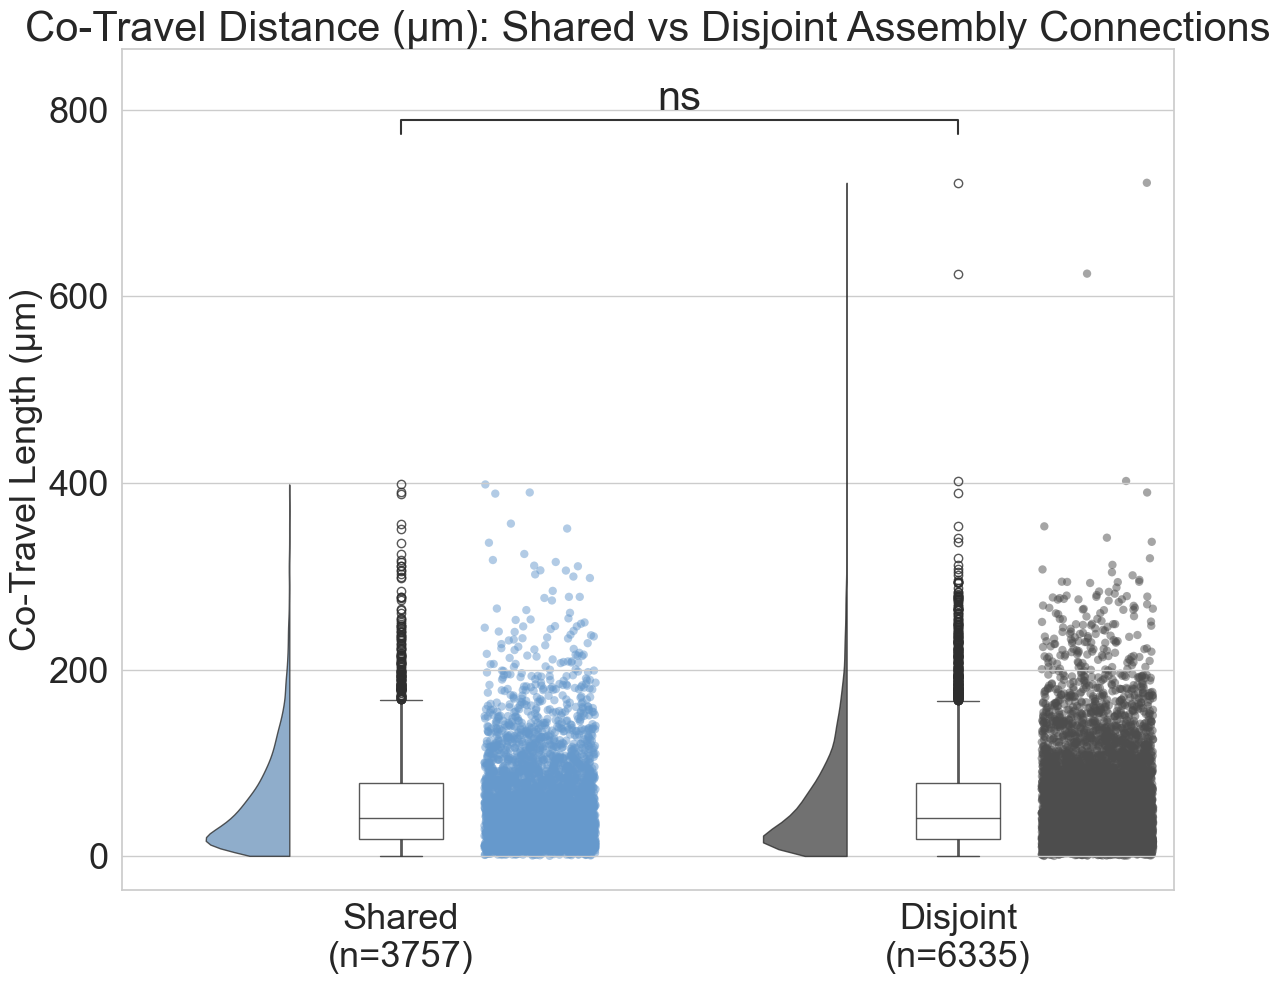

In [19]:
shared_pairs = []
disjoint_pairs = []

for (pre,post), cotravel in c.items():
    # if cotravel == 0:
    #     continue

    if shared(pre, post, A):
        shared_pairs.append((pre, post))

    elif disjoint(pre, post, A):
        disjoint_pairs.append((pre, post))

print(f"Shared pairs: {len(shared_pairs)}")
print(f"Disjoint pairs: {len(disjoint_pairs)}")

# ------------------------------------------------------
# 1. Extract cached cotravel values from dict c
# ------------------------------------------------------

shared_cotravel = np.array([c[(pre, post)] for (pre, post) in shared_pairs], float)
disjoint_cotravel = np.array([c[(pre, post)] for (pre, post) in disjoint_pairs], float)
# nonzero
shared_cotravel = shared_cotravel[shared_cotravel > 0]
disjoint_cotravel = disjoint_cotravel[disjoint_cotravel > 0]
# Convert nm → µm
shared_cotravel = shared_cotravel / 1000.0
disjoint_cotravel = disjoint_cotravel / 1000.0

S = shared_cotravel
D = disjoint_cotravel

print(f"Median Shared Co-Travel:   {np.median(S):.2f} µm")
print(f"Median Disjoint Co-Travel: {np.median(D):.2f} µm")


# ------------------------------------------------------
# 2. Stats 
# ------------------------------------------------------

mw_stat, mw_p = mannwhitneyu(S, D, alternative="greater", method="asymptotic")
hl = hodges_lehmann(S, D, alternative="greater")
A_sh, delta = ps_and_delta(S, D, alternative="greater")
d = cohens_d(S, D, alternative="greater")

print("\n=== SHARED vs DISJOINT COTRAVEL TESTS ===")
print(f"Mann–Whitney U p = {mw_p:.4g}")
print(f"Hodges–Lehmann Δ = {hl:.2f} µm")
print(f"Probability of Superiority (A) = {A_sh:.3f}")
print(f"Cliff’s delta = {delta:.3f}")
print(f"Cohen’s d = {d:.3f}")

# ------------------------------------------------------
# 3. Raincloud Plot (inline)
# ------------------------------------------------------

label_S = f"Shared\n(n={len(S)})"
label_D = f"Disjoint\n(n={len(D)})"

plot_df = pd.DataFrame({
    "Values": np.concatenate([S, D]),
    "Group": [label_S]*len(S) + [label_D]*len(D)
})

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

ax = pt.RainCloud(
    x="Group",
    y="Values",
    hue="Group",
    data=plot_df,
    palette=[(.4, .6, .8, .5), (.3, .3, .3, .5)],
    width_viol=0.3,
    alpha=0.8,
    move=0.25,
    point_size=6,
    orient="v"
)

pairs = [(label_S, label_D)]
annot = Annotator(
    ax,
    pairs,
    data=plot_df,
    x="Group",
    y="Values",
    order=[label_S, label_D]
)

annot.set_pvalues([mw_p])
annot.configure(
    text_format="star",
    loc="inside",
    fontsize=30
)

annot.annotate() 

plt.title("Co-Travel Distance (µm): Shared vs Disjoint Assembly Connections", fontsize=30)
plt.xlabel("", fontsize=26)
plt.ylabel("Co-Travel Length (µm)", fontsize=26)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26)

plt.tight_layout()
plt.show()
plt.close()

# shared a v shared no a cotravel length

Assembly pairs: 13420
No Assembly pairs: 1767
Median Shared Co-Travel:   41.26 µm
Median Disjoint Co-Travel: 34.04 µm

=== SHARED A vs SHARED NO A COTRAVEL TESTS ===
Mann–Whitney U p = 8.77e-09
Hodges–Lehmann Δ = 5.17 µm
Probability of Superiority (A) = 0.551
Cliff’s delta = 0.101
Cohen’s d = 0.172
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Both A
(n=10092) vs. Both No A
(n=1148): Custom statistical test, P_val:8.770e-09


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


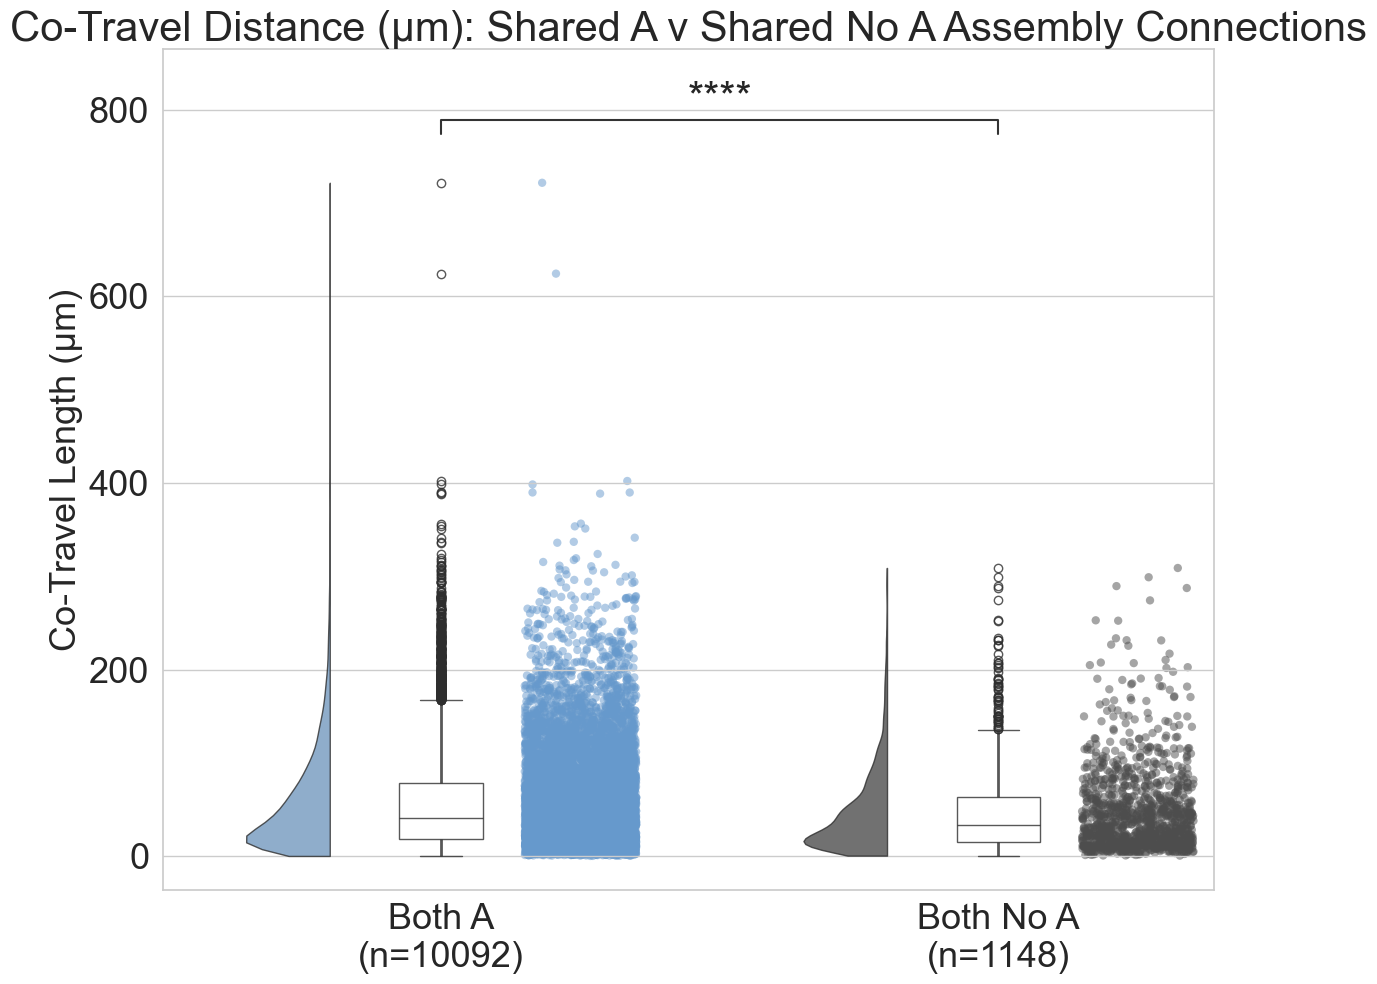

In [20]:
shared_a_pairs = []
shared_no_a_pairs = []

for (pre,post), cotravel in c.items():
    # if cotravel == 0:
    #     continue

    if shared_a(pre, post, A):
        shared_a_pairs.append((pre, post))

    elif shared_no_a(pre, post, A):
        shared_no_a_pairs.append((pre, post))

print(f"Assembly pairs: {len(shared_a_pairs)}")
print(f"No Assembly pairs: {len(shared_no_a_pairs)}")

# ------------------------------------------------------
# 1. Extract cached cotravel values from dict c
# ------------------------------------------------------

a_cotravel = np.array([c[(pre, post)] for (pre, post) in shared_a_pairs], float)
no_a_cotravel = np.array([c[(pre, post)] for (pre, post) in shared_no_a_pairs], float)
# nonzero
a_cotravel = a_cotravel[a_cotravel > 0]
no_a_cotravel = no_a_cotravel[no_a_cotravel > 0]
# Convert nm → µm
a_cotravel = a_cotravel / 1000.0
no_a_cotravel = no_a_cotravel / 1000.0

S = a_cotravel
D = no_a_cotravel

print(f"Median Shared Co-Travel:   {np.median(S):.2f} µm")
print(f"Median Disjoint Co-Travel: {np.median(D):.2f} µm")


# ------------------------------------------------------
# 2. Stats
# ------------------------------------------------------

mw_stat, mw_p = mannwhitneyu(S, D, alternative="greater", method="asymptotic")
hl = hodges_lehmann(S, D, alternative="greater")
A_sh, delta = ps_and_delta(S, D, alternative="greater")
d = cohens_d(S, D, alternative="greater")

print("\n=== SHARED A vs SHARED NO A COTRAVEL TESTS ===")
print(f"Mann–Whitney U p = {mw_p:.4g}")
print(f"Hodges–Lehmann Δ = {hl:.2f} µm")
print(f"Probability of Superiority (A) = {A_sh:.3f}")
print(f"Cliff’s delta = {delta:.3f}")
print(f"Cohen’s d = {d:.3f}")

# ------------------------------------------------------
# 3. Raincloud Plot (inline)
# ------------------------------------------------------

label_S = f"Both A\n(n={len(S)})"
label_D = f"Both No A\n(n={len(D)})"

plot_df = pd.DataFrame({
    "Values": np.concatenate([S, D]),
    "Group": [label_S]*len(S) + [label_D]*len(D)
})

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

ax = pt.RainCloud(
    x="Group",
    y="Values",
    hue="Group",
    data=plot_df,
    palette=[(.4, .6, .8, .5), (.3, .3, .3, .5)],
    width_viol=0.3,
    alpha=0.8,
    move=0.25,
    point_size=6,
    orient="v"
)

pairs = [(label_S, label_D)]
annot = Annotator(
    ax,
    pairs,
    data=plot_df,
    x="Group",
    y="Values",
    order=[label_S, label_D]
)

annot.set_pvalues([mw_p])
annot.configure(
    text_format="star",
    loc="inside",
    fontsize=30
)

annot.annotate() 

plt.title("Co-Travel Distance (µm): Shared A v Shared No A Assembly Connections", fontsize=30)
plt.xlabel("", fontsize=26)
plt.ylabel("Co-Travel Length (µm)", fontsize=26)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26)

plt.tight_layout()
plt.show()
plt.close()

# Synaptic Count Distributions By Connection Type

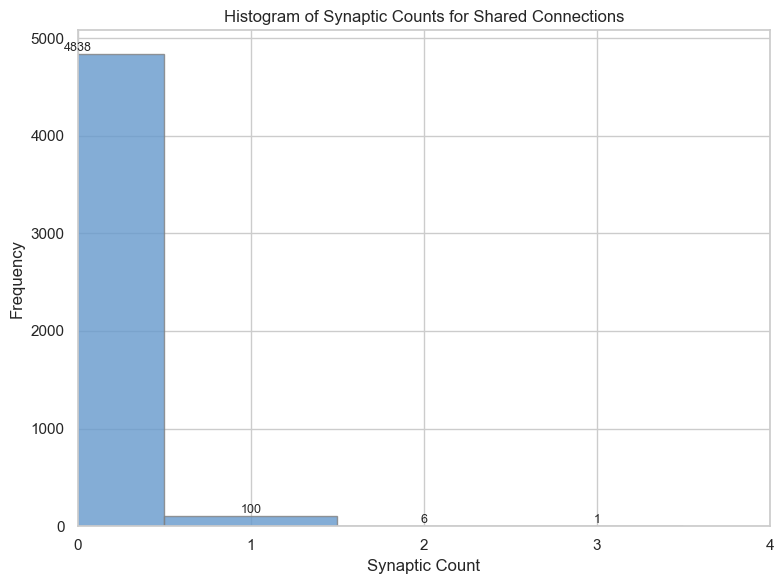

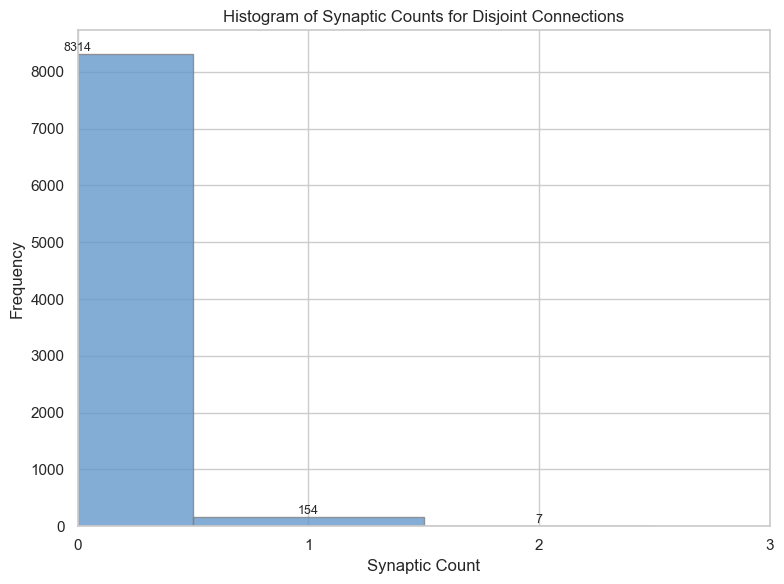

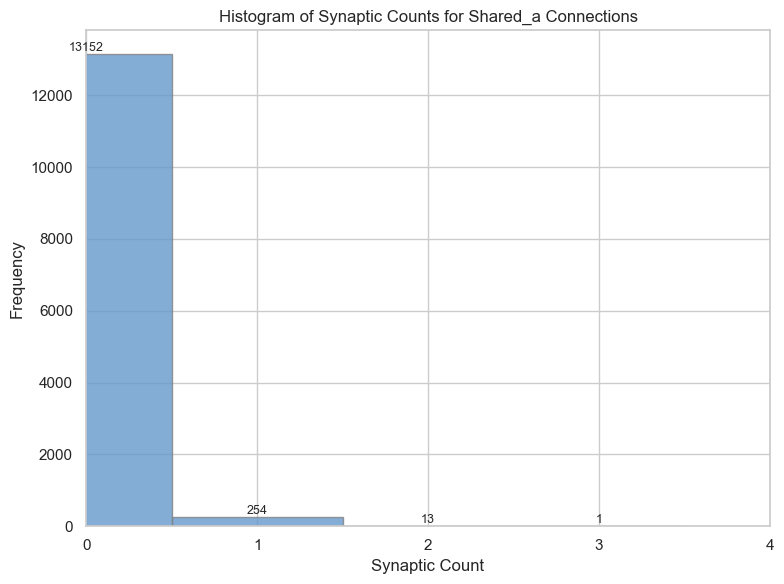

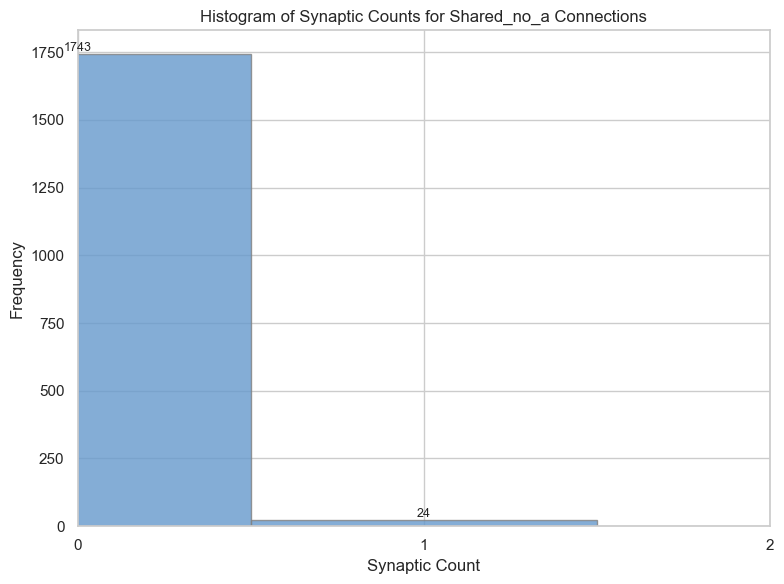

In [22]:
for group in groups:
    synaptic_count_histogram(
        values_dict=S_pairwise[group],
        connection_type=group,
        save=False,
        figure_name=None
    )

# Report Results

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.1762, P-value: 0.5699

[UNPAIRED] Effect sizes (pos = 'greater')  n1=107, n2=161
  Test p-value: 0.5703
  Shared median = 0.00659381, Disjoint median = 0.00626211

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.000112995 : CI [-0.00126172, 0.000940501]
    PS:       0.494 : CI [0.424, 0.559]   (δ=-0.013 : CI [-0.152, 0.118])
    Cohen's d: 0.053 : CI [-0.203, 0.275]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.000112995 : CI [-0.00128304, 0.000929475]
    PS:       0.494 : CI [0.428, 0.560]   (δ=-0.013 : CI [-0.145, 0.120])
    Cohen's d: 0.053 : CI [-0.199, 0.276]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:5.699e-01


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


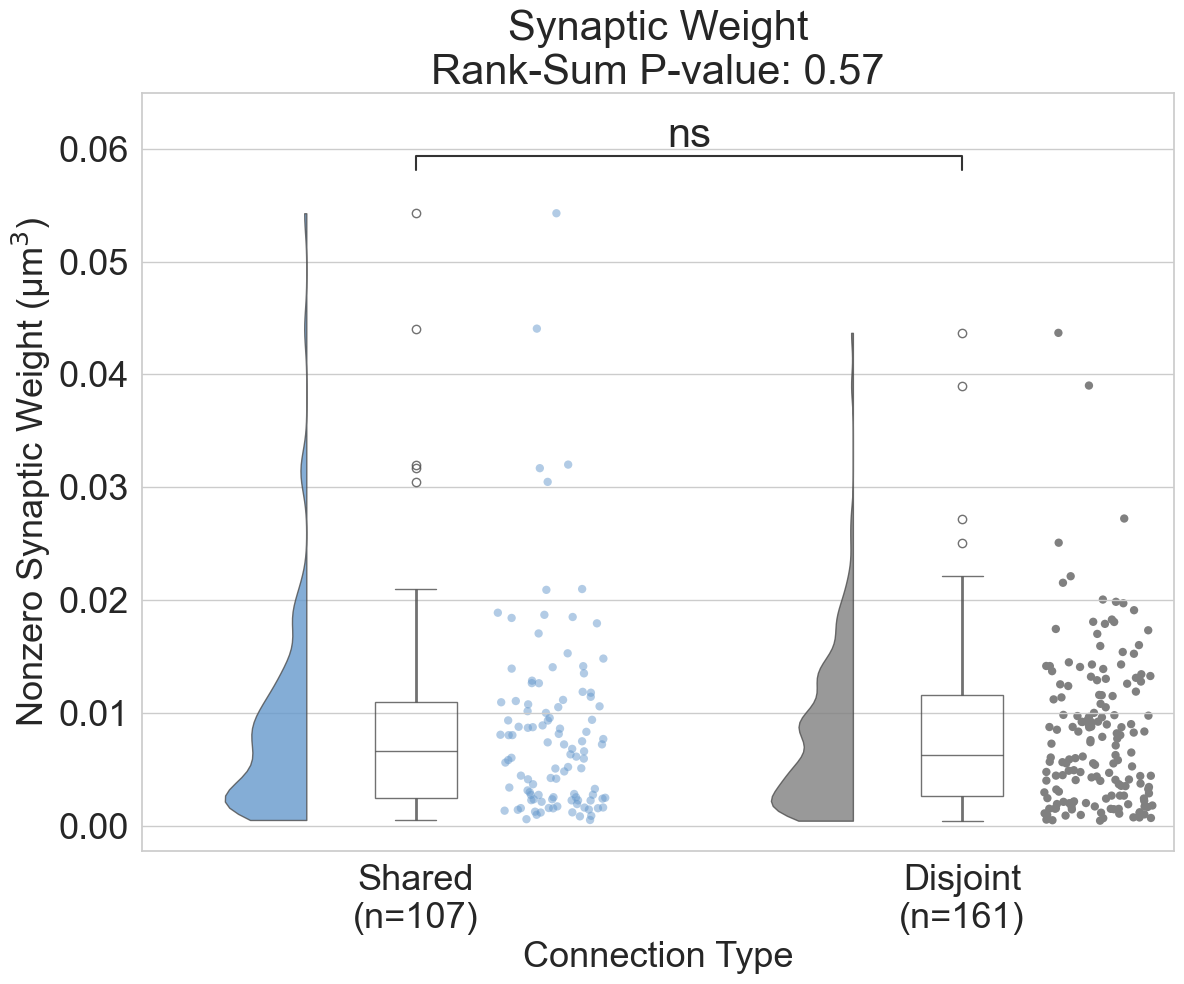

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:5.699e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


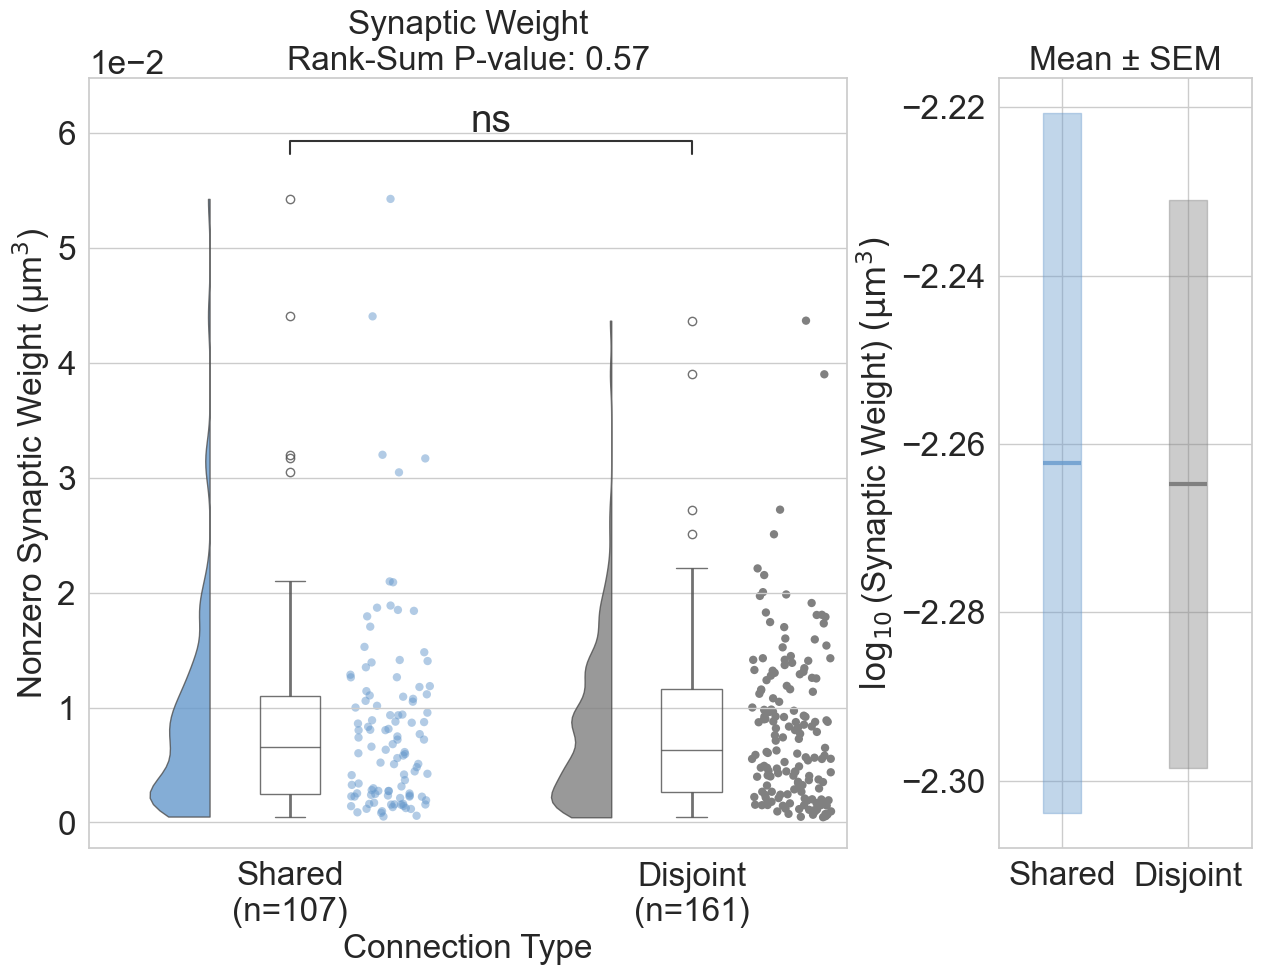

In [23]:
ranksum_signedrank_two_group_comparison(W_nonzero_pairwise,
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.7041, P-value: 0.7593

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=61
  Test p-value: 0.7618
  Shared median = 0.0103093, Disjoint median = 0.0162602

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.00078901 : CI [-0.00813008, 0.00398057]
    PS:       0.463 : CI [0.356, 0.563]   (δ=-0.074 : CI [-0.289, 0.127])
    Cohen's d: 0.123 : CI [-0.258, 0.435]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.00078901 : CI [-0.00813008, 0.00420008]
    PS:       0.463 : CI [0.358, 0.567]   (δ=-0.074 : CI [-0.284, 0.134])
    Cohen's d: 0.123 : CI [-0.254, 0.457]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 916.5, P-value: 0.406

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=61
  Test p-value: 0.406
  Median paired difference = 0

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [-0.00892857, 0.00703443]
    PS:       0.492 : CI [0.

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


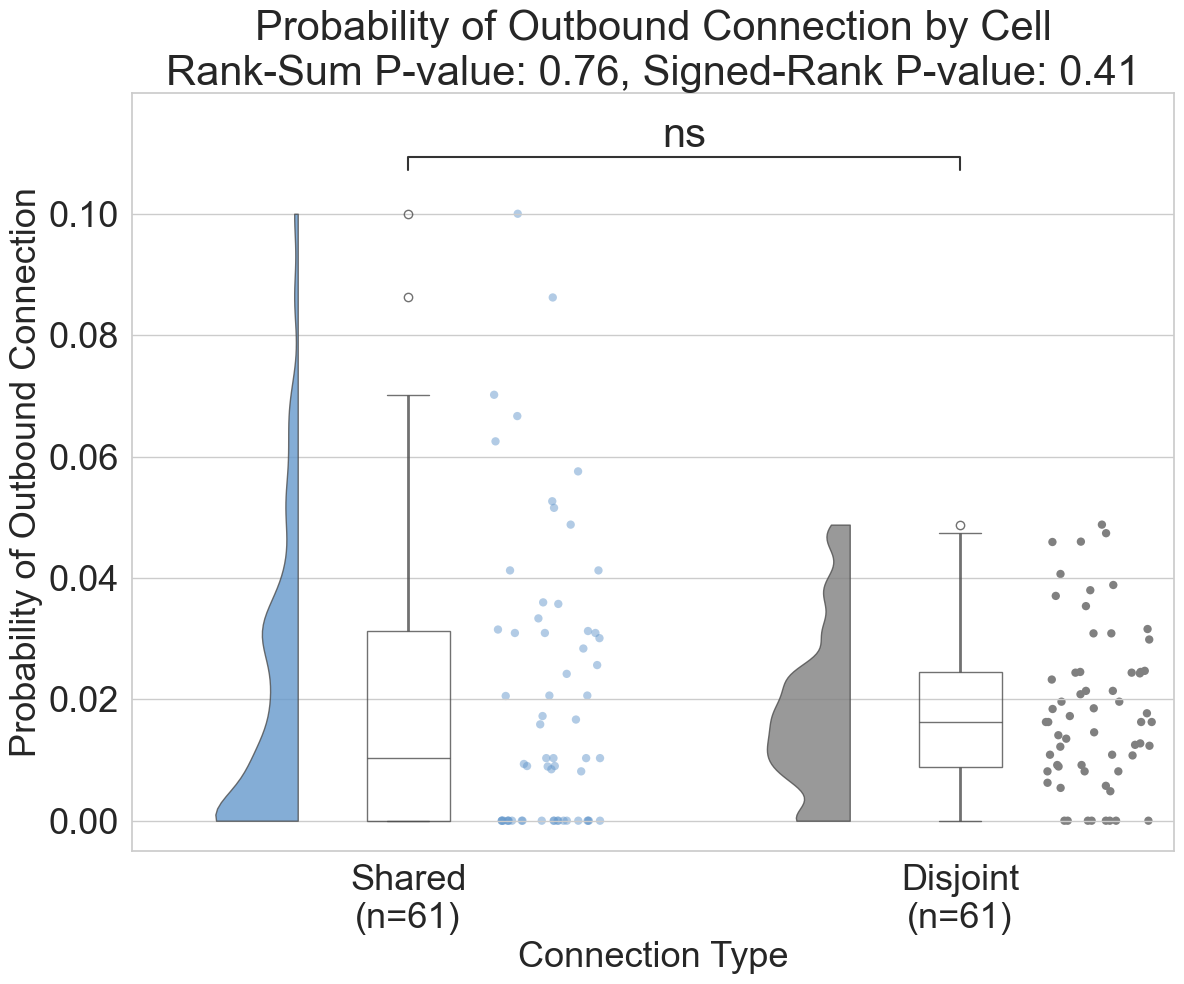

C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  wa

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=61) vs. Disjoint
(n=61): Custom statistical test, P_val:7.593e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


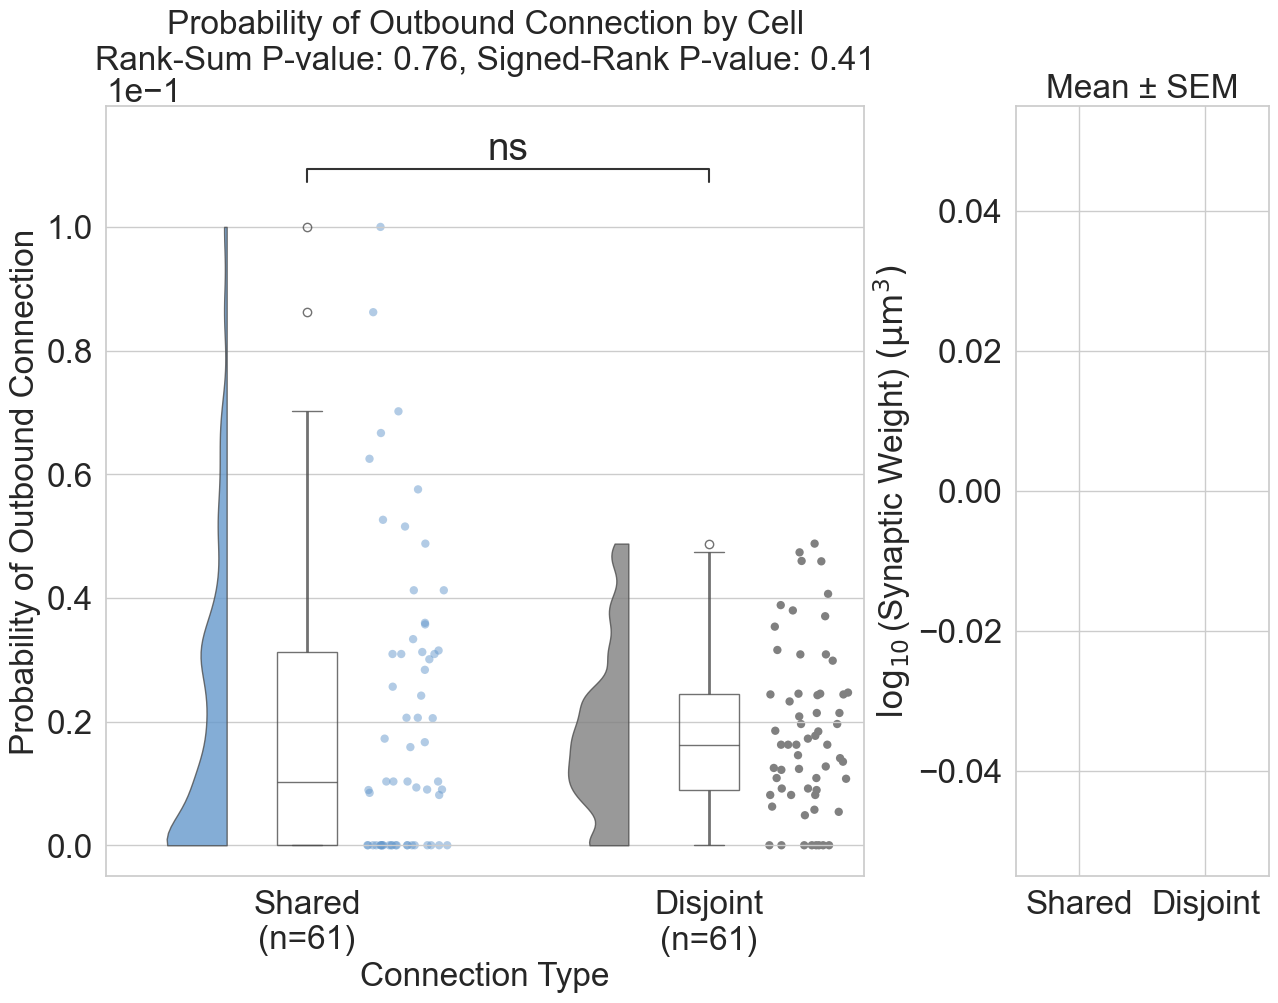

In [24]:
ranksum_signedrank_two_group_comparison(B_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        save=True,
                                        figure_name='Prob_Outbound_Conn'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.2647, P-value: 0.6044

[UNPAIRED] Effect sizes (pos = 'greater')  n1=39, n2=53
  Test p-value: 0.6059
  Shared median = 0.00702027, Disjoint median = 0.00672958

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.00028674 : CI [-0.00219758, 0.00161663]
    PS:       0.484 : CI [0.359, 0.608]   (δ=-0.032 : CI [-0.281, 0.216])
    Cohen's d: -0.041 : CI [-0.465, 0.388]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.00028674 : CI [-0.00219672, 0.00161656]
    PS:       0.484 : CI [0.359, 0.605]   (δ=-0.032 : CI [-0.281, 0.210])
    Cohen's d: -0.041 : CI [-0.453, 0.397]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 266, P-value: 0.6043

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=33
  Test p-value: 0.6043
  Median paired difference = -0.000307395

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.000307395 : CI [-0.00232259, 0.00212261]
  

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


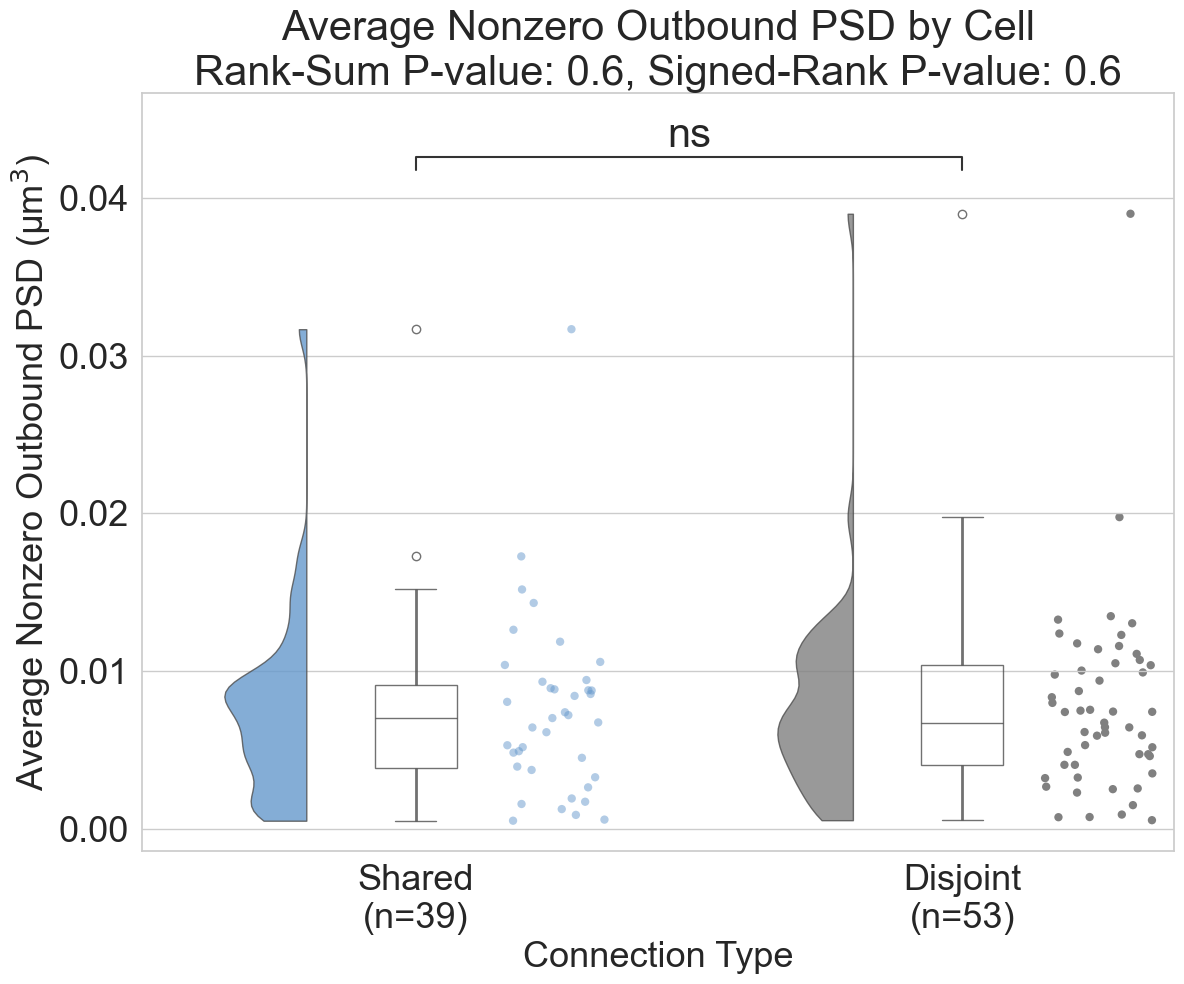

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=39) vs. Disjoint
(n=53): Custom statistical test, P_val:6.044e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


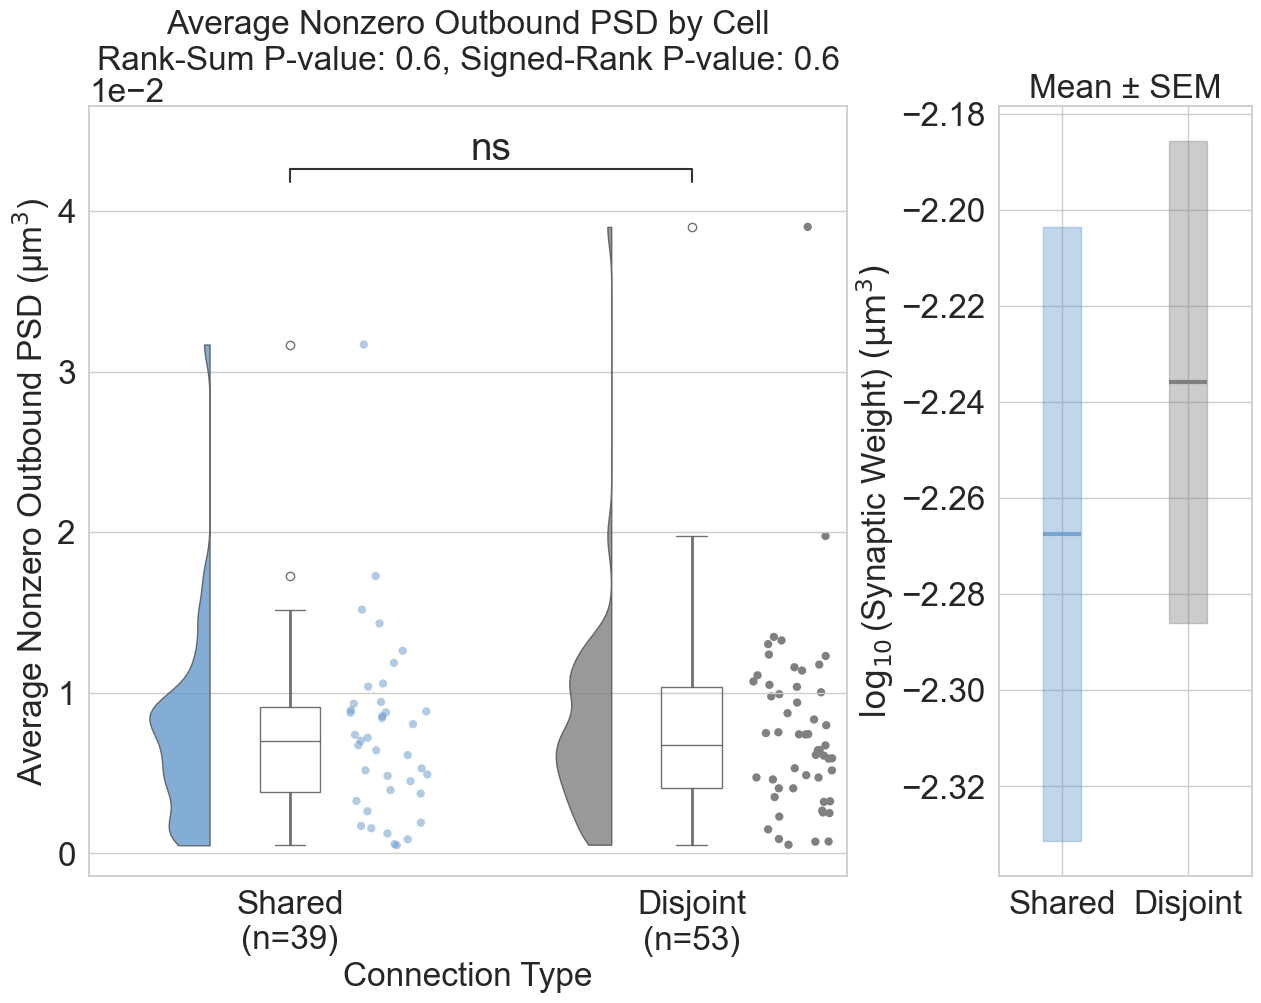

In [25]:
ranksum_signedrank_two_group_comparison(W_nonzero_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        paired=True,
                                        non_zero=True,
                                        save=True,
                                        figure_name = 'Avg_Nonzero_Outbound_PSD'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -1.755, P-value: 0.9603


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to


[UNPAIRED] Effect sizes (pos = 'greater')  n1=220, n2=221
  Test p-value: 0.9767
  Shared median = 0, Disjoint median = 0

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.452 : CI [0.405, 0.498]   (δ=-0.097 : CI [-0.190, -0.004])
    Cohen's d: 0.007 : CI [-0.190, 0.186]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.452 : CI [0.406, 0.500]   (δ=-0.097 : CI [-0.188, -0.001])
    Cohen's d: 0.007 : CI [-0.175, 0.199]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 4262, P-value: 0.7186

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=220
  Test p-value: 0.7186
  Median paired difference = 0

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.436 : CI [0.384, 0.489]   (δ=-0.127 : CI [-0.232, -0.023])
    Cohen's d: 0.006 : CI [-0.143, 0.126]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:     

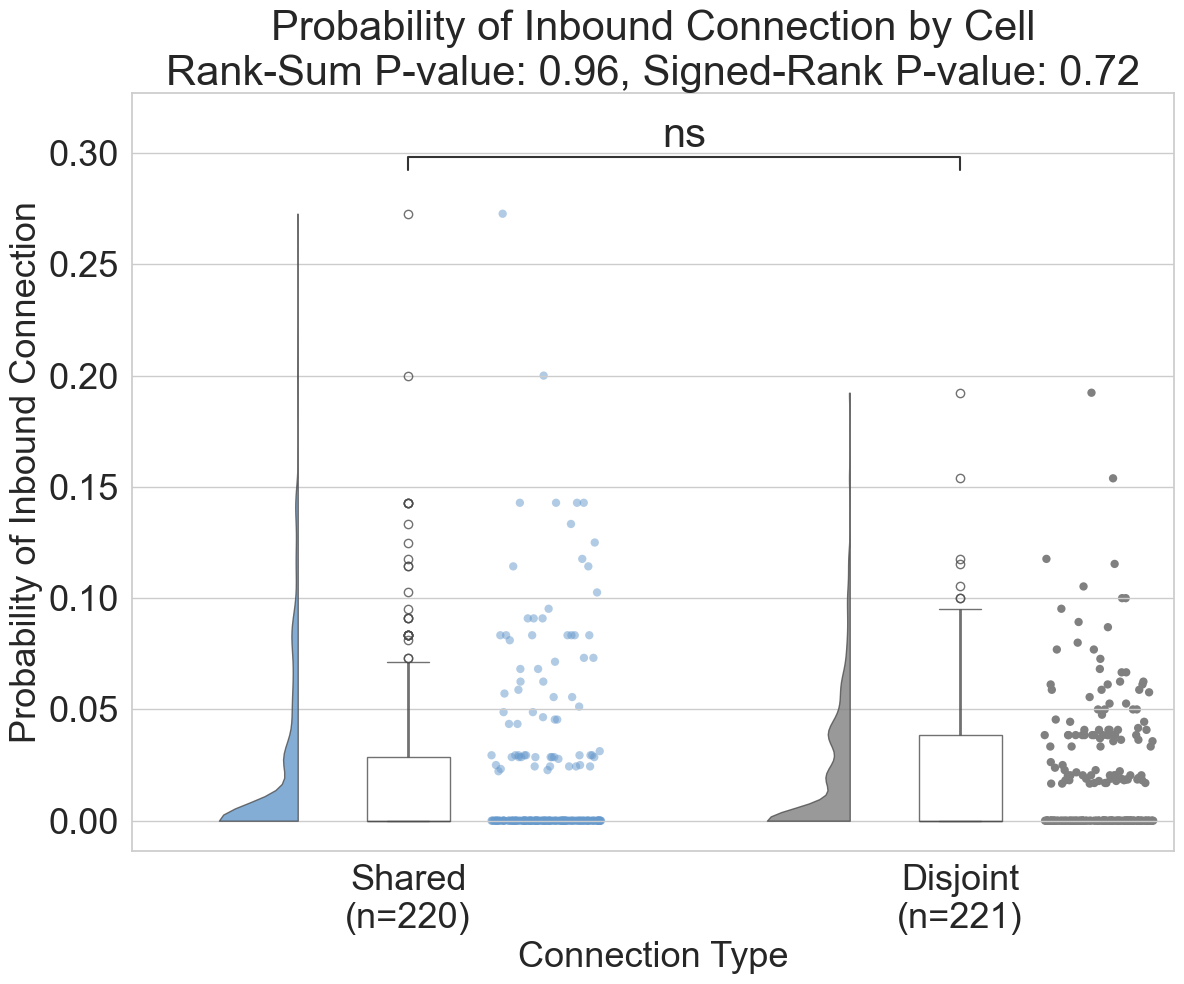

C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  wa

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=220) vs. Disjoint
(n=221): Custom statistical test, P_val:9.603e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


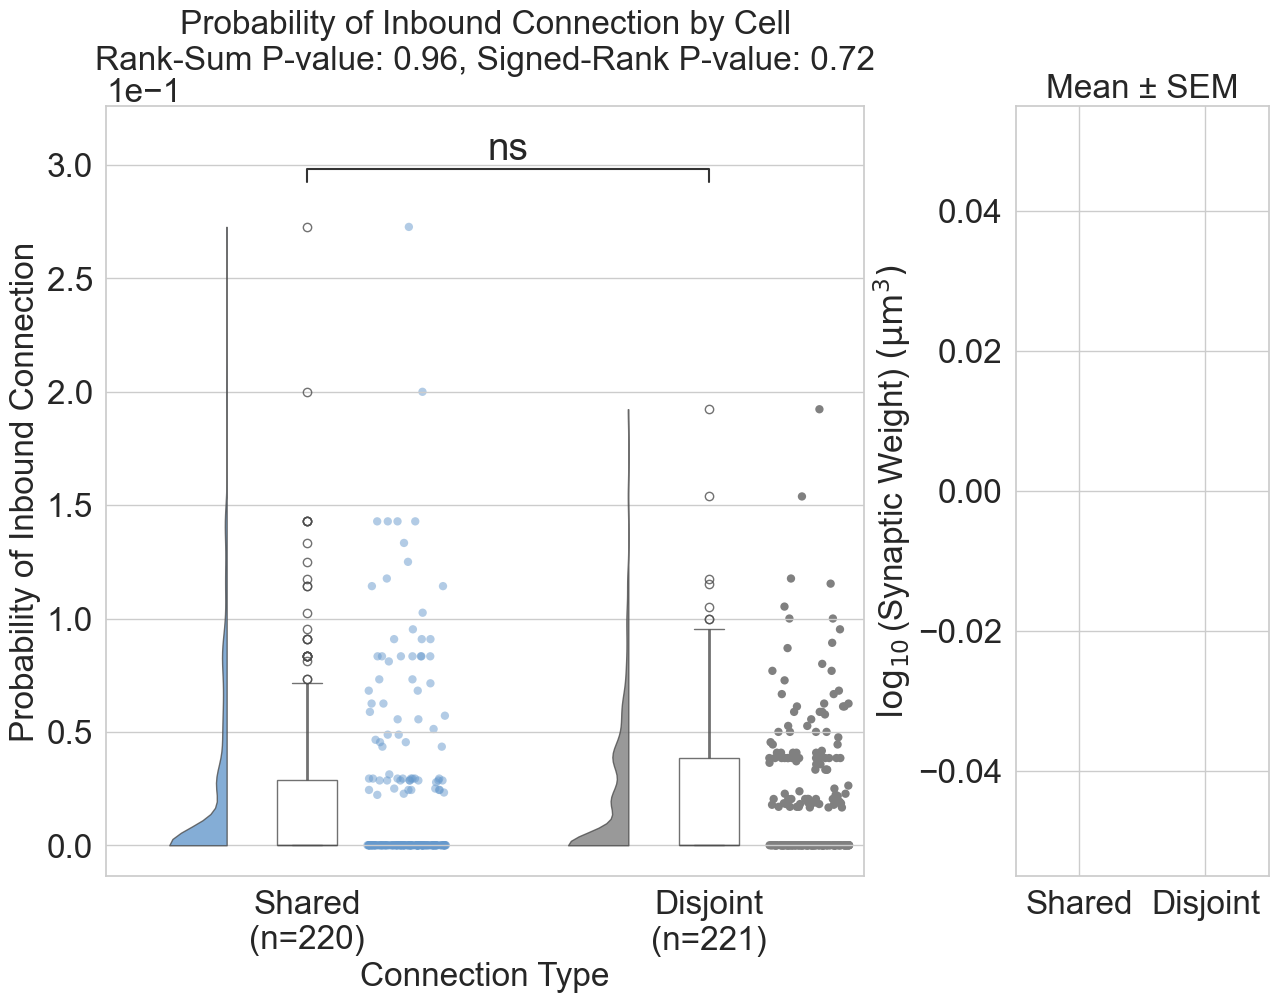

In [26]:
ranksum_signedrank_two_group_comparison(B_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        save=True,
                                        figure_name='Prob_Inbound_Conn'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.1347, P-value: 0.5536

[UNPAIRED] Effect sizes (pos = 'greater')  n1=71, n2=103
  Test p-value: 0.5542
  Shared median = 0.00720981, Disjoint median = 0.00727178

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.000130309 : CI [-0.00157865, 0.00142374]
    PS:       0.494 : CI [0.410, 0.585]   (δ=-0.012 : CI [-0.180, 0.170])
    Cohen's d: 0.036 : CI [-0.265, 0.331]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.000130309 : CI [-0.00153819, 0.00148352]
    PS:       0.494 : CI [0.414, 0.588]   (δ=-0.012 : CI [-0.172, 0.175])
    Cohen's d: 0.036 : CI [-0.232, 0.362]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 431, P-value: 0.288

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=39
  Test p-value: 0.288
  Median paired difference = 0.000275197

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.000275197 : CI [-0.00190998, 0.00312377]
    P

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


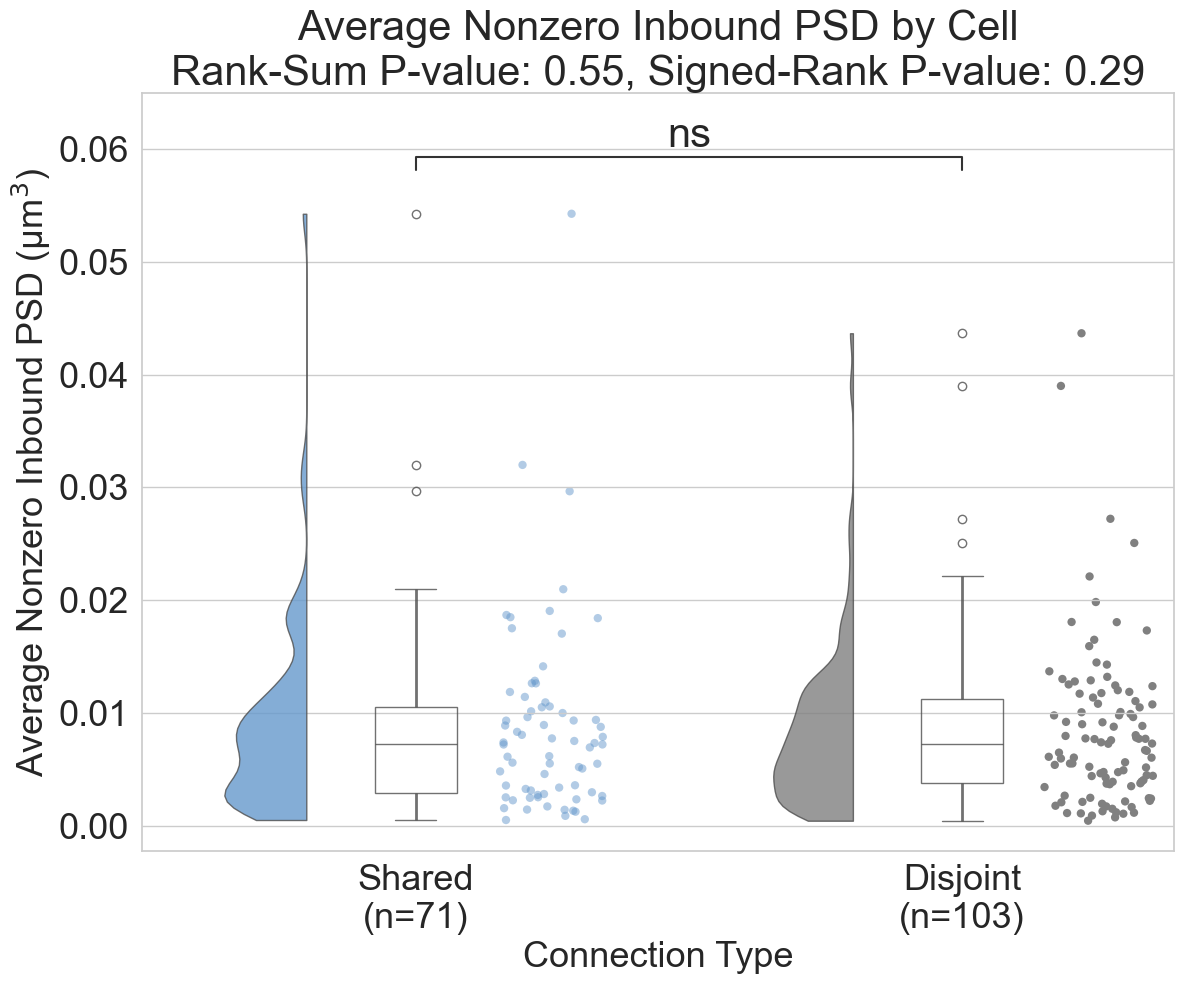

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=71) vs. Disjoint
(n=103): Custom statistical test, P_val:5.536e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


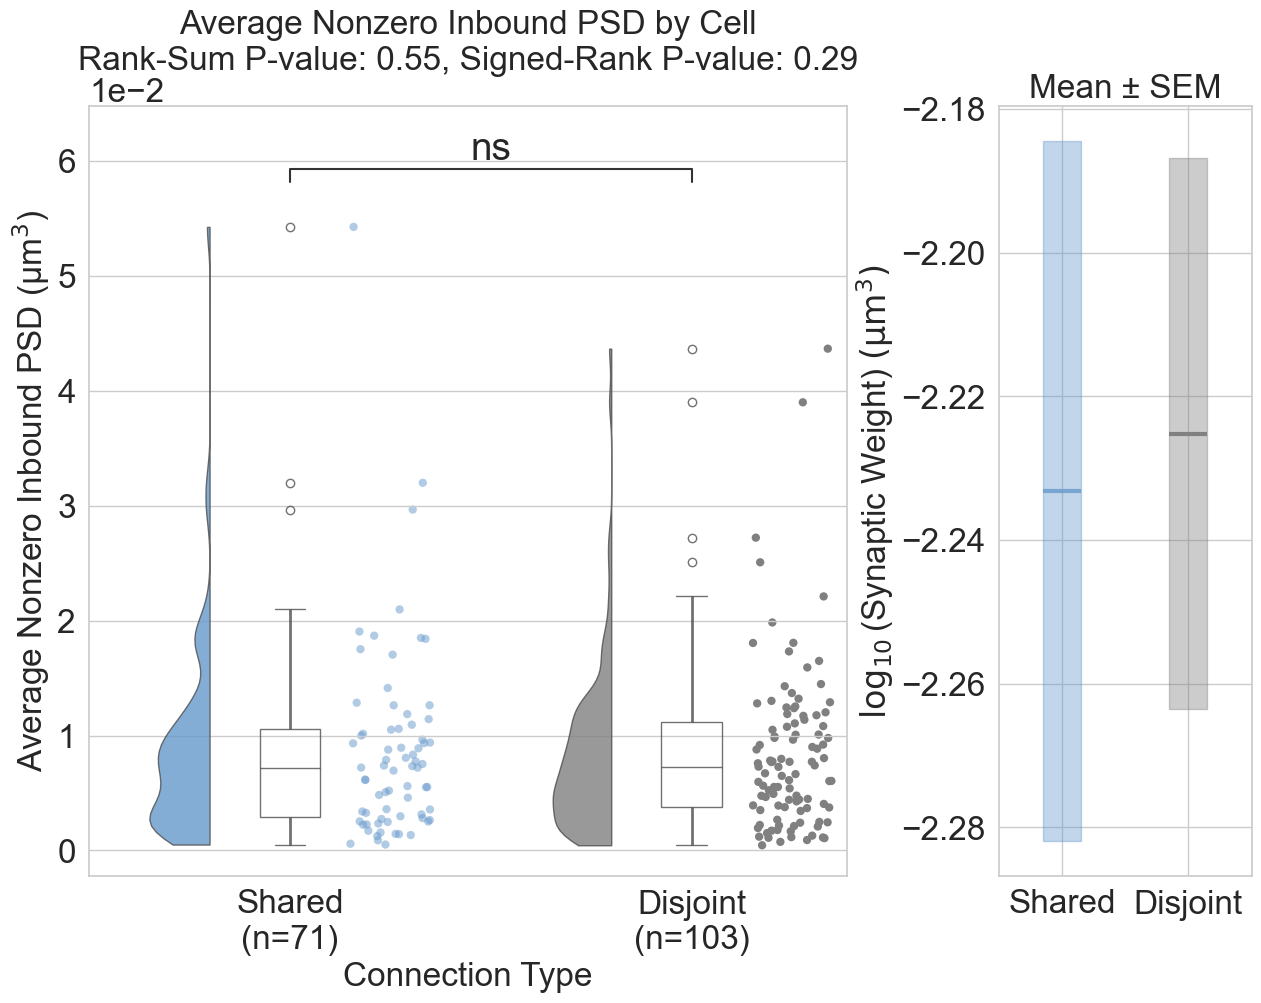

In [27]:
ranksum_signedrank_two_group_comparison(W_nonzero_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        paired=True,
                                        non_zero=True,
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD'
                                        )

# Normalized Synaptic Counts (Mirrored to PSD)

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3098, P-value: 0.3784

[UNPAIRED] Effect sizes (pos = 'greater')  n1=107, n2=161
  Test p-value: 0.2114
  Shared median = 1, Disjoint median = 1

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.511 : CI [0.486, 0.539]   (δ=0.022 : CI [-0.028, 0.078])
    Cohen's d: 0.127 : CI [-0.111, 0.353]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.511 : CI [0.486, 0.539]   (δ=0.022 : CI [-0.028, 0.079])
    Cohen's d: 0.127 : CI [-0.109, 0.359]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:3.784e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


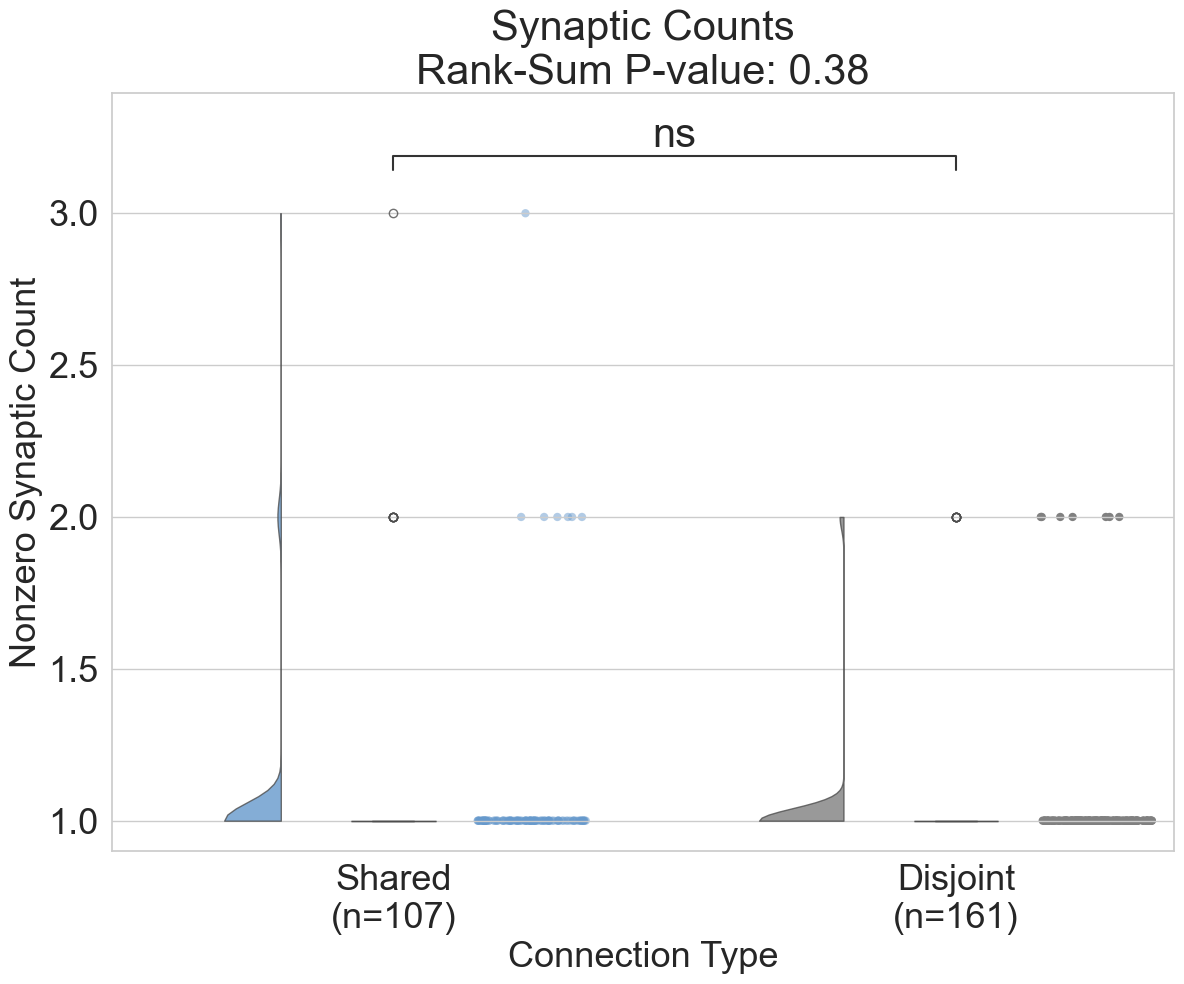

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:3.784e-01


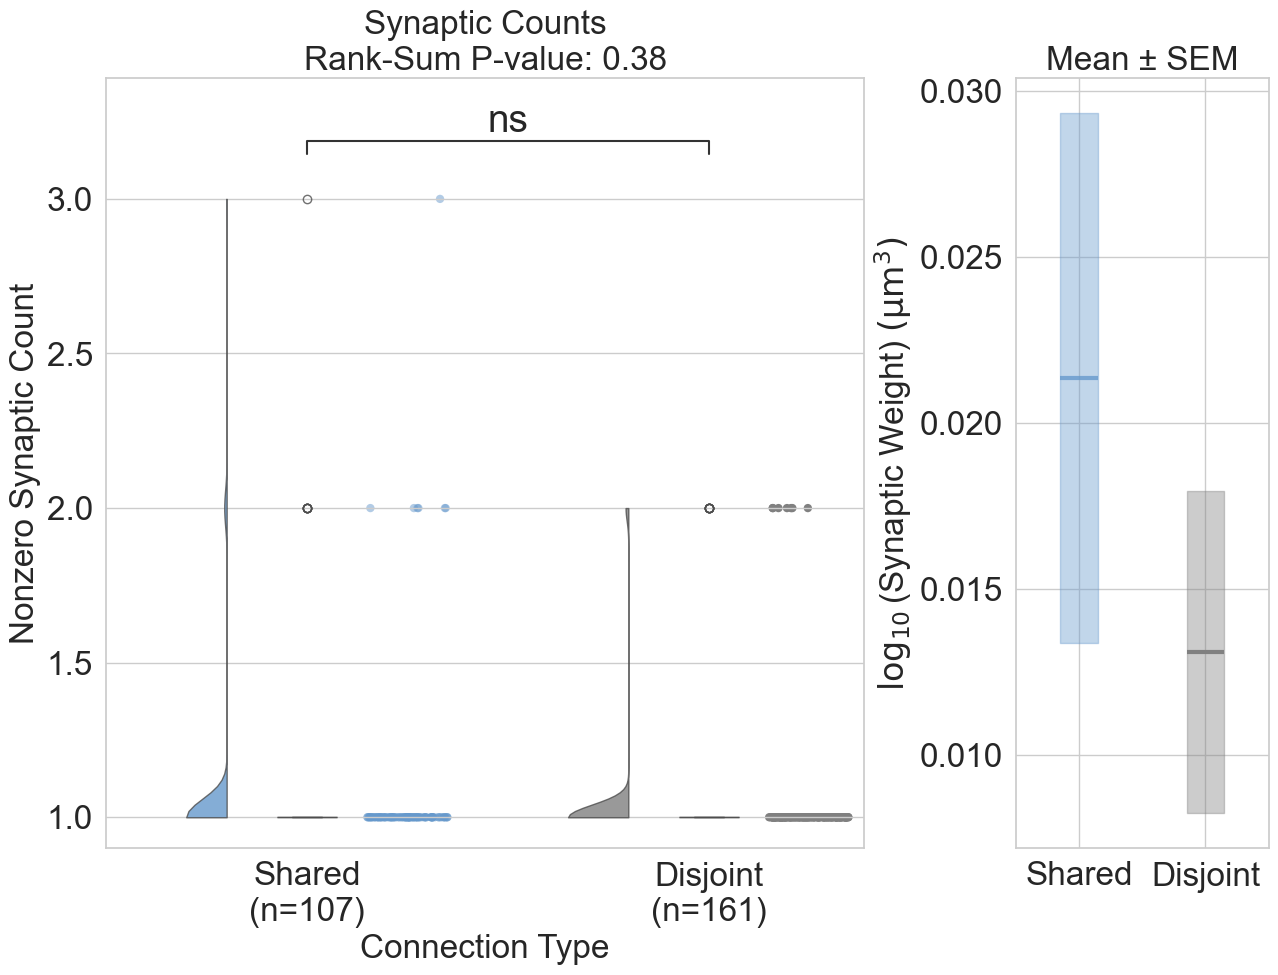

In [28]:
ranksum_signedrank_two_group_comparison(S_pairwise,
                                        aggregation_method='connection',
                                        data_type='synaptic_count',
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3555, P-value: 0.3611


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\scipy\stats\_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\scipy\stats\_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:131: RuntimeWarning: invalid value encountered in scalar mu


[UNPAIRED] Effect sizes (pos = 'greater')  n1=39, n2=53
  Test p-value: 0.274
  Shared median = 1, Disjoint median = 1

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.522 : CI [0.455, 0.595]   (δ=0.044 : CI [-0.090, 0.189])
    Cohen's d: 0.210 : CI [-0.267, 0.550]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.522 : CI [0.456, 0.596]   (δ=0.044 : CI [-0.089, 0.192])
    Cohen's d: 0.210 : CI [-0.231, 0.578]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 17.5, P-value: 0.2767

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=33
  Test p-value: 0.2767
  Median paired difference = 0

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.515 : CI [0.439, 0.591]   (δ=0.030 : CI [-0.121, 0.182])
    Cohen's d: 0.129 : CI [-0.256, 0.394]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.515 : 

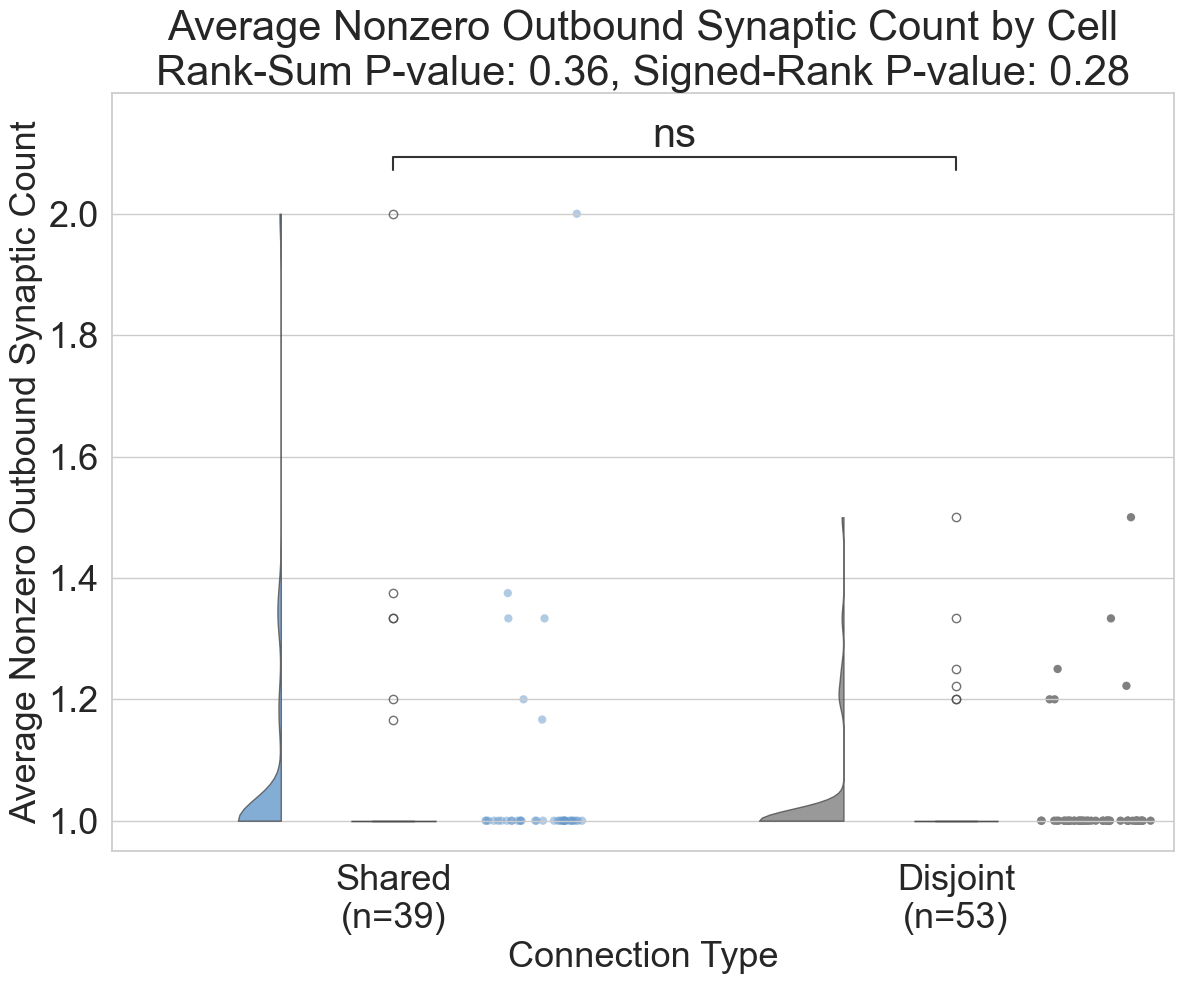

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=39) vs. Disjoint
(n=53): Custom statistical test, P_val:3.611e-01


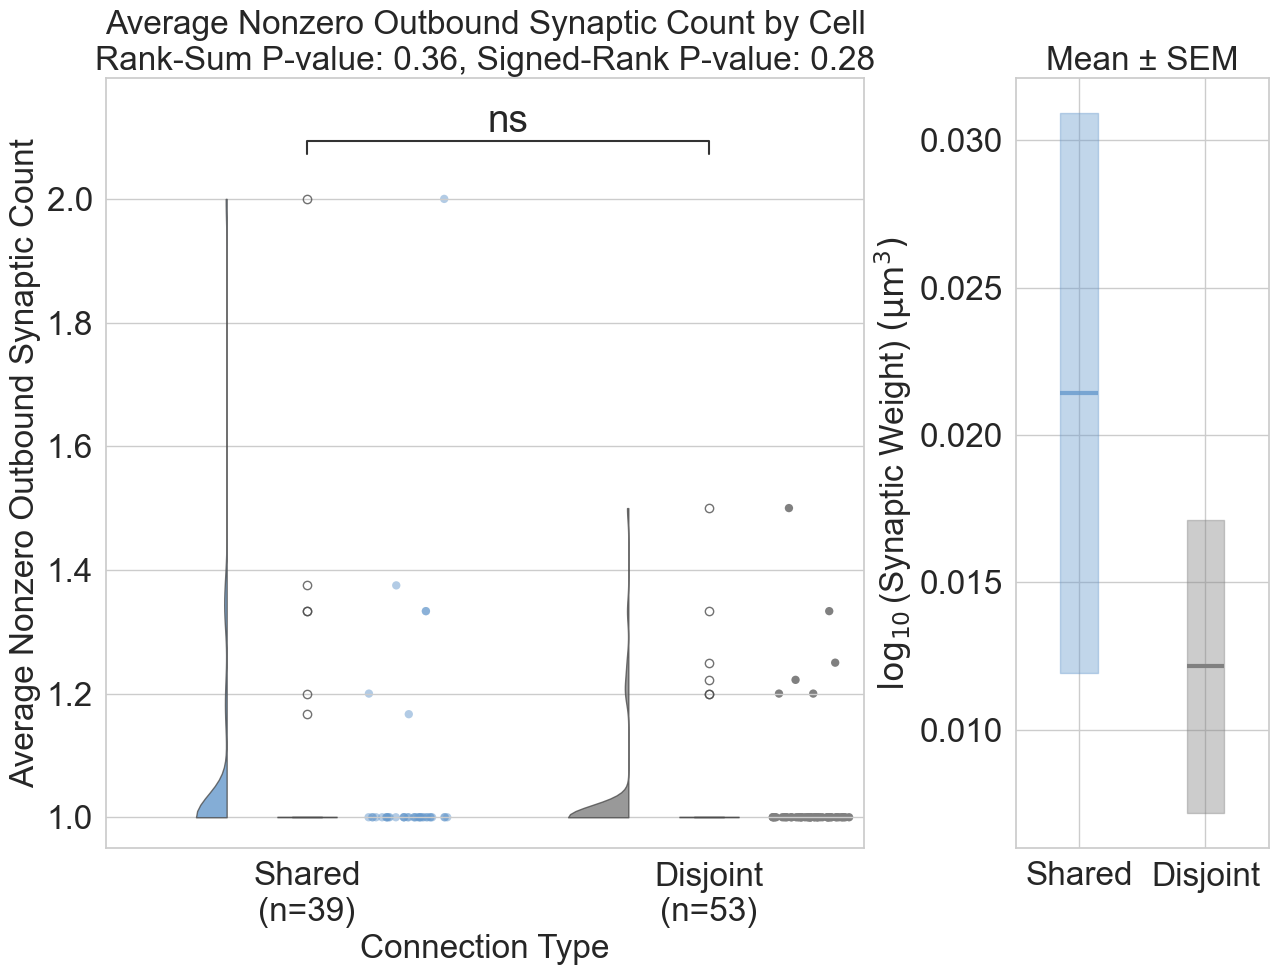

In [29]:
ranksum_signedrank_two_group_comparison(S_nonzero_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.4394, P-value: 0.3302


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\scipy\stats\_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\scipy\stats\_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\548594465.py:131: RuntimeWarning: invalid value encountered in scalar mu


[UNPAIRED] Effect sizes (pos = 'greater')  n1=71, n2=103
  Test p-value: 0.1684
  Shared median = 1, Disjoint median = 1

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.520 : CI [0.480, 0.563]   (δ=0.039 : CI [-0.040, 0.126])
    Cohen's d: 0.143 : CI [-0.195, 0.416]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.520 : CI [0.485, 0.571]   (δ=0.039 : CI [-0.030, 0.143])
    Cohen's d: 0.143 : CI [-0.147, 0.469]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 13, P-value: 0.2981

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=39
  Test p-value: 0.2981
  Median paired difference = 0

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.526 : CI [0.462, 0.590]   (δ=0.051 : CI [-0.077, 0.179])
    Cohen's d: 0.105 : CI [-0.217, 0.362]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.526 : 

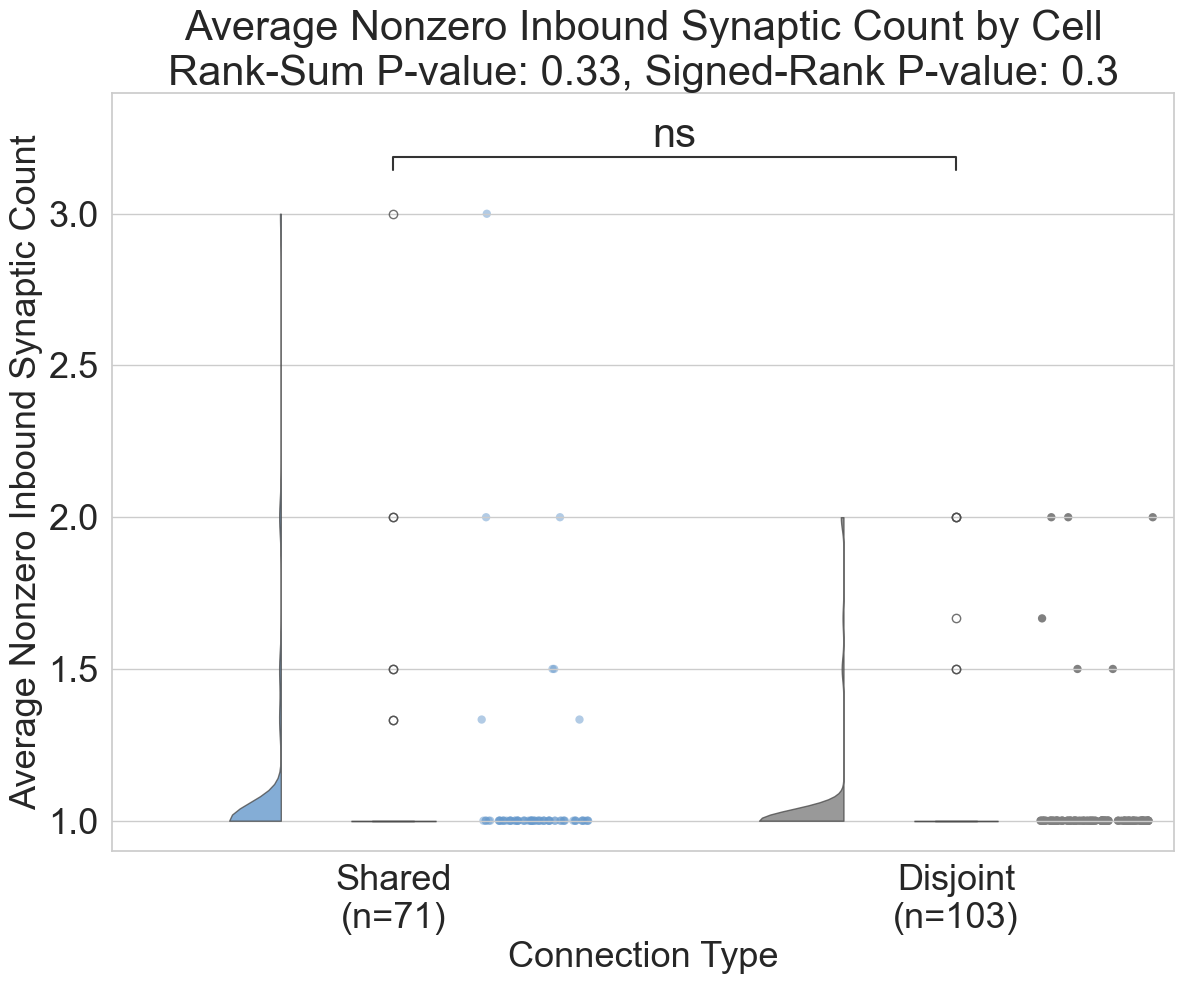

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=71) vs. Disjoint
(n=103): Custom statistical test, P_val:3.302e-01


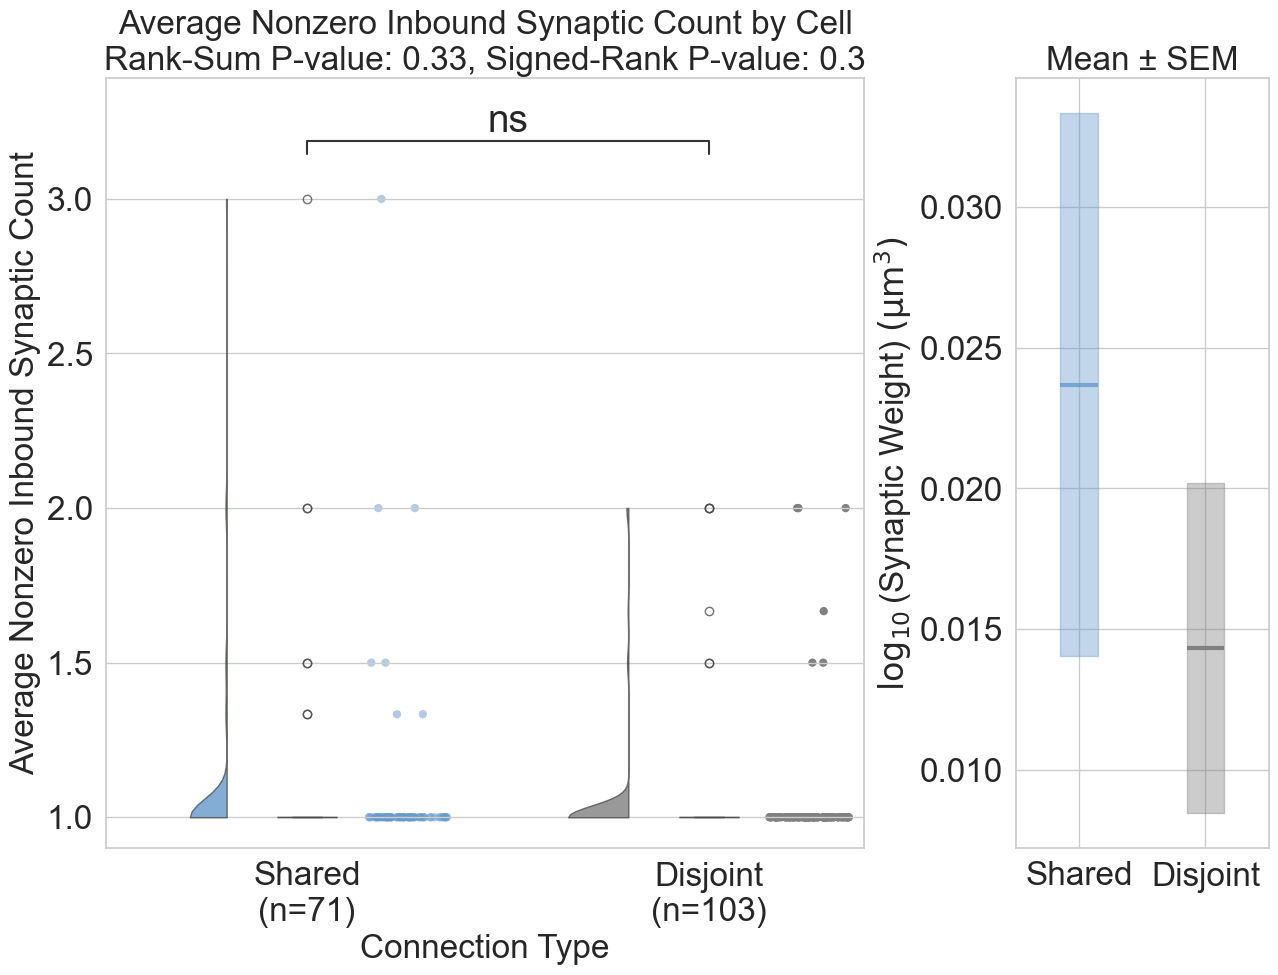

In [30]:
ranksum_signedrank_two_group_comparison(S_nonzero_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

## Higher-Order Connectivity Analysis: Centrality

In [31]:
def centrality_bootstrap_effects_and_p(
    comparison_dict: Dict[str, Dict[Any, float]],
    *,
    B: int = 1_000,
    seed: int = 747,
    alternative: str = "greater",
    non_zero: bool = False,
    alpha: float = 0.05,
    hl_max_pairs: int = 5_000_000,
    paired: bool = False,
    eps_tie: float = 0.0,
    mw_method: str = "asymptotic",
) -> Dict[str, Any]:

    rng = default_rng(seed)
    sign = _dir_from_alt(alternative)

    # ---------- build data ----------
    if paired:
        s, d, z = _paired_from_dict(comparison_dict)
        if non_zero:
            mask = (s != 0) & (d != 0)
            s, d, z = s[mask], d[mask], z[mask]
        if z.size == 0:
            raise ValueError("No common keys for paired analysis after filtering.")
    else:
        s = np.array(comparison_dict["All A"])
        d = np.array(comparison_dict["No A"])
        if non_zero:
            s = s[s != 0]
            d = d[d != 0]
        if s.size == 0 or d.size == 0:
            raise ValueError("Empty group(s) for unpaired analysis after filtering.")

    # ---------- point estimates ----------
    d_hat   = cohens_d(s, d, alternative=alternative, paired=paired)
    HL_hat  = hodges_lehmann(s, d, alternative=alternative, paired=paired,
                             max_pairs=hl_max_pairs, rng=rng)
    PS_hat, delta_hat = ps_and_delta(s, d, alternative=alternative, paired=paired,
                                     eps=eps_tie, method=mw_method)

    # test (Wilcoxon or Mann–Whitney)
    if paired:
        alt = "greater" if sign > 0 else "less"
        sr = stats.wilcoxon(s, d, alternative=alt)
        p_point = float(sr.pvalue)
        median_info = f"Median paired difference = {np.median(s - d):.6g}"
    else:
        alt = "greater" if sign > 0 else "less"
        mw = stats.mannwhitneyu(s, d, alternative=alt, method=mw_method)
        p_point = float(mw.pvalue)
        median_info = f"Shared median = {np.median(s):.6g}, Disjoint median = {np.median(d):.6g}"

    # ---------- bootstrap ----------
    if paired:
        n = s.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            sb, db = s[idx], d[idx]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=True)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=True)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=True, eps=eps_tie)
            ps_b[b], delta_b[b] = A_b, del_b
    else:
        n1, n2 = s.size, d.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            si = rng.integers(0, n1, size=n1)
            di = rng.integers(0, n2, size=n2)
            sb, db = s[si], d[di]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=False)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=False,
                                     max_pairs=hl_max_pairs, rng=rng)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=False, method=mw_method)
            ps_b[b], delta_b[b] = A_b, del_b

    # ---------- jackknife for BCa ----------
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        try:
            jack_d    = _jackknife_stat(cohens_d,        s, d, paired=paired, alternative=alternative)
            jack_hl   = _jackknife_stat(hodges_lehmann,  s, d, paired=paired, alternative=alternative)
            jack_ps   = _jackknife_stat(lambda a,b,**kw: ps_and_delta(a,b,**kw)[0],
                                        s, d, paired=paired, alternative=alternative)
            jack_del  = 2.0*jack_ps - 1.0
        except Exception:
            jack_d = jack_hl = jack_ps = jack_del = np.array([])

    # ---------- percentile CIs ----------
    d_CI_pct     = _ci_wrapper(d_hat,   d_b,    np.array([]), alpha, method="percentile")
    hl_CI_pct    = _ci_wrapper(HL_hat,  hl_b,   np.array([]), alpha, method="percentile")
    ps_CI_pct    = _ci_wrapper(PS_hat,  ps_b,   np.array([]), alpha, method="percentile")
    delta_CI_pct = _ci_wrapper(delta_hat, delta_b, np.array([]), alpha, method="percentile")

    # ---------- BCa CIs ----------
    d_CI_bca     = _ci_wrapper(d_hat,   d_b,    jack_d,   alpha, method="bca")
    hl_CI_bca    = _ci_wrapper(HL_hat,  hl_b,   jack_hl,  alpha, method="bca")
    ps_CI_bca    = _ci_wrapper(PS_hat,  ps_b,   jack_ps,  alpha, method="bca")
    delta_CI_bca = _ci_wrapper(delta_hat, delta_b, jack_del, alpha, method="bca")

    # ---------- console output ----------
    mode = "PAIRED" if paired else "UNPAIRED"
    n_info = f"n_pairs={len(s)}" if paired else f"n1={len(s)}, n2={len(d)}"

    print(f"\n[{mode}] Effect sizes (pos = '{alternative}')  {n_info}")
    print(f"  Test p-value: {p_point:.4g}")
    print(f"  {median_info}")

    print("\n  Effect sizes with bootstrapped 95% CI (percentile):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_pct[0]:.6g}, {hl_CI_pct[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_pct[0]:.3f}, {ps_CI_pct[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_pct[0]:.3f}, {delta_CI_pct[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_pct[0]:.3f}, {d_CI_pct[1]:.3f}]")

    print("\n  Effect sizes with bootstrapped 95% CI (BCa):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_bca[0]:.6g}, {hl_CI_bca[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_bca[0]:.3f}, {ps_CI_bca[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_bca[0]:.3f}, {delta_CI_bca[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_bca[0]:.3f}, {d_CI_bca[1]:.3f}]")

    # ---------- results dict ----------
    results = {
        "paired": paired,
        "alternative": alternative,
        "non_zero": non_zero,
        "B": B,
        "point": {"p_value": p_point, "d": float(d_hat), "HL": float(HL_hat),
                  "PS": float(PS_hat), "delta": float(delta_hat)},
        "CI95_percentile": {"d": d_CI_pct, "HL": hl_CI_pct, "PS": ps_CI_pct, "delta": delta_CI_pct},
        "CI95_bca": {"d": d_CI_bca, "HL": hl_CI_bca, "PS": ps_CI_bca, "delta": delta_CI_bca},
        "n": (len(s), len(d)) if not paired else (len(s),),
    }

    return results

def produce_centrality_plot(input_centrality_dict: dict,
                                     just_pyramidal=False,
                                     outdegree=False,
                                     indegree=False, 
                                     closeness=False, 
                                     betweenness=False,
                                     save=False,
                                     figure_name=None):
    """
    Produces a raincloud plot for centrality metrics.

    Parameters:
        input_centrality_dict (dict): Dictionary containing centrality values.
        just_pyramidal (bool): Whether to filter to pyramidal cells only.
        outdegree (bool): Whether to use outdegree centrality.
        indegree (bool): Whether to use indegree centrality.
        closeness (bool): Whether to use closeness centrality.
        betweenness (bool): Whether to use betweenness centrality.

    Returns:
        None
    """
    if outdegree and indegree:
        raise ValueError("Must either be working with outdegree or indegree.")
    if closeness and betweenness:
        raise ValueError("Must either be working with closeness or betweenness.")
    if (outdegree or indegree) and (closeness or betweenness):
        raise ValueError("Must either be working with directionality (indegree/outdegree) or higher-order (betweenness/closeness).")

    suffix = "of Co-Registered Cells"

    # Based on the connectome flags, set the correct y_label and plot title
    if outdegree:
        centrality_desc = "Outdegree_Centrality"
        suffix = "Outdegree Centrality " + suffix
        y_lab = "Outdegree Centrality"
    elif indegree:
        centrality_desc = "Indegree_Centrality"
        suffix = "Indegree Centrality " + suffix
        y_lab = "Indegree Centrality"
    elif closeness: 
        centrality_desc = "Closeness_Centrality"
        suffix = "Closeness Centrality " + suffix
        y_lab = "Closeness Centrality"
    elif betweenness:
        centrality_desc = "Betweenness_Centrality"
        suffix = "Betweenness Centrality " + suffix
        y_lab = "Betweenness Centrality"
    else:
        raise ValueError("Must Specify Degree")

    centrality_dict = {}
    for key in input_centrality_dict.keys():
        centrality_dict[key] = np.array(input_centrality_dict[key])

    all_arr = [centrality_dict['All A'], centrality_dict['No A']]
    result = stats.ranksums(centrality_dict['All A'], centrality_dict['No A'], 'greater')
    print(f"Rank-Sum Test (unpaired, All A > No A):\nStatistic: {result.statistic:.4g}, P-value: {result.pvalue:.4g}")
    centrality_bootstrap_effects_and_p(input_centrality_dict, alternative='greater')

    # Calculate sample sizes
    n_all_a = len(centrality_dict['All A'])
    n_no_a = len(centrality_dict['No A'])

    # Create a figure
    plt.figure(figsize=(12,10))
    sns.set_theme(style="whitegrid")

    # Prepare data for raincloud plot
    data = pd.DataFrame({
        "Values": np.concatenate(all_arr),
        "Group": [f"Assembly\n(n={n_all_a})"] * len(centrality_dict['All A']) + \
                 [f"Non-Assembly\n(n={n_no_a})"] * len(centrality_dict['No A'])
    })

    # Create the raincloud plot
    ax = pt.RainCloud(
        y="Values",
        x="Group",
        data=data,
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,  # Adjust violin width
        alpha=0.8,  # Transparency of the cloud
        move=0.25,  # Adjust position of violins
        point_size = 6,
        orient="v"  # Horizontal orientation
    )

    # Set markings for significance
    y_labels = [f"Assembly\n(n={n_all_a})", f"Non-Assembly\n(n={n_no_a})"]
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax, 
                    pairs,
                    data=data,
                    x="Group",
                    y="Values",
                    order=y_labels # Force the order
                    )
    annot.set_pvalues([result.pvalue])
    annot.configure(text_format="star", loc="inside", fontsize=32)
    annot.annotate()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.get_offset_text().set_fontsize(32)

    # Add a multiline title to include the p-value, add y_label
    title = f'{suffix}\nRank-Sum P-value: {result.pvalue:.2g}'
    plt.title(title, size=32)
    plt.ylabel(y_lab, size=32)
    plt.xticks(fontsize=32)  # Adjust size of xticks
    plt.yticks(fontsize=32)  # Adjust size of yticks
    plt.xlabel("Assigned Assembly Status", size=32)

    if save == True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()

### All Cells Proofread Connectome

In [32]:
# Pull Data from LSMM Data
with open('all_cells_proofread_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Generating Connectome...


100%|██████████| 137706/137706 [01:39<00:00, 1382.83it/s]


Generating Connectome...


100%|██████████| 137706/137706 [01:40<00:00, 1372.79it/s]


In [33]:
# Calculate Centrality Measurements
binary_connectome = data_a['structural']['binary_connectome']
all_to_all_graph = nx.from_numpy_array(binary_connectome, create_using=nx.DiGraph)

indegree_centrality = nx.in_degree_centrality(all_to_all_graph)
outdegree_centrality = nx.out_degree_centrality(all_to_all_graph)
closeness_centrality = nx.closeness_centrality(all_to_all_graph, wf_improved = True)
betweenness_centrality = nx.betweenness_centrality(all_to_all_graph, normalized= True)

In [34]:
connectome_index_by_assemblies = mappings_a['connectome_indexes_by_assembly']
assembly_connectome_indexes = np.unique(np.concatenate([val for key, val in connectome_index_by_assemblies.items() if key != 'No A']))
no_assembly_connectome_indexes = np.array(list(connectome_index_by_assemblies['No A']))

# Produce Grouped Counts for Inbound and Outbound Connections
indegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
outdegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
closeness_centrality_by_grouped_membership = {'No A': [], 'All A': []}
betweenness_centrality_by_grouped_membership = {'No A': [], 'All A': []}

# Add to dictionaries to plot
for assembly_cell_idx in assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['All A'].append(indegree_centrality[assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['All A'].append(outdegree_centrality[assembly_cell_idx])
    closeness_centrality_by_grouped_membership['All A'].append(closeness_centrality[assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['All A'].append(betweenness_centrality[assembly_cell_idx])
for no_assembly_cell_idx in no_assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['No A'].append(indegree_centrality[no_assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['No A'].append(outdegree_centrality[no_assembly_cell_idx])
    closeness_centrality_by_grouped_membership['No A'].append(closeness_centrality[no_assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['No A'].append(betweenness_centrality[no_assembly_cell_idx])

In [35]:
# Save all produced sets
save_folder = 'master_freeze_produced_sets/centrality/scan_13/all_cell_connectome_'
with open(f"{save_folder}indegree_centrality.pkl", "wb") as f:
    pickle.dump(indegree_centrality_by_grouped_membership, f)
with open(f"{save_folder}outdegree_centrality.pkl", "wb") as f:
    pickle.dump(outdegree_centrality_by_grouped_membership, f)
with open(f"{save_folder}closeness_centrality.pkl", "wb") as f:
    pickle.dump(closeness_centrality_by_grouped_membership, f)
with open(f"{save_folder}betweenness_centrality.pkl", "wb") as f:
    pickle.dump(betweenness_centrality_by_grouped_membership, f)

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.86, P-value: 0.03146

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.03181
  Shared median = 0.0481786, Disjoint median = 0.0434783

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.00822562 : CI [0, 0.0176263]
    PS:       0.642 : CI [0.497, 0.771]   (δ=0.284 : CI [-0.006, 0.542])
    Cohen's d: 0.544 : CI [0.118, 0.986]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.00822562 : CI [-0.00117509, 0.0152761]
    PS:       0.642 : CI [0.494, 0.768]   (δ=0.284 : CI [-0.013, 0.536])
    Cohen's d: 0.544 : CI [0.110, 0.972]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:3.146e-02


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


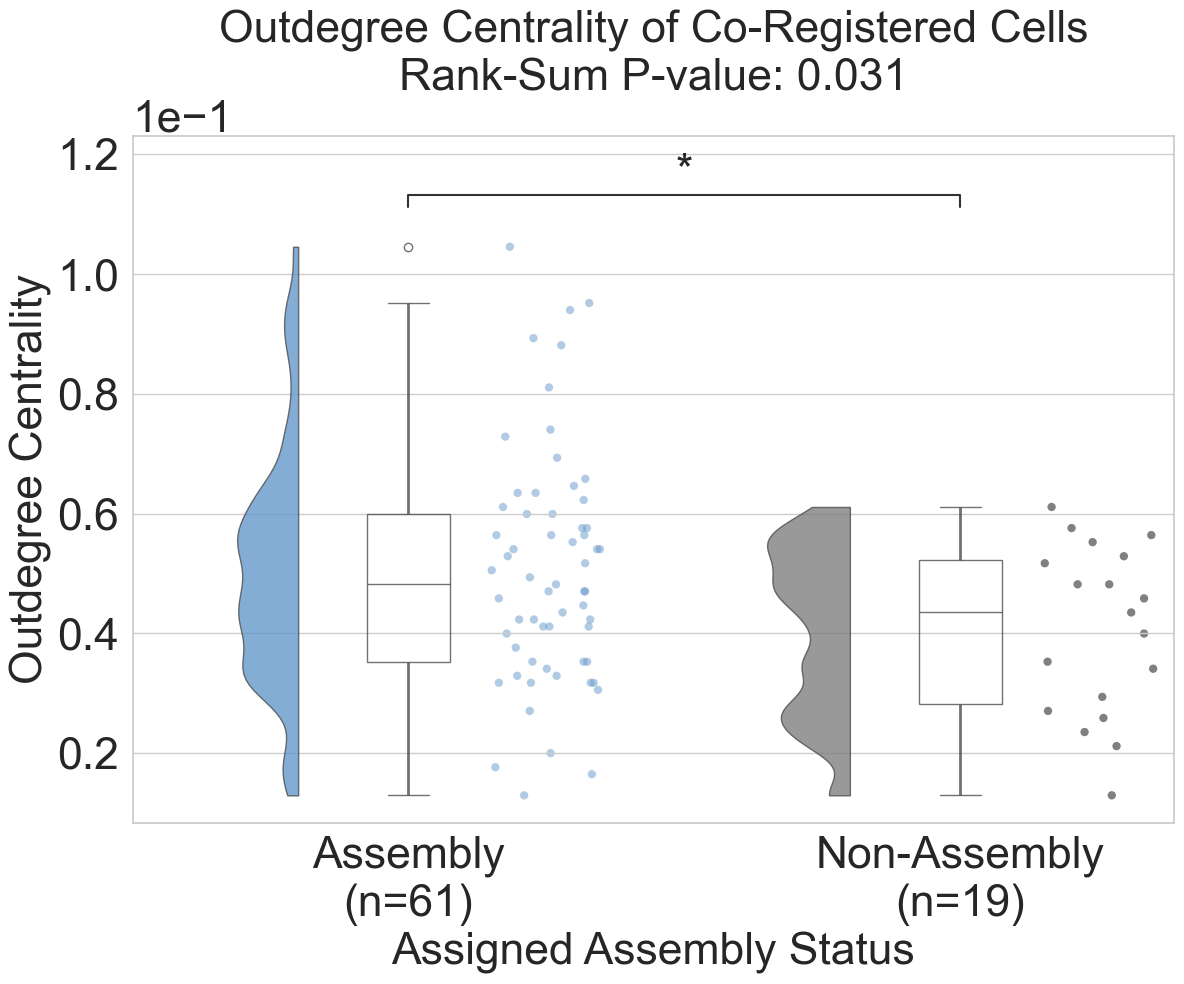

In [36]:
produce_centrality_plot(outdegree_centrality_by_grouped_membership,
                        outdegree = True, save=True, figure_name='Outdegree_Centrality_All')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.747, P-value: 0.04034

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.04078
  Shared median = 0.0857814, Disjoint median = 0.0740306

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.0141011 : CI [-0.00117509, 0.0282021]
    PS:       0.633 : CI [0.488, 0.769]   (δ=0.267 : CI [-0.024, 0.538])
    Cohen's d: 0.491 : CI [-0.010, 1.040]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.0141011 : CI [-0.00352526, 0.027027]
    PS:       0.633 : CI [0.459, 0.753]   (δ=0.267 : CI [-0.082, 0.506])
    Cohen's d: 0.491 : CI [-0.088, 0.963]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:4.034e-02


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


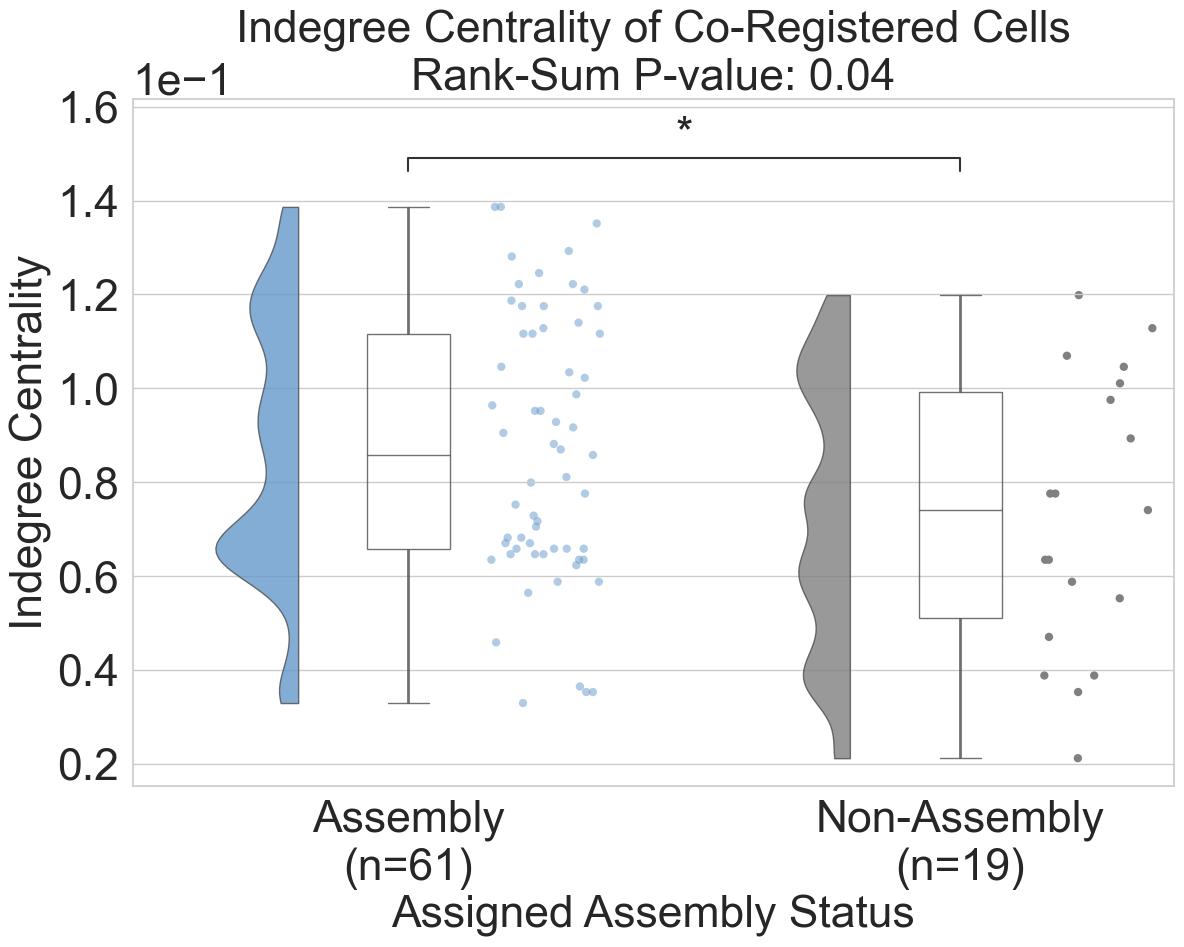

In [37]:
produce_centrality_plot(indegree_centrality_by_grouped_membership,
                        indegree = True, save=True, figure_name='Indegree_Centrality_All')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 2.719, P-value: 0.003273

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.00333
  Shared median = 0.000274487, Disjoint median = 0.000159944

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.000106312 : CI [3.11444e-05, 0.000168546]
    PS:       0.708 : CI [0.563, 0.838]   (δ=0.415 : CI [0.125, 0.676])
    Cohen's d: 0.635 : CI [0.221, 1.023]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.000106312 : CI [3.11444e-05, 0.000168535]
    PS:       0.708 : CI [0.544, 0.821]   (δ=0.415 : CI [0.087, 0.641])
    Cohen's d: 0.635 : CI [0.087, 0.955]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:3.273e-03


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


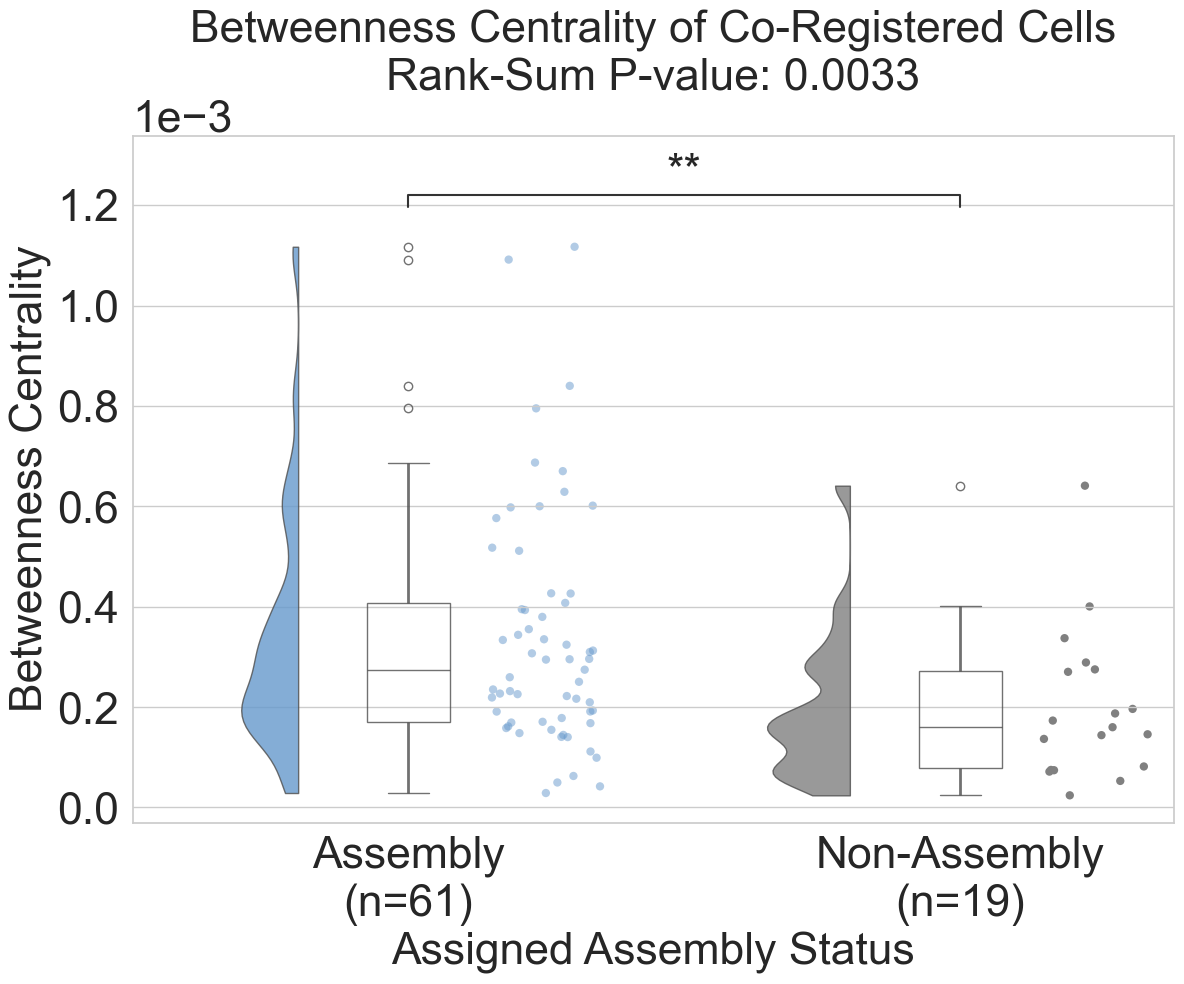

In [38]:
produce_centrality_plot(betweenness_centrality_by_grouped_membership,
                        betweenness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Betweenness_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.413, P-value: 0.07879

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.07961
  Shared median = 0.491889, Disjoint median = 0.48459

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.00577382 : CI [-0.00209518, 0.0154273]
    PS:       0.608 : CI [0.462, 0.745]   (δ=0.216 : CI [-0.075, 0.490])
    Cohen's d: 0.391 : CI [-0.119, 0.945]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.00577382 : CI [-0.00233917, 0.0142508]
    PS:       0.608 : CI [0.459, 0.738]   (δ=0.216 : CI [-0.083, 0.475])
    Cohen's d: 0.391 : CI [-0.119, 0.945]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:7.879e-02


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


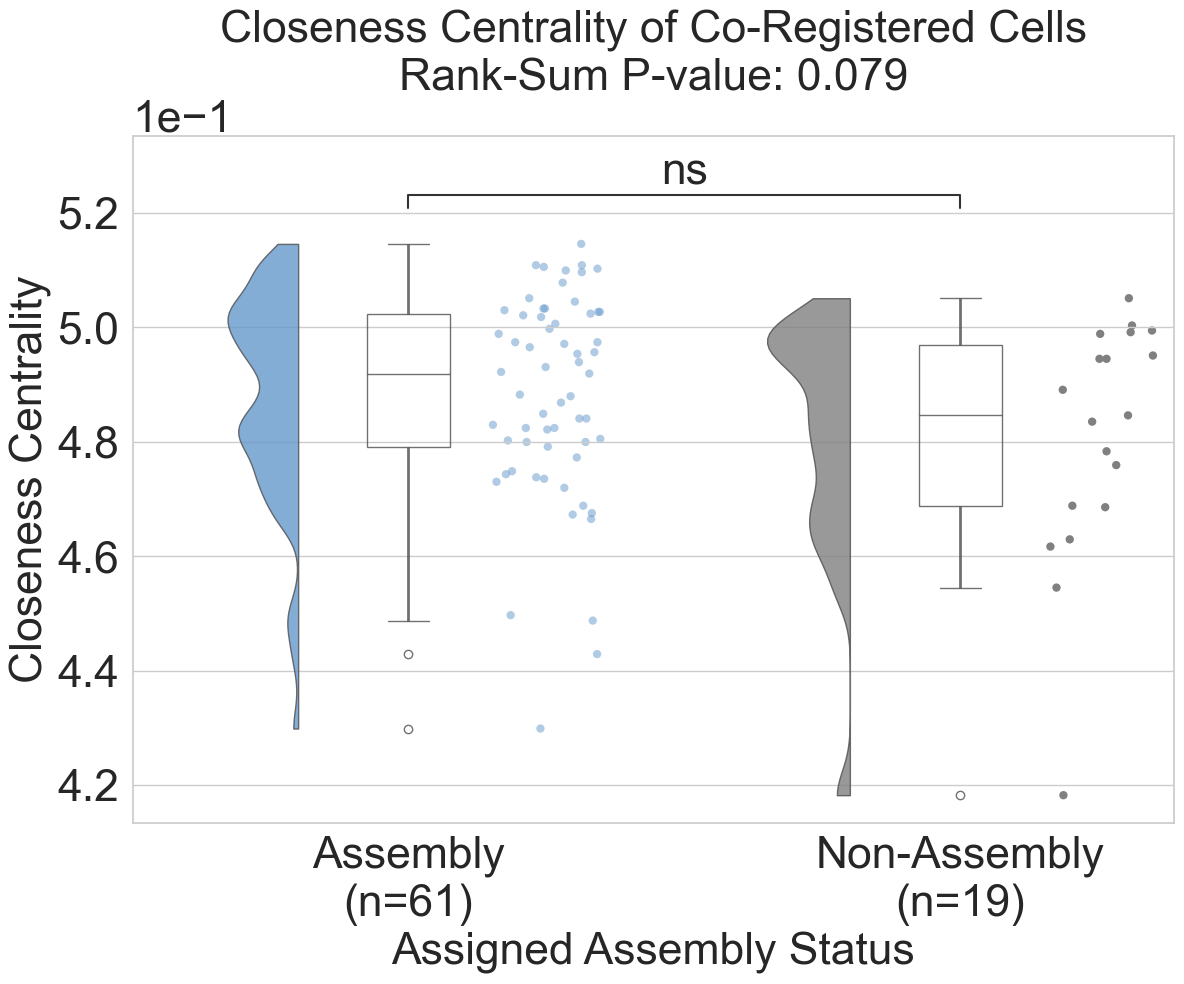

In [39]:
produce_centrality_plot(closeness_centrality_by_grouped_membership,
                        closeness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Closeness_Centrality_Pyr')

### Pyramidal Cells Proofread Connectome

In [40]:
# Pull Data from LSMM Data
with open('pyr_cells_proofread_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Filtering to pyramidal cells only
459
Generating Connectome...


100%|██████████| 4565/4565 [00:01<00:00, 2795.88it/s]


Generating Connectome...


100%|██████████| 4565/4565 [00:01<00:00, 2784.57it/s]


In [41]:
# Calculate Centrality Measurements
binary_connectome = data_a['structural']['binary_connectome']
all_to_all_graph = nx.from_numpy_array(binary_connectome, create_using=nx.DiGraph)

indegree_centrality = nx.in_degree_centrality(all_to_all_graph)
outdegree_centrality = nx.out_degree_centrality(all_to_all_graph)
closeness_centrality = nx.closeness_centrality(all_to_all_graph, wf_improved = True)
betweenness_centrality = nx.betweenness_centrality(all_to_all_graph, normalized= True)

In [42]:
connectome_index_by_assemblies = mappings_a['connectome_indexes_by_assembly']
assembly_connectome_indexes = np.unique(np.concatenate([val for key, val in connectome_index_by_assemblies.items() if key != 'No A']))
no_assembly_connectome_indexes = np.array(list(connectome_index_by_assemblies['No A']))

# Produce Grouped Counts for Inbound and Outbound Connections
indegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
outdegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
closeness_centrality_by_grouped_membership = {'No A': [], 'All A': []}
betweenness_centrality_by_grouped_membership = {'No A': [], 'All A': []}

# Add to dictionaries to plot
for assembly_cell_idx in assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['All A'].append(indegree_centrality[assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['All A'].append(outdegree_centrality[assembly_cell_idx])
    closeness_centrality_by_grouped_membership['All A'].append(closeness_centrality[assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['All A'].append(betweenness_centrality[assembly_cell_idx])
for no_assembly_cell_idx in no_assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['No A'].append(indegree_centrality[no_assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['No A'].append(outdegree_centrality[no_assembly_cell_idx])
    closeness_centrality_by_grouped_membership['No A'].append(closeness_centrality[no_assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['No A'].append(betweenness_centrality[no_assembly_cell_idx])

In [43]:
# Save all produced sets
save_folder = 'master_freeze_produced_sets/centrality/scan_13/pyr_only_connectome_'
with open(f"{save_folder}indegree_centrality.pkl", "wb") as f:
    pickle.dump(indegree_centrality_by_grouped_membership, f)
with open(f"{save_folder}outdegree_centrality.pkl", "wb") as f:
    pickle.dump(outdegree_centrality_by_grouped_membership, f)
with open(f"{save_folder}closeness_centrality.pkl", "wb") as f:
    pickle.dump(closeness_centrality_by_grouped_membership, f)
with open(f"{save_folder}betweenness_centrality.pkl", "wb") as f:
    pickle.dump(betweenness_centrality_by_grouped_membership, f)

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.899, P-value: 0.02876

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.02868
  Shared median = 0.0174672, Disjoint median = 0.0152838

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.00436681 : CI [0, 0.00873362]
    PS:       0.645 : CI [0.515, 0.760]   (δ=0.290 : CI [0.030, 0.520])
    Cohen's d: 0.571 : CI [0.277, 0.851]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.00436681 : CI [0, 0.00655022]
    PS:       0.645 : CI [0.516, 0.761]   (δ=0.290 : CI [0.032, 0.523])
    Cohen's d: 0.571 : CI [0.277, 0.851]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:2.876e-02


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


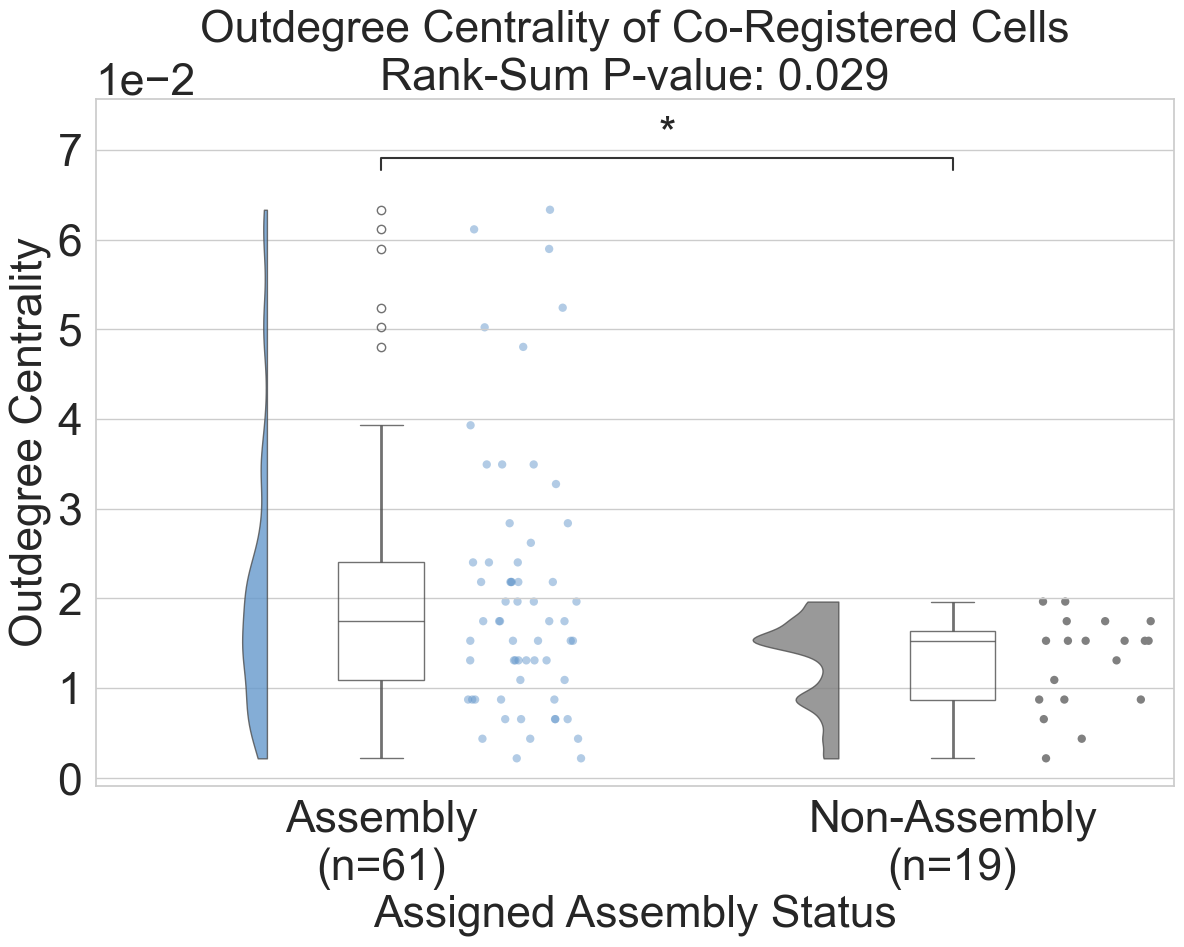

In [44]:
produce_centrality_plot(outdegree_centrality_by_grouped_membership,
                        outdegree = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Outdegree_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.538, P-value: 0.06207

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.062
  Shared median = 0.0131004, Disjoint median = 0.010917

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.00218341 : CI [0, 0.00873362]
    PS:       0.617 : CI [0.466, 0.749]   (δ=0.235 : CI [-0.067, 0.498])
    Cohen's d: 0.393 : CI [-0.086, 0.888]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.00218341 : CI [-0.00218341, 0.00655022]
    PS:       0.617 : CI [0.462, 0.742]   (δ=0.235 : CI [-0.075, 0.484])
    Cohen's d: 0.393 : CI [-0.261, 0.795]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:6.207e-02


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


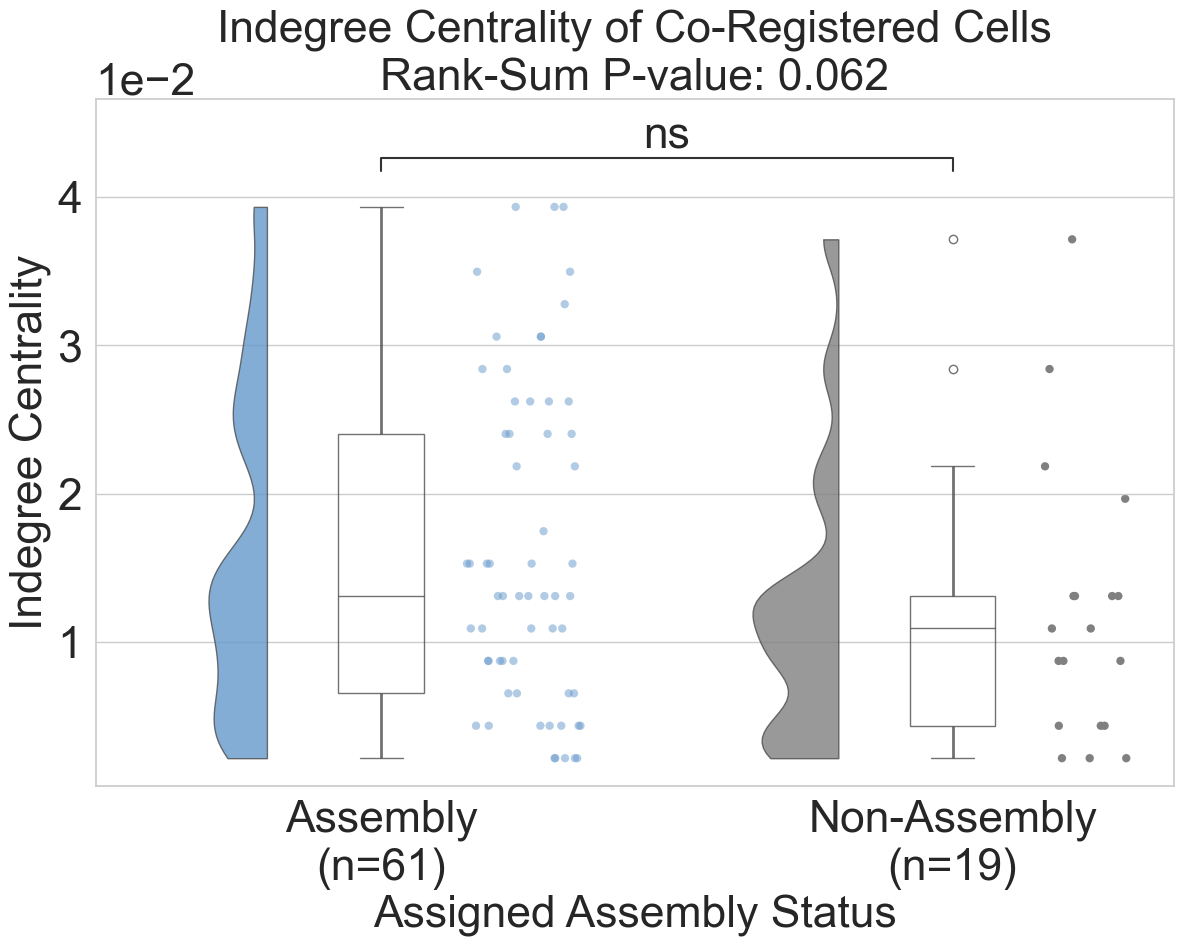

In [45]:
produce_centrality_plot(indegree_centrality_by_grouped_membership,
                        indegree = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Indegree_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.894, P-value: 0.02913

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.02951
  Shared median = 0.00324451, Disjoint median = 0.00199345

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.00106893 : CI [1.28675e-05, 0.00215889]
    PS:       0.645 : CI [0.500, 0.779]   (δ=0.289 : CI [0.001, 0.558])
    Cohen's d: 0.477 : CI [0.143, 0.765]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.00106893 : CI [-6.21082e-05, 0.00208542]
    PS:       0.645 : CI [0.494, 0.771]   (δ=0.289 : CI [-0.011, 0.543])
    Cohen's d: 0.477 : CI [0.064, 0.720]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:2.913e-02


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


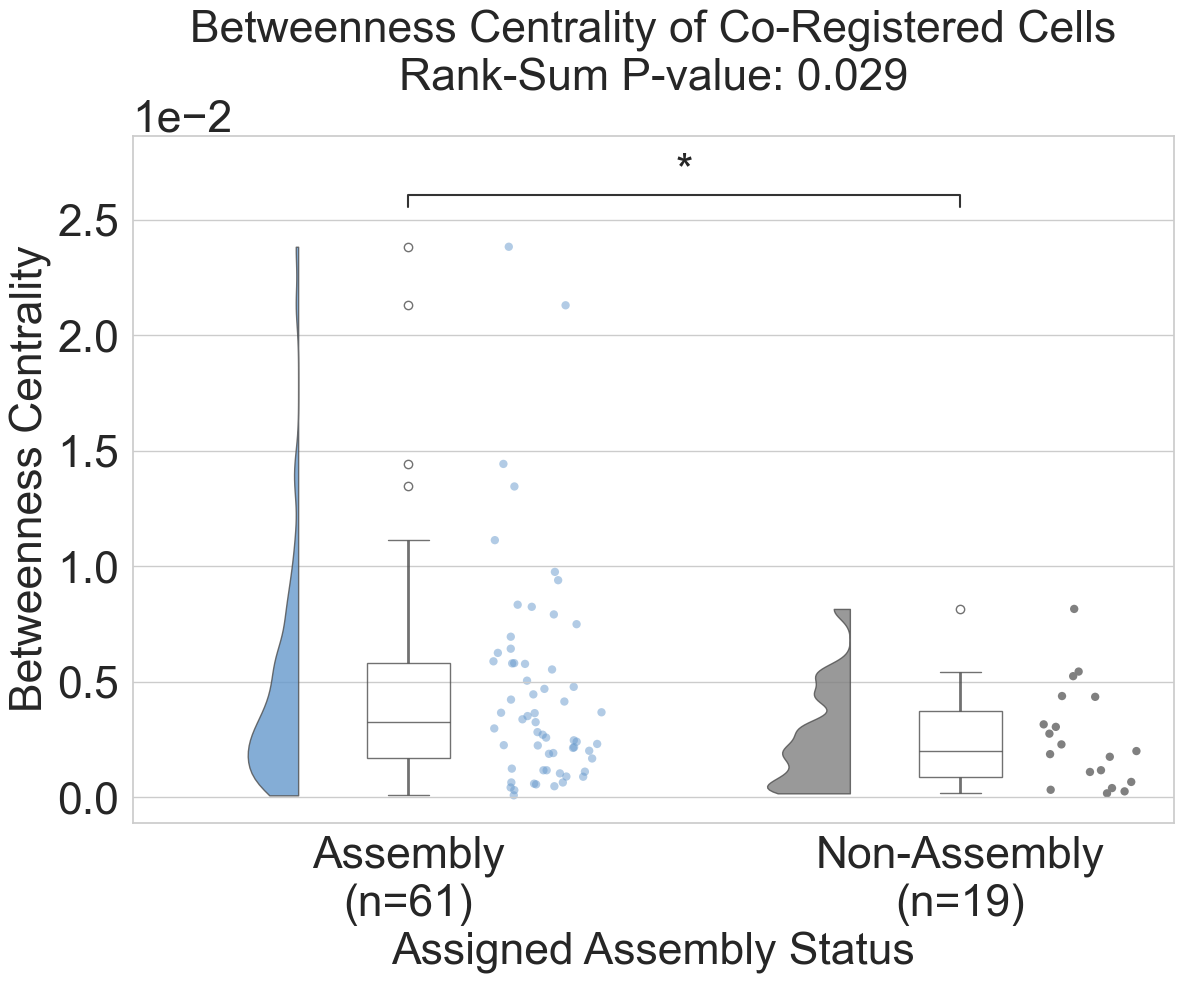

In [46]:
produce_centrality_plot(betweenness_centrality_by_grouped_membership,
                        betweenness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Betweenness_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 0.8423, P-value: 0.1998

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.2014
  Shared median = 0.276667, Disjoint median = 0.270241

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.00773406 : CI [-0.00986201, 0.0285218]
    PS:       0.564 : CI [0.417, 0.705]   (δ=0.129 : CI [-0.167, 0.411])
    Cohen's d: 0.132 : CI [-0.275, 0.705]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.00773406 : CI [-0.01013, 0.0283854]
    PS:       0.564 : CI [0.408, 0.698]   (δ=0.129 : CI [-0.184, 0.395])
    Cohen's d: 0.132 : CI [-0.336, 0.641]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:1.998e-01


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


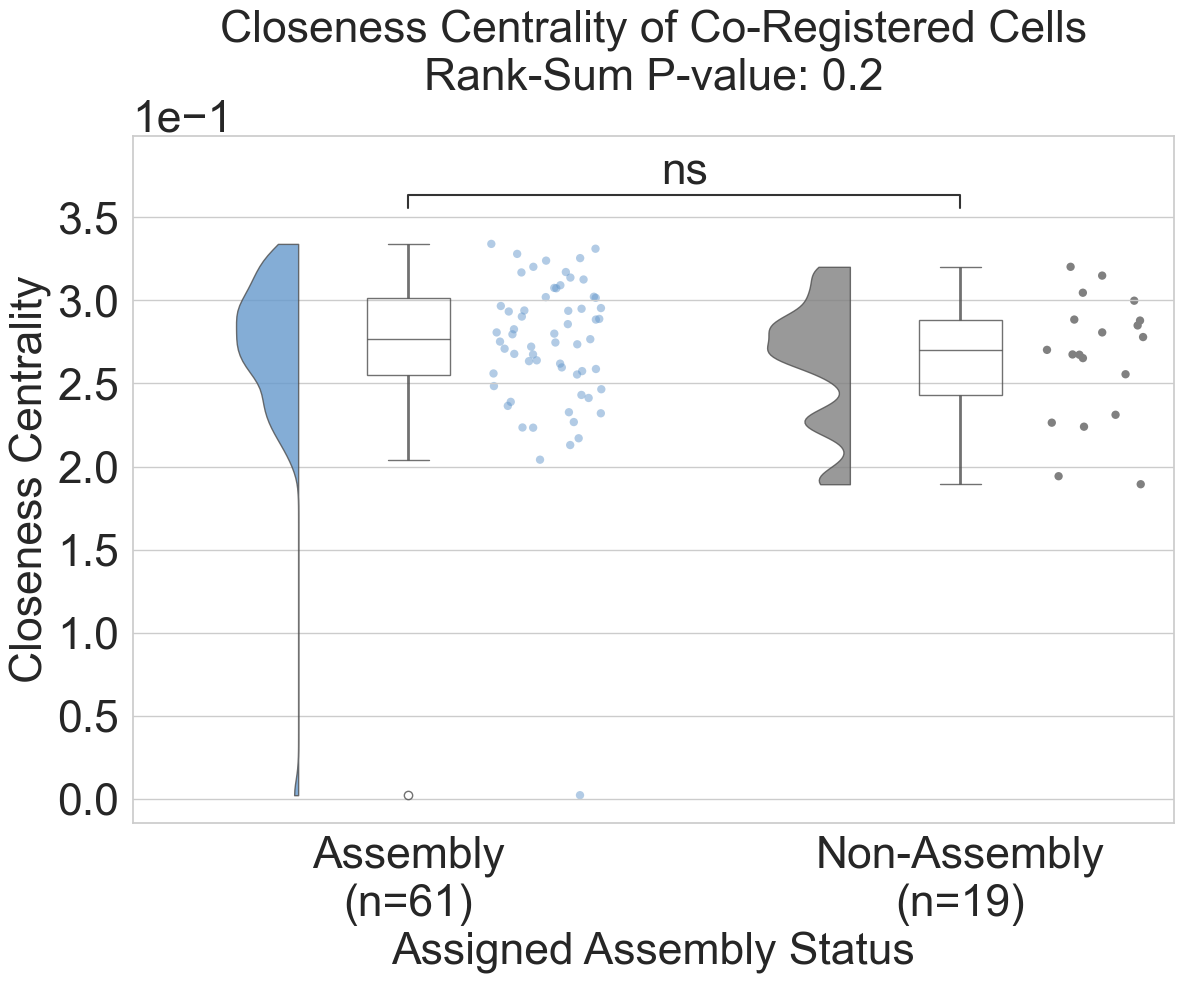

In [47]:
produce_centrality_plot(closeness_centrality_by_grouped_membership,
                        closeness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Closeness_Centrality_Pyr')

# Chains: Standard

In [48]:
with open('all_cells_rectangular_connectome.json') as f:
    loaded_json = json.load(f)
my_data = LSMMData.LSMMData(loaded_json)
# with open('pyr_rect.data', 'wb') as f:
#     pickle.dump(my_data, f)

data_a = my_data.data
params_a = my_data.params
dirs_a = my_data.dirs
mappings_a = my_data.mappings

Generating Connectome...


100%|██████████| 813407/813407 [39:50<00:00, 340.25it/s]  


Generating Connectome...


100%|██████████| 813407/813407 [1:52:18<00:00, 120.71it/s]    


In [49]:
# Make a graph
pre_cell_table = data_a['structural']['pre_cell'].copy()
post_cell_table = data_a['structural']['post_cell'].copy() 
pre_cell_table['connectome_index'] = pre_cell_table.index
post_cell_table['connectome_index'] = post_cell_table.index
synapse_table = data_a['structural']['synapse']
adjacency_matrix = data_a['structural']['binary_connectome']
cell_graph = nx.DiGraph()

# Add edges to the graph
rows, cols = data_a['structural']['binary_connectome'].shape
for i in range(rows):
    for j in range(cols):
        if data_a['structural']['binary_connectome'][i, j] != 0:  # 0 means no edge
            cell_graph.add_edge(pre_cell_table.iloc[i]['pt_root_id'], post_cell_table.iloc[j]['pt_root_id'], weight=data_a['structural']['summed_size_connectome'][i, j])

synapse_table = data_a['structural']['synapse']
# adjacency_matrix = data_a['structural']['binary_connectome']
binary_connectome = data_a['structural']['binary_connectome']

index_to_pre_root_id = [mappings_a['connectome_index_to_root_id'][i] for i in range(binary_connectome.shape[0])]
index_to_post_root_id = [mappings_a['post_connectome_index_to_root_id'][i] for i in range(binary_connectome.shape[1])]

summed_size_connectome = data_a['structural']['summed_size_connectome']
summed_size_connectome_df = pd.DataFrame(
    summed_size_connectome,
    index=index_to_pre_root_id,
    columns=index_to_post_root_id
)

synapse_count_connectome = data_a['structural']['synapse_count_connectome']
synapse_count_connectome_df = pd.DataFrame(
    synapse_count_connectome,
    index=index_to_pre_root_id,
    columns=index_to_post_root_id
)

# Or uncomment below to generate new motif analysis results (Can take quite a while on larger graphs)
# Motif Analysis with DotMotif: 2 Chain, All Pyr
executor = GrandIsoExecutor(graph= cell_graph)
chain_defs = Motif("""
                A -> B
                B -> C
              """)

chain_results = executor.find(chain_defs)

two_chain_results_array = np.array([list(c.values()) for c in tqdm(chain_results)])

100%|██████████| 36431187/36431187 [00:36<00:00, 1001466.94it/s]


In [50]:
# get the pre pt root id for connectome indexes by assembly
pre_pt_root_id_by_assembly = {}
for a,idx in mappings_a['connectome_indexes_by_assembly'].items():
    pre_pt_root_id_by_assembly[a] = []
    for i in idx:
       pre_pt_root_id_by_assembly[a].append(mappings_a['connectome_index_to_root_id'][i])  

# get the post pt root id for connectome indexes by assembly
post_pt_root_id_by_assembly = {}
for a,idx in mappings_a['post_connectome_indexes_by_assembly'].items():
    post_pt_root_id_by_assembly[a] = []
    for i in idx:
       post_pt_root_id_by_assembly[a].append(mappings_a['post_connectome_index_to_root_id'][i]) 

### Pool necessary Data
chain_count_string_array = ['pyr_cell_2chain']
individual_pre_assembly_root_ids = [pre_pt_root_id_by_assembly[f'A {i}'] for i in range(1,16)]
individual_post_assembly_root_ids = [post_pt_root_id_by_assembly[f'A {i}'] for i in range(1,16)]


individual_assembly_indexes = [mappings_a['connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]
individual_post_assembly_indexes = [mappings_a['post_connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]

coregistered_post_cell_root_ids = my_data._invert_dict(post_pt_root_id_by_assembly).keys()  #gives assemblies by post_pt_root_id
coregistered_pre_cell_root_ids =  my_data._invert_dict(pre_pt_root_id_by_assembly).keys() # gives assemblies by pre_pt_root_id

no_a_pre_cell_root_ids = pre_pt_root_id_by_assembly['No A']  # HAVE THIS
no_a_post_cell_root_ids = post_pt_root_id_by_assembly['No A'] # HAVE THIS
pooled_assembly_root_ids = list(set(coregistered_pre_cell_root_ids) - set(no_a_pre_cell_root_ids))
pooled_assembly_post_root_ids = list(set(coregistered_post_cell_root_ids) - set(no_a_post_cell_root_ids))

assembly_to_root_ids = mappings_a['pt_root_ids_by_assembly']
assembly_root_ids_set = set(mappings_a['assemblies_by_pt_root_id'].keys())

# Filter synapses_table to only synapses between two assembly cells (including No A)
synapses_df = synapse_table[synapse_table['pre_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df = synapses_df[synapses_df['post_pt_root_id'].isin(assembly_root_ids_set)]

# Filter cell tables to only assembly cells (including 'No A')
assembly_pre_cell_table = pre_cell_table[pre_cell_table['pt_root_id'].isin(assembly_root_ids_set)]
assembly_post_cell_table = post_cell_table[post_cell_table['pt_root_id'].isin(assembly_root_ids_set)]

assembly_pre_root_ids = set(assembly_pre_cell_table['pt_root_id'].values)
assembly_post_root_ids = set(assembly_post_cell_table['pt_root_id'].values)
all_root_ids = assembly_pre_root_ids | assembly_post_root_ids

In [51]:
# Split out assemblies and no_a
assembly_names = set(assembly_to_root_ids.keys()) - set(['No A'])
A_invert = {assembly: set(assembly_to_root_ids[assembly]) for assembly in assembly_names}
no_A = set(assembly_to_root_ids['No A'])
all_coregistered_root_ids = mappings_a['assemblies_by_pt_root_id'].keys()
assembly_root_ids_excluding_no_A = set(all_coregistered_root_ids) - no_A
A = {pt_root_id: set(mappings_a['assemblies_by_pt_root_id'][pt_root_id]) for pt_root_id in all_root_ids if 'No A' not in mappings_a['assemblies_by_pt_root_id'][pt_root_id]}

In [52]:
## Define intermediary cell typing in dictionary
from collections import defaultdict

pt_root_id_to_cell_type = pre_cell_table.set_index('pt_root_id')['cell_type'].to_dict()
pt_root_id_to_cell_class = pre_cell_table.set_index('pt_root_id')['classification_system'].to_dict()

middle_cell_groups = defaultdict(set)

# Add class-level groups
for root_id, cls in pt_root_id_to_cell_class.items():
    middle_cell_groups[cls].add(root_id)

# Add type-level groups
for root_id, ctype in pt_root_id_to_cell_type.items():
    middle_cell_groups[ctype].add(root_id)

# Optional: freeze
middle_cell_groups = dict(middle_cell_groups)

In [53]:
from collections import defaultdict

realized_chains = {}  # group -> metrics

for group in middle_cell_groups:
    realized_chains[group] = {
        "W": defaultdict(float),
        "S": defaultdict(float),
        "B": defaultdict(int),
        # num chains under intermediary cell type for pre, post combo (for averaging later)
        "R": defaultdict(int),
    }

voxel_to_um3 = (9 * 9 * 45) / 1e9

for j, k, i in two_chain_results_array:
    if j == i:
        continue
    if j not in all_root_ids or i not in all_root_ids:
        continue

    w_jk = summed_size_connectome_df.loc[j, k] * voxel_to_um3
    w_ki = summed_size_connectome_df.loc[k, i] * voxel_to_um3
    s_jk = synapse_count_connectome_df.loc[j, k]
    s_ki = synapse_count_connectome_df.loc[k, i]

    chain_w = w_jk * w_ki
    chain_s = s_jk + s_ki

    for group, mids in middle_cell_groups.items():
        if k in mids:
            acc = realized_chains[group]
            acc["W"][(j, i)] += chain_w
            acc["S"][(j, i)] += chain_s
            acc["B"][(j, i)] = 1
            acc["R"][(j, i)] += 1

In [54]:
# pairwise sets by intermediary cell group and connection type
W_pairwise = {}
S_pairwise = {}
B_pairwise = {}

for group in realized_chains:
    W_pairwise[group] = {}
    S_pairwise[group] = {}
    B_pairwise[group] = {}

    for cond_fn in comparison_functions:
        cname = cond_fn.__name__

        W_pairwise[group][cname] = {}
        S_pairwise[group][cname] = {}
        B_pairwise[group][cname] = {}

        for (j, i), w in realized_chains[group]["W"].items():
            if cond_fn(j, i, A):
                W_pairwise[group][cname][(j, i)] = w
                S_pairwise[group][cname][(j, i)] = realized_chains[group]["S"][(j, i)]
                B_pairwise[group][cname][(j, i)] = 1

In [66]:
# 'By cell' outbound metrics normalization
W_out = {}
S_out = {}
B_out = {}

for group, K_T in middle_cell_groups.items():
    W_out[group] = {}
    S_out[group] = {}
    B_out[group] = {}

    for cond_fn in comparison_functions:
        cname = cond_fn.__name__

        W_out[group][cname] = {}
        S_out[group][cname] = {}
        B_out[group][cname] = {}

        for j in assembly_pre_root_ids:

            # ---------- Realized chains (numerator) ----------
            realized_pairs = [
                (pre, post)
                for (pre,post) in realized_chains[group]["R"].keys()
                if pre == j and cond_fn(pre, post, A)
            ]

            total_R = sum(
                realized_chains[group]["R"][(j, i)]
                for (j, i) in realized_pairs
            )

            if total_R > 0:
                total_W = sum(
                    realized_chains[group]["W"][(j, i)]
                    for (j, i) in realized_pairs
                )
                total_S = sum(
                    realized_chains[group]["S"][(j, i)]
                    for (j, i) in realized_pairs
                )

                W_out[group][cname][j] = total_W / total_R
                S_out[group][cname][j] = total_S / total_R

            # ---------- Potential chains (denominator) ----------
            K_Tj = set(K_T) - {j}

            I_Cj = {
                i for i in all_root_ids
                if i != j and cond_fn(j, i, A)
            }

            invalid = K_Tj & I_Cj
            potential_chains = len(K_Tj) * len(I_Cj) - len(invalid)

            if potential_chains > 0:
                B_out[group][cname][j] = total_R / potential_chains

In [67]:
# 'By cell' inbound metrics normalization
W_in = {}
S_in = {}
B_in = {}

for group, K_T in middle_cell_groups.items():
    W_in[group] = {}
    S_in[group] = {}
    B_in[group] = {}

    for cond_fn in comparison_functions:
        cname = cond_fn.__name__

        W_in[group][cname] = {}
        S_in[group][cname] = {}
        B_in[group][cname] = {}

        for i in all_root_ids:

            # ---------- Realized chains (numerator) ----------
            realized_pairs = [
                (pre, post)
                for (pre, post) in realized_chains[group]["R"].keys()
                if post == i and cond_fn(pre, post, A)
            ]

            total_R = sum(
                realized_chains[group]["R"][(j, i)]
                for (j, i) in realized_pairs
            )

            if total_R > 0:
                total_W = sum(
                    realized_chains[group]["W"][(j, i)]
                    for (j, i) in realized_pairs
                )
                total_S = sum(
                    realized_chains[group]["S"][(j, i)]
                    for (j, i) in realized_pairs
                )

                W_in[group][cname][i] = total_W / total_R
                S_in[group][cname][i] = total_S / total_R

            # ---------- Potential chains (denominator) ----------
            K_Ti = set(K_T) - {i}

            J_Ci = {
                j for j in assembly_pre_root_ids
                if j != i and cond_fn(j, i, A)
            }

            invalid = K_Ti & J_Ci
            potential_chains = len(K_Ti) * len(J_Ci) - len(invalid)

            if potential_chains > 0:
                B_in[group][cname][i] = total_R / potential_chains


In [57]:
# # Save all produced sets
# save_folder = 'master_freeze_produced_sets/chain_connections/scan_13/'
# with open(f"{save_folder}W_chain_nonzero_pairwise_excitatory.pkl", "wb") as f:
#     pickle.dump(W_chain_nonzero_pairwise_excitatory, f)
# with open(f"{save_folder}W_chain_nonzero_pairwise_inhibitory.pkl", "wb") as f:
#     pickle.dump(W_chain_nonzero_pairwise_inhibitory, f)
# with open(f"{save_folder}B_chain_pairwise_excitatory.pkl", "wb") as f:
#     pickle.dump(B_chain_pairwise_excitatory, f)
# with open(f"{save_folder}B_chain_pairwise_inhibitory.pkl", "wb") as f:
#     pickle.dump(B_chain_pairwise_inhibitory, f)
# with open(f"{save_folder}W_nonzero_chain_out_excitatory.pkl", "wb") as f:
#     pickle.dump(W_nonzero_chain_out_excitatory, f)
# with open(f"{save_folder}W_nonzero_chain_out_inhibitory.pkl", "wb") as f:
#     pickle.dump(W_nonzero_chain_out_inhibitory, f)
# with open(f"{save_folder}W_nonzero_chain_in_excitatory.pkl", "wb") as f:
#     pickle.dump(W_nonzero_chain_in_excitatory, f)
# with open(f"{save_folder}W_nonzero_chain_in_inhibitory.pkl", "wb") as f:
#     pickle.dump(W_nonzero_chain_in_inhibitory, f)
# with open(f"{save_folder}B_chain_out_excitatory.pkl", "wb") as f:
#     pickle.dump(B_chain_out_excitatory, f)
# with open(f"{save_folder}B_chain_out_inhibitory.pkl", "wb") as f:
#     pickle.dump(B_chain_out_inhibitory, f)
# with open(f"{save_folder}B_chain_in_excitatory.pkl", "wb") as f:
#     pickle.dump(B_chain_in_excitatory, f)
# with open(f"{save_folder}B_chain_in_inhibitory.pkl", "wb") as f:
#     pickle.dump(B_chain_in_inhibitory, f)
# with open(f"{save_folder}S_chain_nonzero_pairwise_excitatory.pkl", "wb") as f:
#     pickle.dump(S_chain_nonzero_pairwise_excitatory, f)
# with open(f"{save_folder}S_chain_nonzero_pairwise_inhibitory.pkl", "wb") as f:
#     pickle.dump(S_chain_nonzero_pairwise_inhibitory, f)    
# with open(f"{save_folder}S_nonzero_chain_out_excitatory.pkl", "wb") as f:
#     pickle.dump(S_nonzero_chain_out_excitatory, f)
# with open(f"{save_folder}S_nonzero_chain_out_inhibitory.pkl", "wb") as f:
#     pickle.dump(S_nonzero_chain_out_inhibitory, f)
# with open(f"{save_folder}S_nonzero_chain_in_excitatory.pkl", "wb") as f:
#     pickle.dump(S_nonzero_chain_in_excitatory, f)
# with open(f"{save_folder}S_nonzero_chain_in_inhibitory.pkl", "wb") as f:
#     pickle.dump(S_nonzero_chain_in_inhibitory, f)

# plots

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.3668, P-value: 0.6431

[UNPAIRED] Effect sizes (pos = 'greater')  n1=645, n2=983
  Test p-value: 0.6431
  Shared median = 3.87972e-05, Disjoint median = 3.76052e-05

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -5.90006e-07 : CI [-3.81087e-06, 2.72811e-06]
    PS:       0.495 : CI [0.468, 0.523]   (δ=-0.011 : CI [-0.065, 0.047])
    Cohen's d: -0.042 : CI [-0.147, 0.052]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -5.90006e-07 : CI [-3.81151e-06, 2.68008e-06]
    PS:       0.495 : CI [0.468, 0.523]   (δ=-0.011 : CI [-0.065, 0.046])
    Cohen's d: -0.042 : CI [-0.128, 0.070]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=645) vs. Disjoint
(n=983): Custom statistical test, P_val:6.431e-01


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


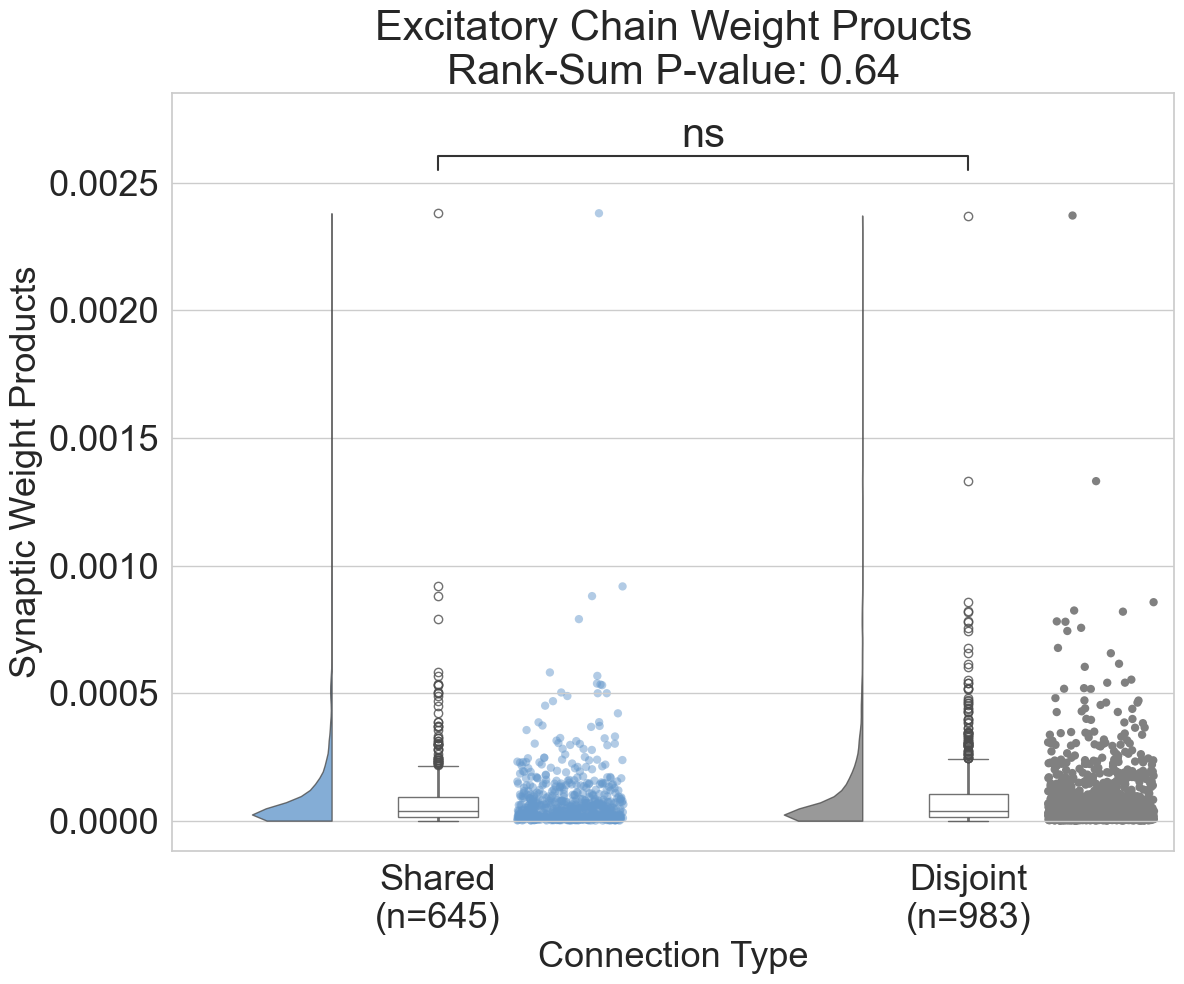

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=645) vs. Disjoint
(n=983): Custom statistical test, P_val:6.431e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


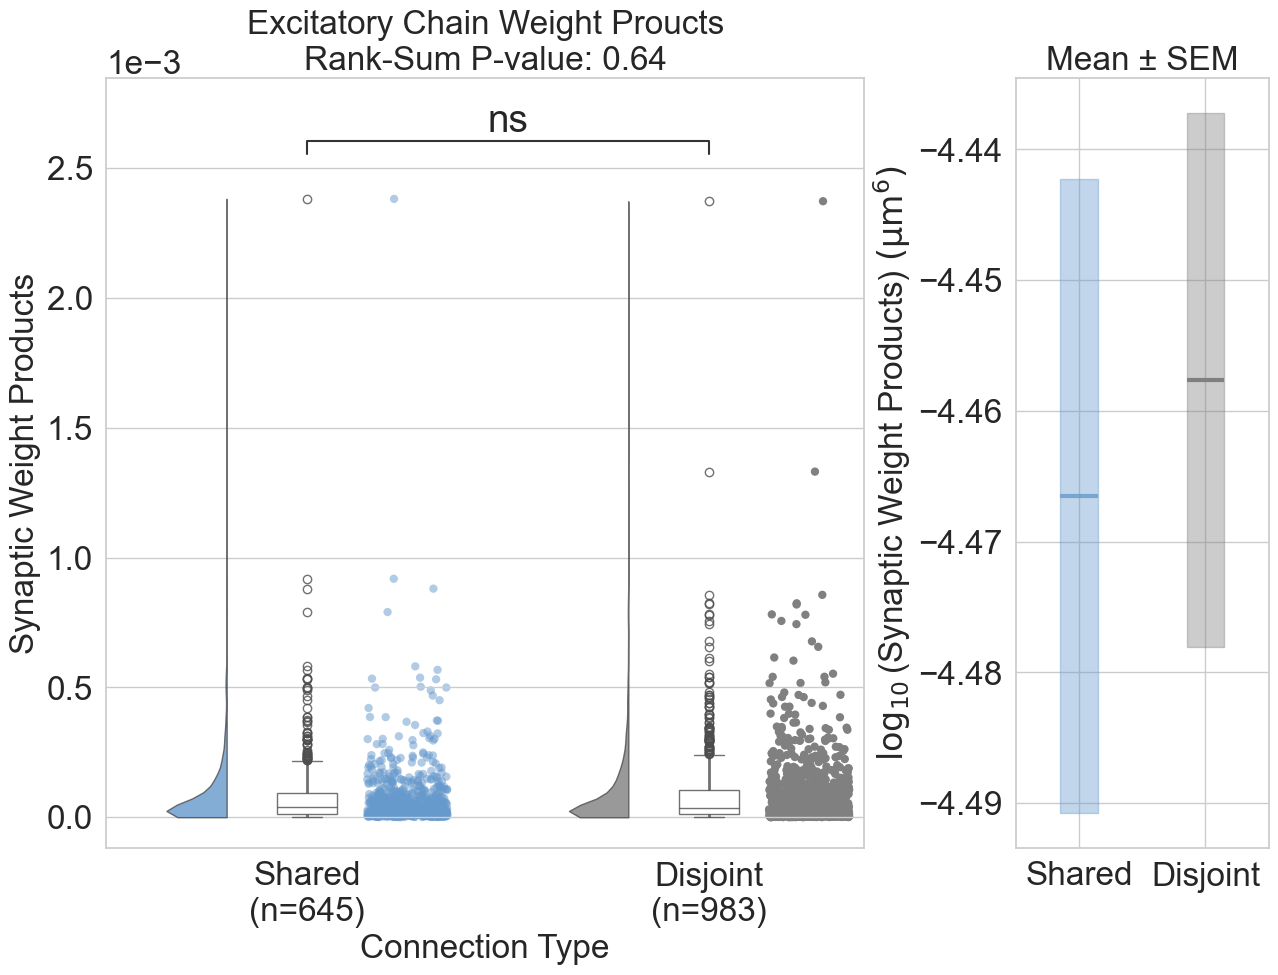

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 0.6732, P-value: 0.7496

[UNPAIRED] Effect sizes (pos = 'less')  n1=4903, n2=8417
  Test p-value: 0.7496
  Shared median = 0.00046658, Disjoint median = 0.000459416

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -4.26632e-06 : CI [-1.75827e-05, 8.57578e-06]
    PS:       0.497 : CI [0.487, 0.507]   (δ=-0.007 : CI [-0.027, 0.014])
    Cohen's d: -0.013 : CI [-0.049, 0.022]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -4.26632e-06 : CI [-1.72356e-05, 8.73989e-06]
    PS:       0.497 : CI [0.486, 0.507]   (δ=-0.007 : CI [-0.027, 0.013])
    Cohen's d: -0.013 : CI [-0.049, 0.021]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=4903) vs. Disjoint
(n=8417): Custom statistical test, P_val:7.496e-01


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


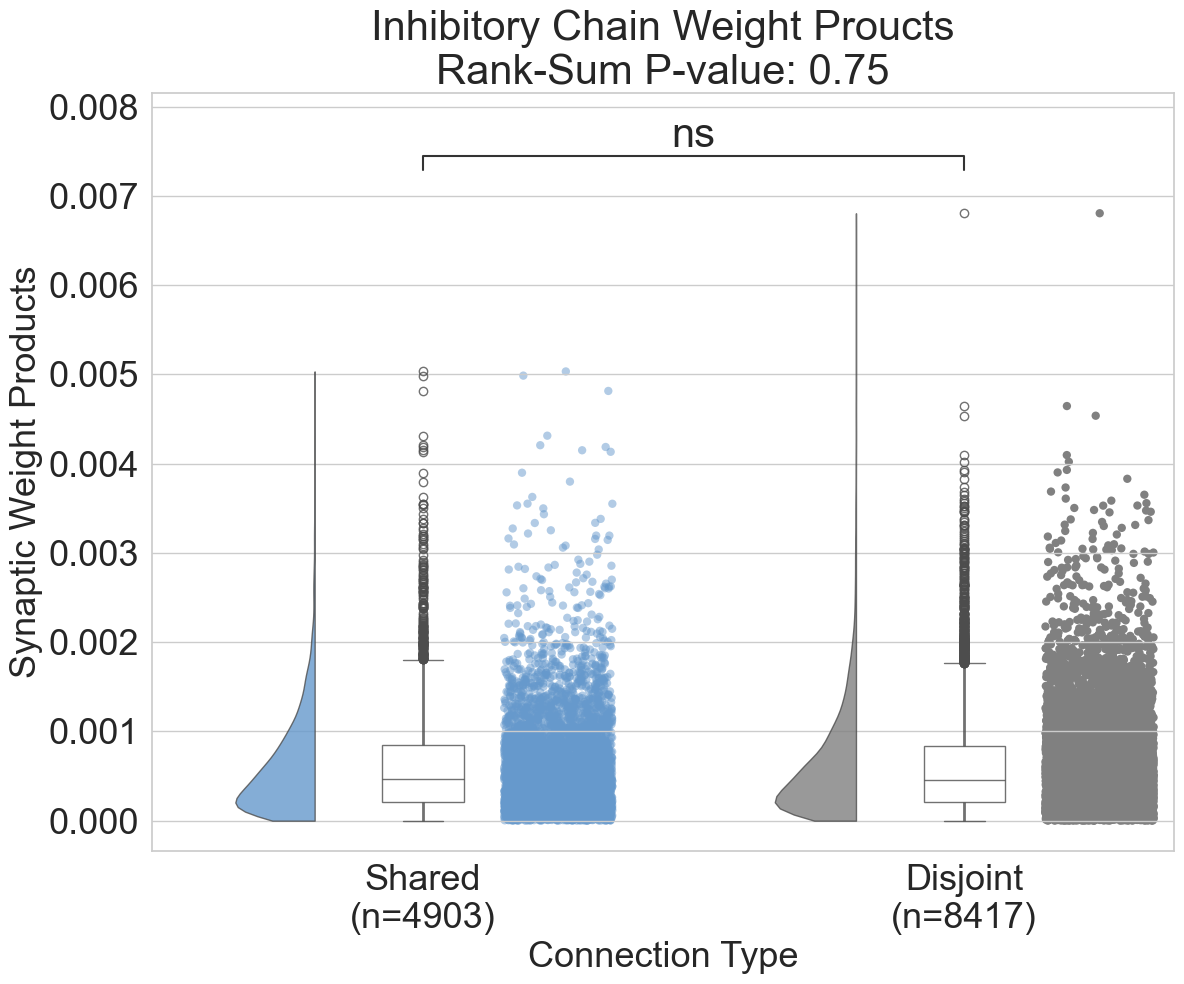

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=4903) vs. Disjoint
(n=8417): Custom statistical test, P_val:7.496e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


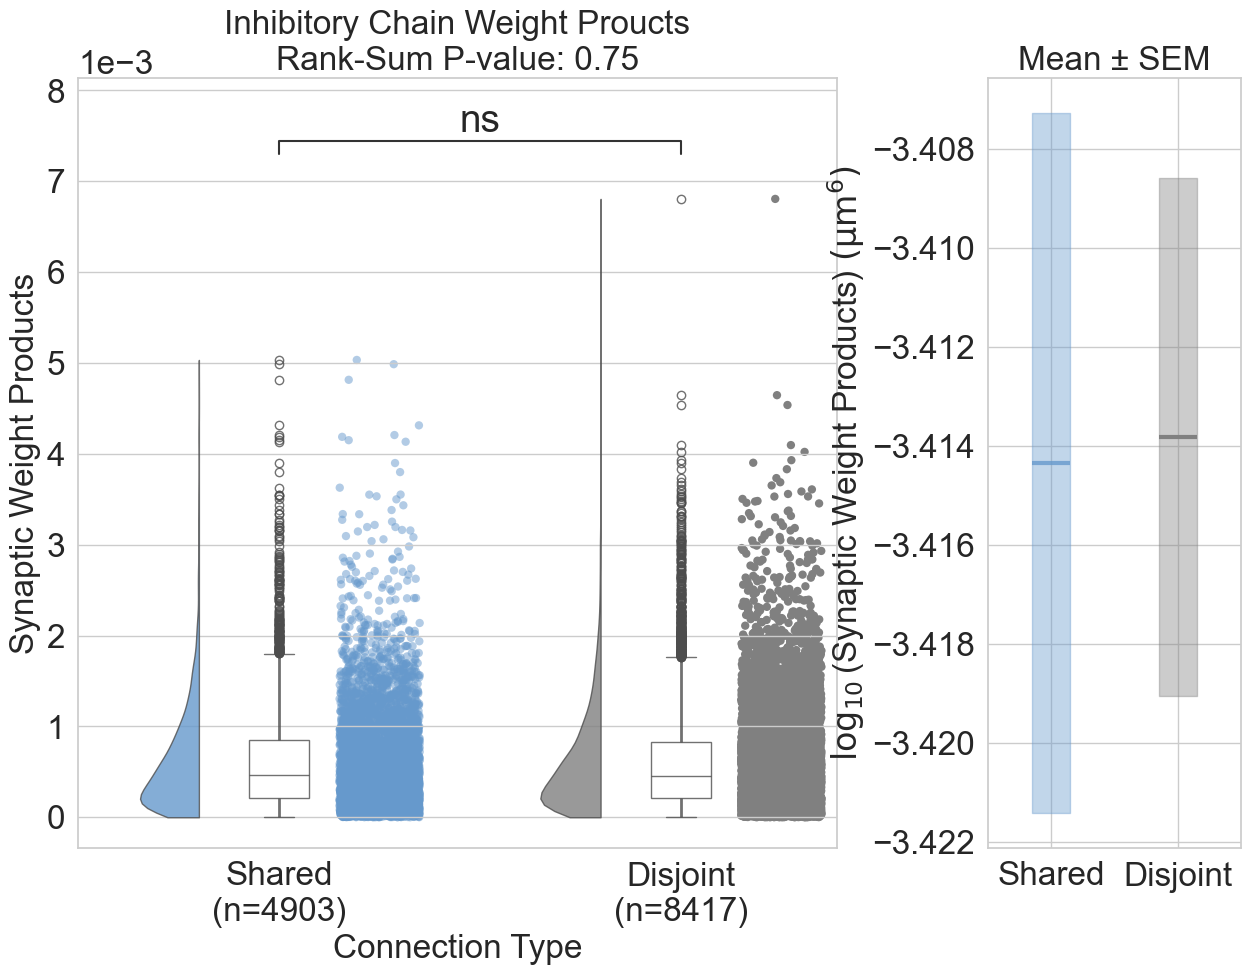

In [58]:
ranksum_signedrank_two_group_comparison(W_pairwise['excitatory'],
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn_E_Chain'
                                        )


ranksum_signedrank_two_group_comparison(W_pairwise['inhibitory'],
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 1.147, P-value: 0.1257

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=61
  Test p-value: 0.1262
  Shared median = 0.000292846, Disjoint median = 0.000212562

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 4.41141e-05 : CI [-2.49933e-05, 0.000133248]
    PS:       0.560 : CI [0.458, 0.669]   (δ=0.120 : CI [-0.084, 0.338])
    Cohen's d: 0.212 : CI [-0.158, 0.622]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 4.41141e-05 : CI [-2.92598e-05, 0.000129246]
    PS:       0.560 : CI [0.452, 0.665]   (δ=0.120 : CI [-0.096, 0.331])
    Cohen's d: 0.212 : CI [-0.177, 0.576]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 1270, P-value: 0.004483

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=61
  Test p-value: 0.004483
  Median paired difference = 3.22856e-05

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 3.22856e-05 : CI [7.08807e-06, 7.32012e-05

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


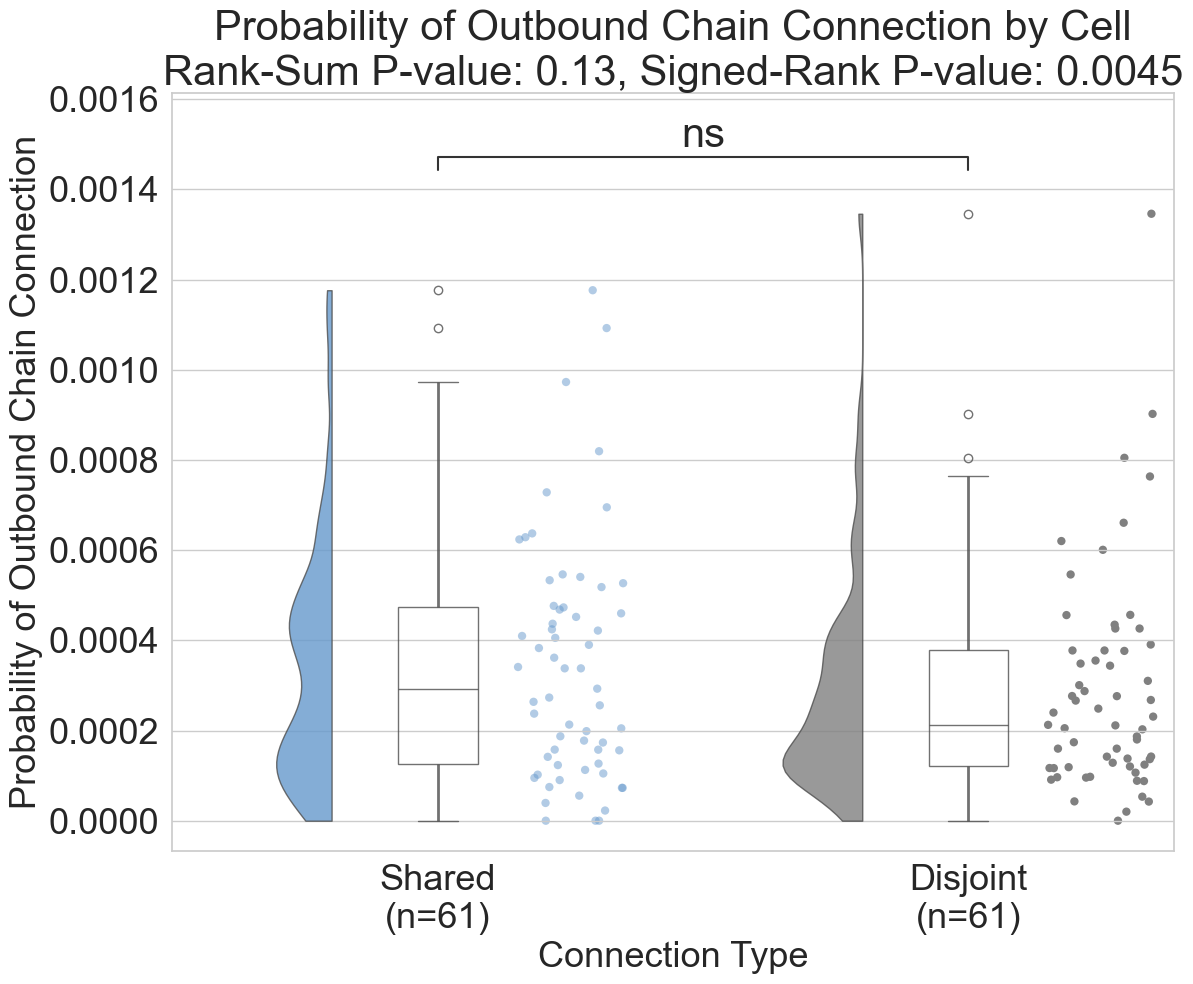

C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  wa

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=61) vs. Disjoint
(n=61): Custom statistical test, P_val:1.257e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


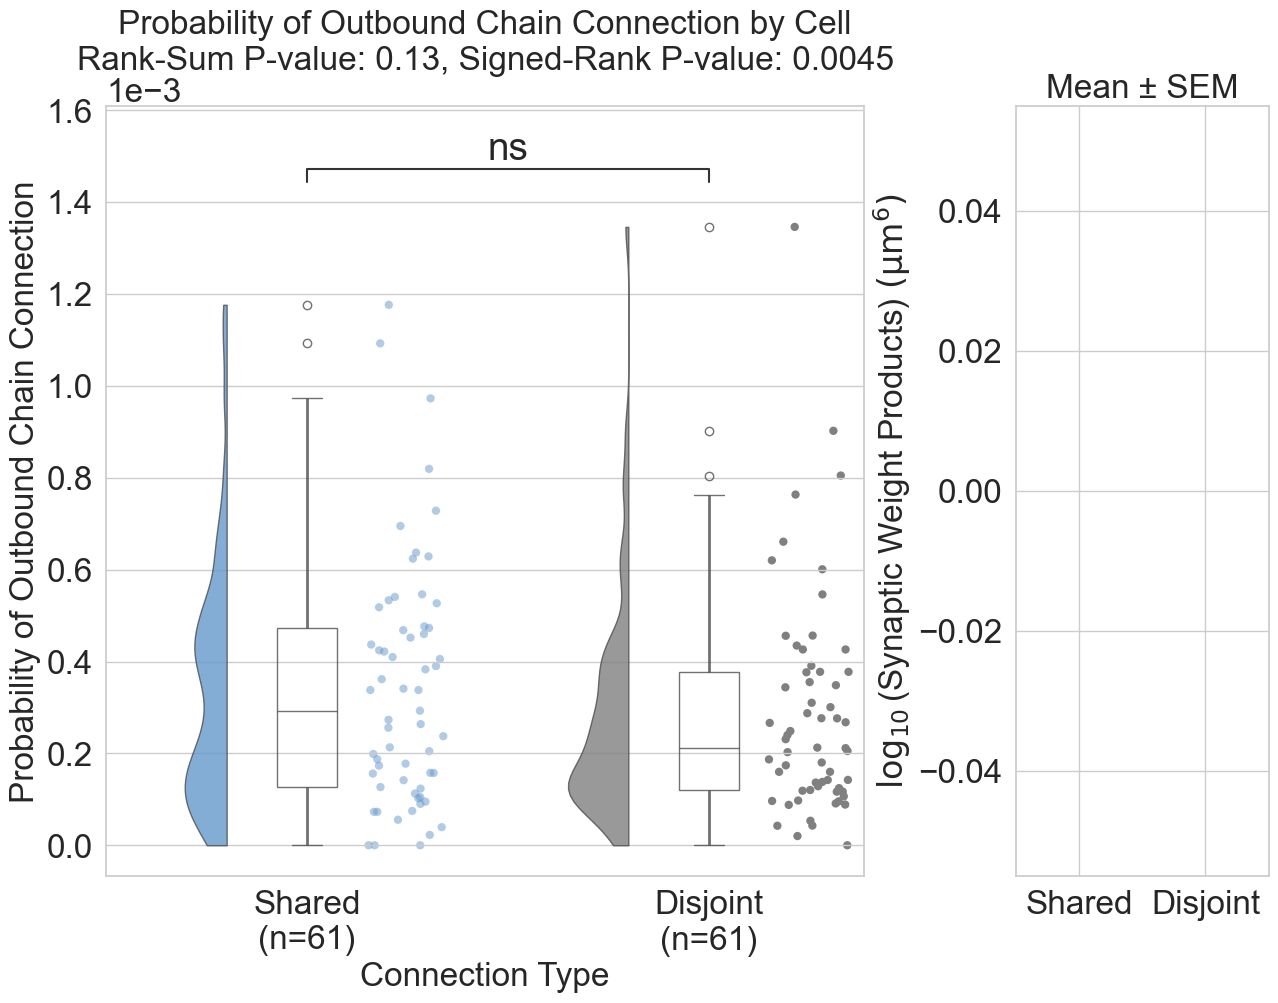

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 0.8577, P-value: 0.8045

[UNPAIRED] Effect sizes (pos = 'less')  n1=61, n2=61
  Test p-value: 0.8052
  Shared median = 0.02959, Disjoint median = 0.0282588

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.00128798 : CI [-0.00428606, 0.00221035]
    PS:       0.455 : CI [0.357, 0.565]   (δ=-0.090 : CI [-0.285, 0.129])
    Cohen's d: -0.157 : CI [-0.506, 0.215]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -0.00128798 : CI [-0.00428614, 0.00220499]
    PS:       0.455 : CI [0.360, 0.567]   (δ=-0.090 : CI [-0.281, 0.134])
    Cohen's d: -0.157 : CI [-0.496, 0.220]
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 1606, P-value: 1

[PAIRED] Effect sizes (pos = 'less')  n_pairs=61
  Test p-value: 1
  Median paired difference = 0.00198752

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -0.00198752 : CI [-0.00220522, -0.00139624]
    PS:       0.230 : CI

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


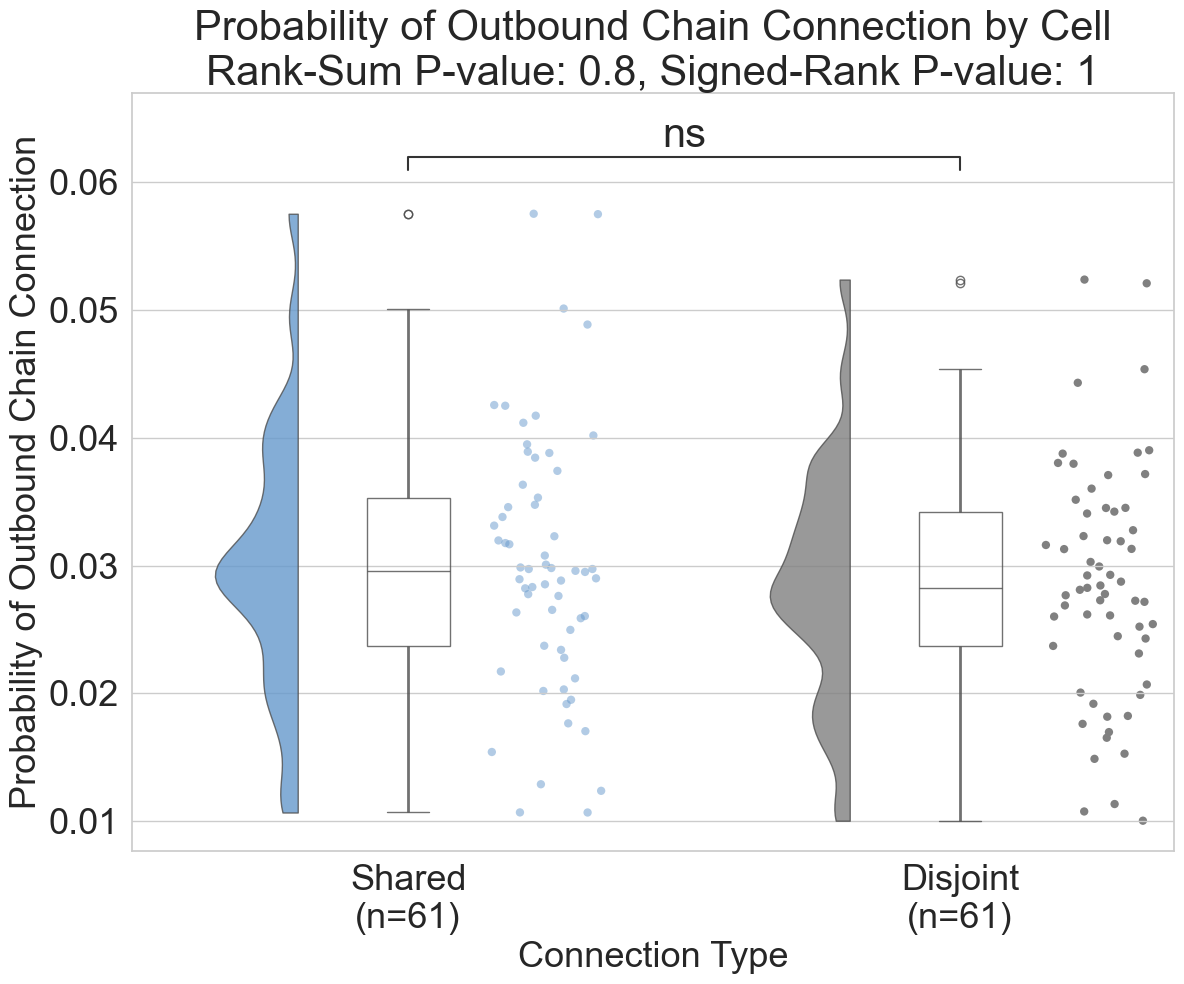

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=61) vs. Disjoint
(n=61): Custom statistical test, P_val:8.045e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


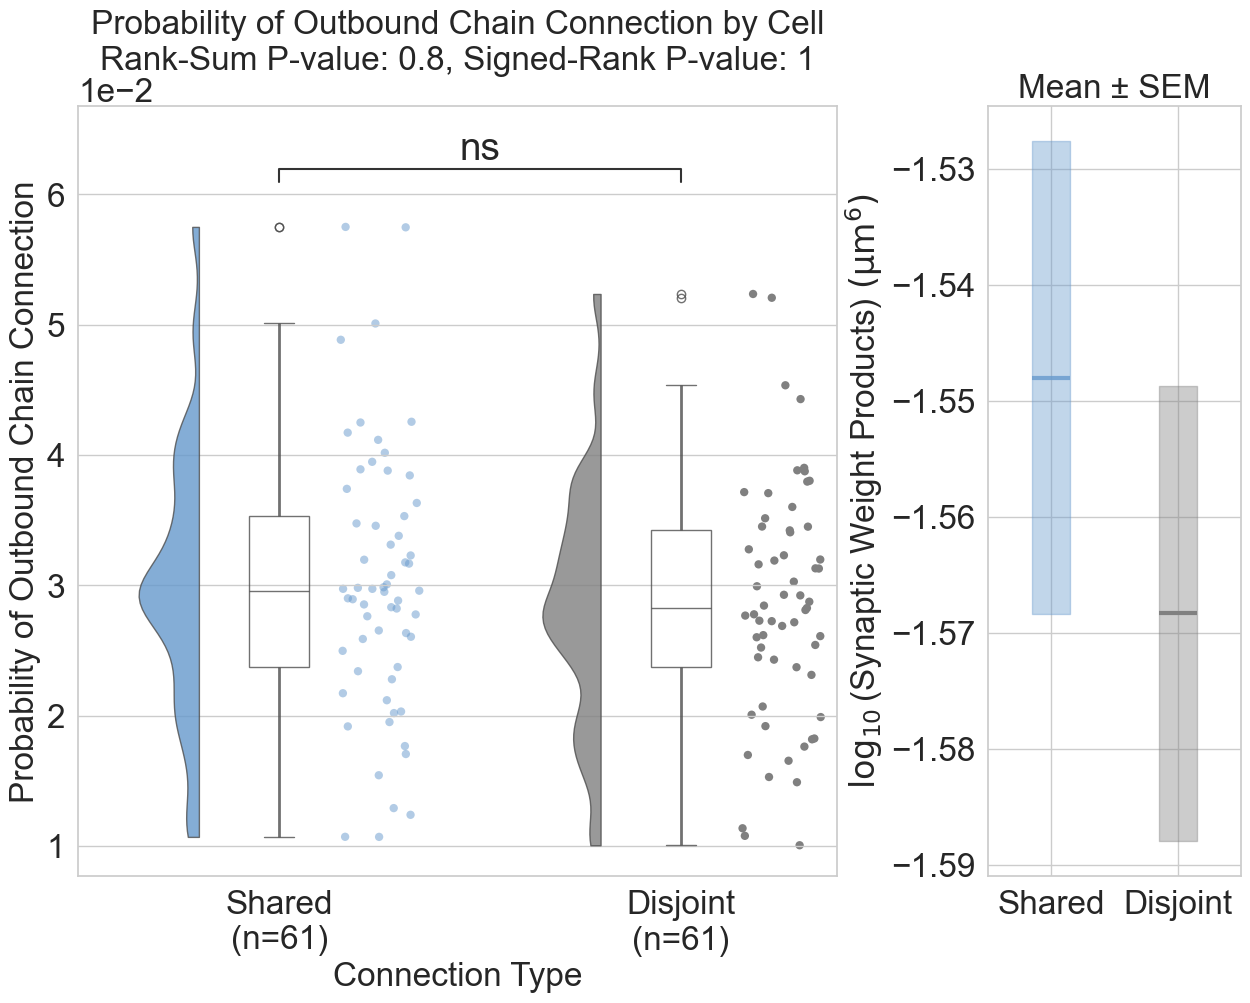

In [68]:
ranksum_signedrank_two_group_comparison(B_out['excitatory'],
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Prob_Outbound_Conn_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(B_out['inhibitory'],
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Prob_Outbound_Conn_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.8451, P-value: 0.801

[UNPAIRED] Effect sizes (pos = 'greater')  n1=58, n2=60
  Test p-value: 0.8017
  Shared median = 5.15779e-05, Disjoint median = 5.49864e-05

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -5.54194e-06 : CI [-1.80484e-05, 7.29521e-06]
    PS:       0.455 : CI [0.355, 0.559]   (δ=-0.090 : CI [-0.290, 0.119])
    Cohen's d: 0.065 : CI [-0.343, 0.374]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -5.54194e-06 : CI [-1.86982e-05, 6.72535e-06]
    PS:       0.455 : CI [0.348, 0.555]   (δ=-0.090 : CI [-0.303, 0.109])
    Cohen's d: 0.065 : CI [-0.332, 0.387]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 776, P-value: 0.7309

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=58
  Test p-value: 0.7309
  Median paired difference = -2.38582e-06

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -2.38582e-06 : CI [-1.10426e-05, 3.96186e

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


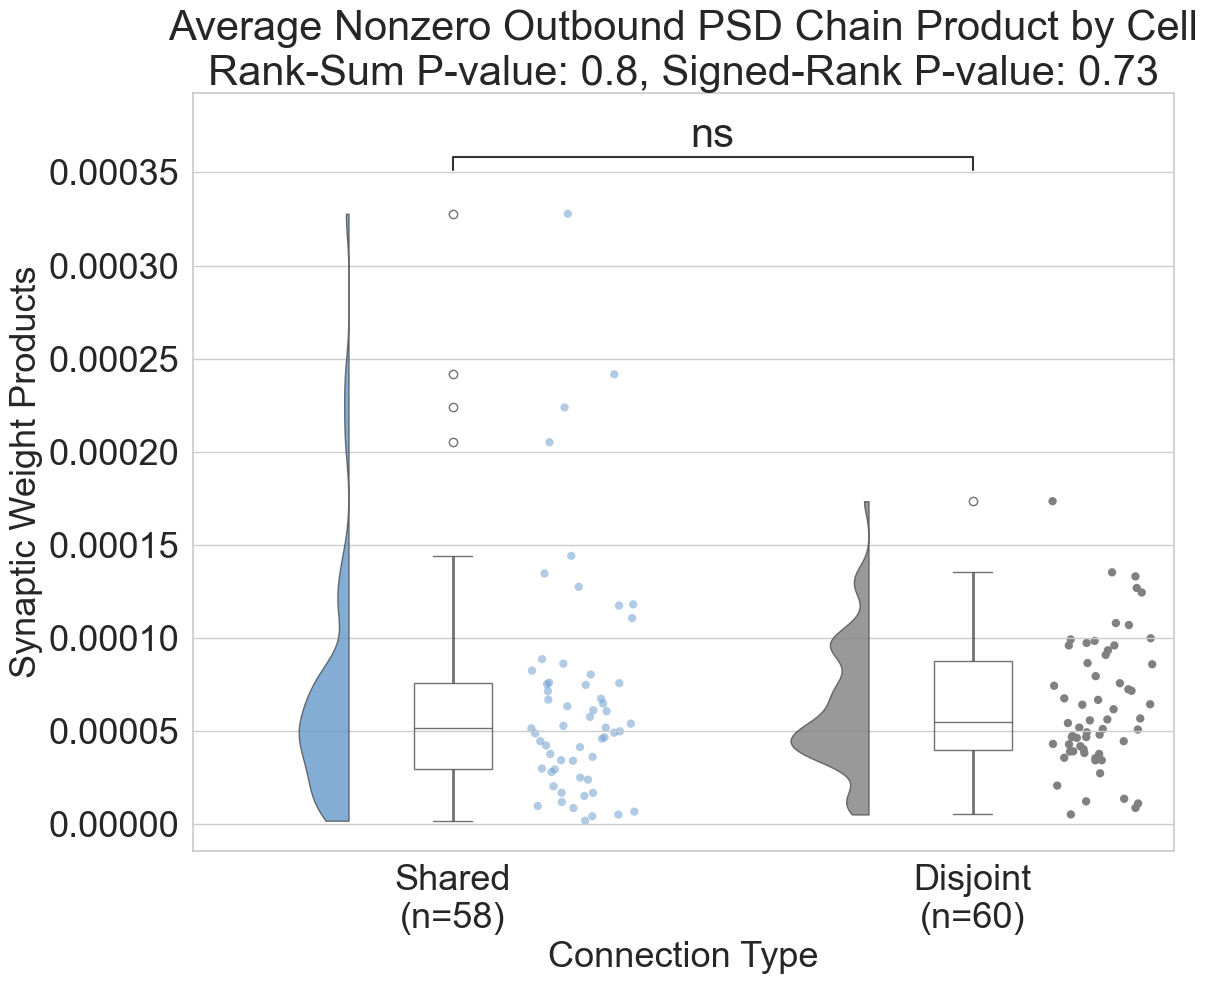

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=58) vs. Disjoint
(n=60): Custom statistical test, P_val:8.010e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


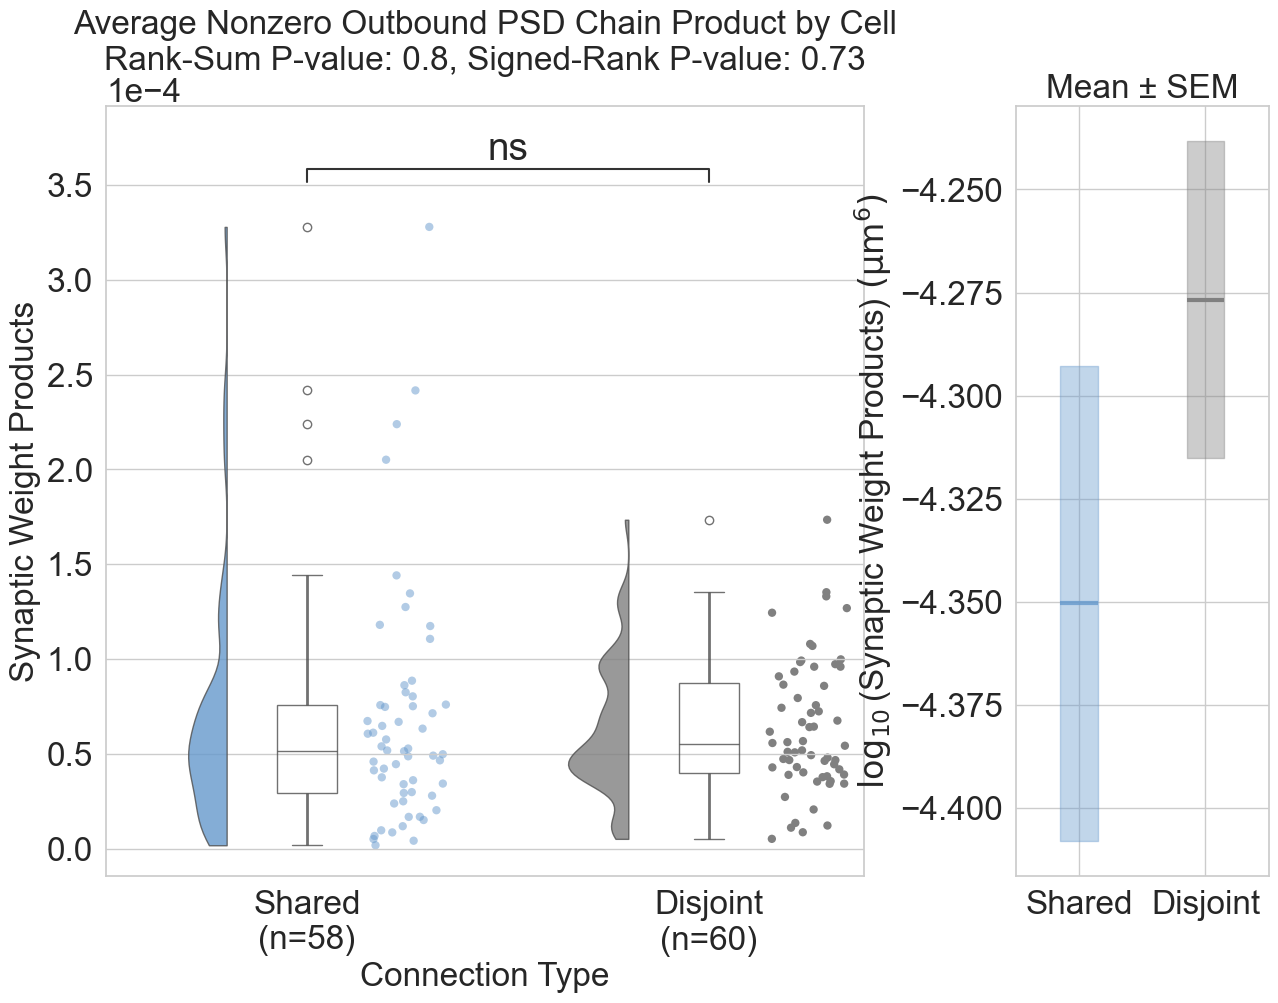

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -0.361, P-value: 0.3591

[UNPAIRED] Effect sizes (pos = 'less')  n1=61, n2=61
  Test p-value: 0.36
  Shared median = 5.00381e-05, Disjoint median = 4.99657e-05

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 9.17307e-07 : CI [-3.71909e-06, 5.31172e-06]
    PS:       0.519 : CI [0.414, 0.624]   (δ=0.038 : CI [-0.172, 0.247])
    Cohen's d: 0.054 : CI [-0.307, 0.419]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 9.17307e-07 : CI [-3.41713e-06, 5.71712e-06]
    PS:       0.519 : CI [0.419, 0.631]   (δ=0.038 : CI [-0.162, 0.262])
    Cohen's d: 0.054 : CI [-0.296, 0.438]
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 894, P-value: 0.3557

[PAIRED] Effect sizes (pos = 'less')  n_pairs=61
  Test p-value: 0.3557
  Median paired difference = 2.6584e-07

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -2.6584e-07 : CI [-1.31907e-06, 1.33919e-06]
    PS:   

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


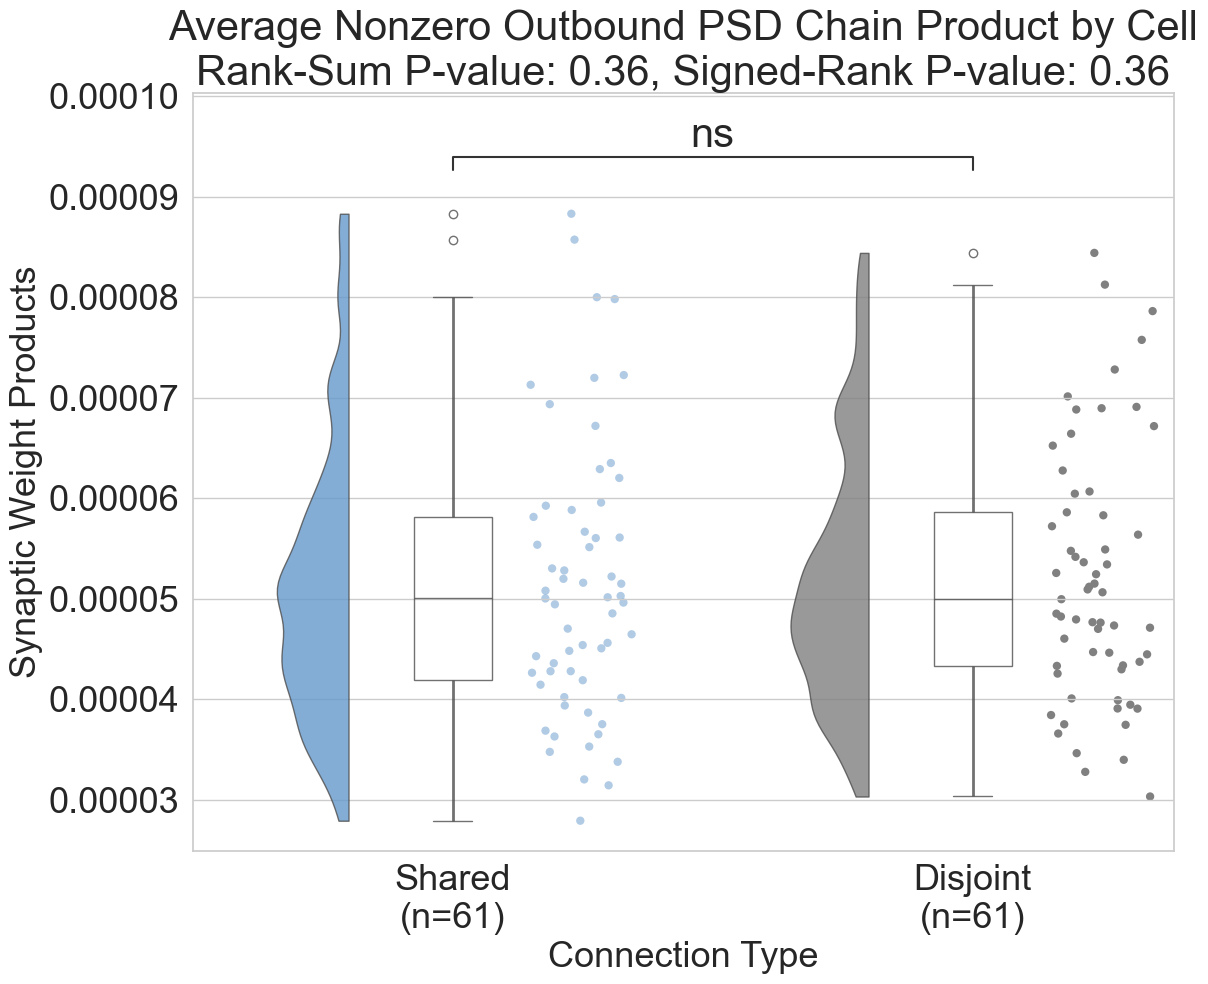

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=61) vs. Disjoint
(n=61): Custom statistical test, P_val:3.591e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


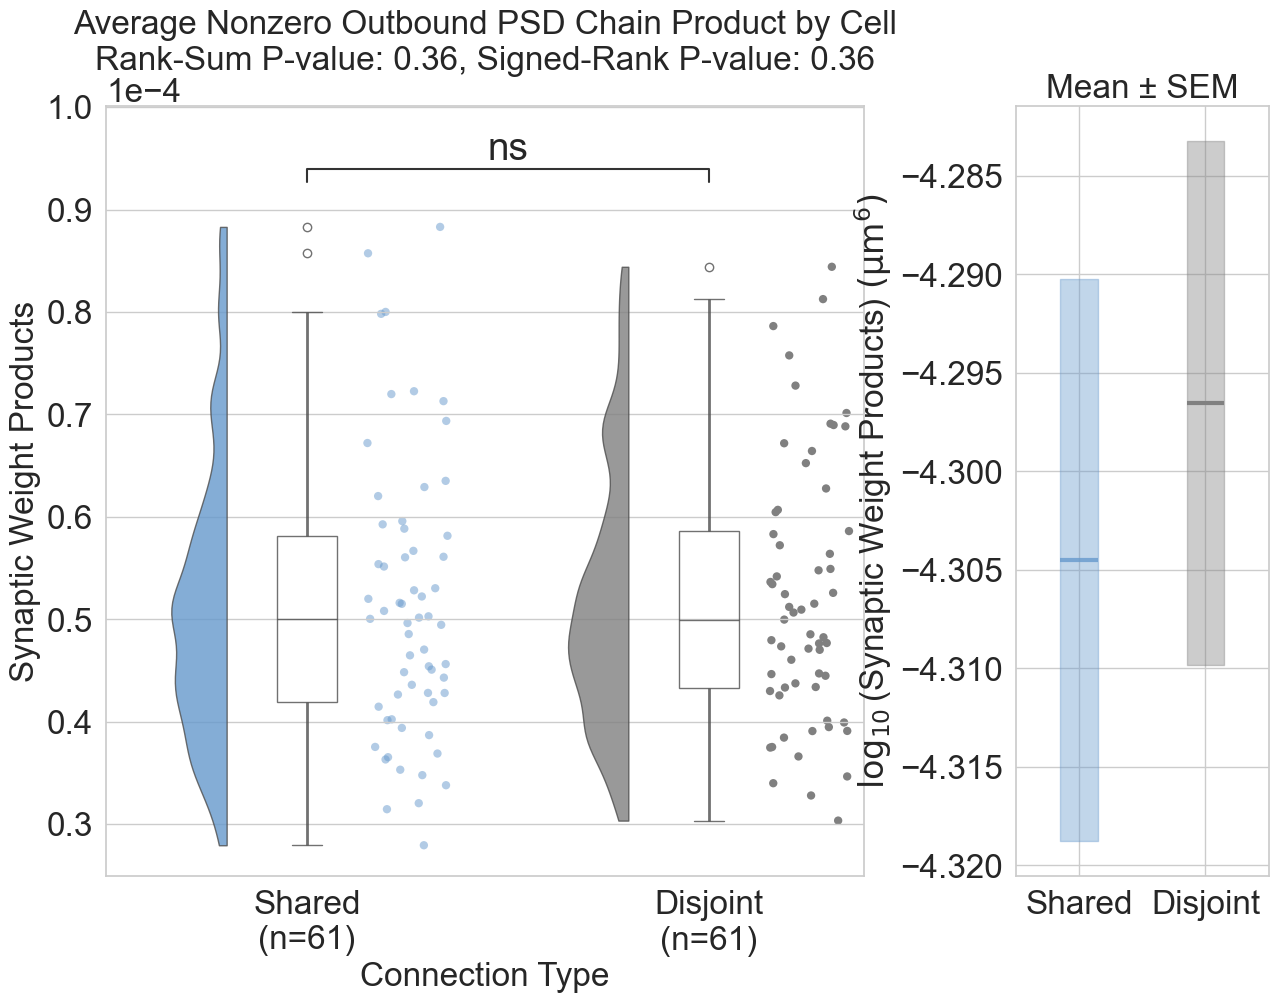

In [60]:
ranksum_signedrank_two_group_comparison(W_out['excitatory'],
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Outbound_PSD_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(W_out['inhibitory'],
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Outbound_PSD_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.7304, P-value: 0.7674

[UNPAIRED] Effect sizes (pos = 'greater')  n1=220, n2=221
  Test p-value: 0.7691
  Shared median = 0.000196, Disjoint median = 0.000251931

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [-6.56134e-05, 5.50862e-06]
    PS:       0.480 : CI [0.424, 0.531]   (δ=-0.040 : CI [-0.151, 0.061])
    Cohen's d: 0.084 : CI [-0.122, 0.240]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0 : CI [-8.20569e-05, 0]
    PS:       0.480 : CI [0.426, 0.532]   (δ=-0.040 : CI [-0.148, 0.064])
    Cohen's d: 0.084 : CI [-0.104, 0.253]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 8163, P-value: 0.8008

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=220
  Test p-value: 0.8008
  Median paired difference = 0

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0 : CI [-2.15941e-05, 0]
    PS:       0.466 : CI [0.405, 0.527]   (δ=-0.068 : CI 

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


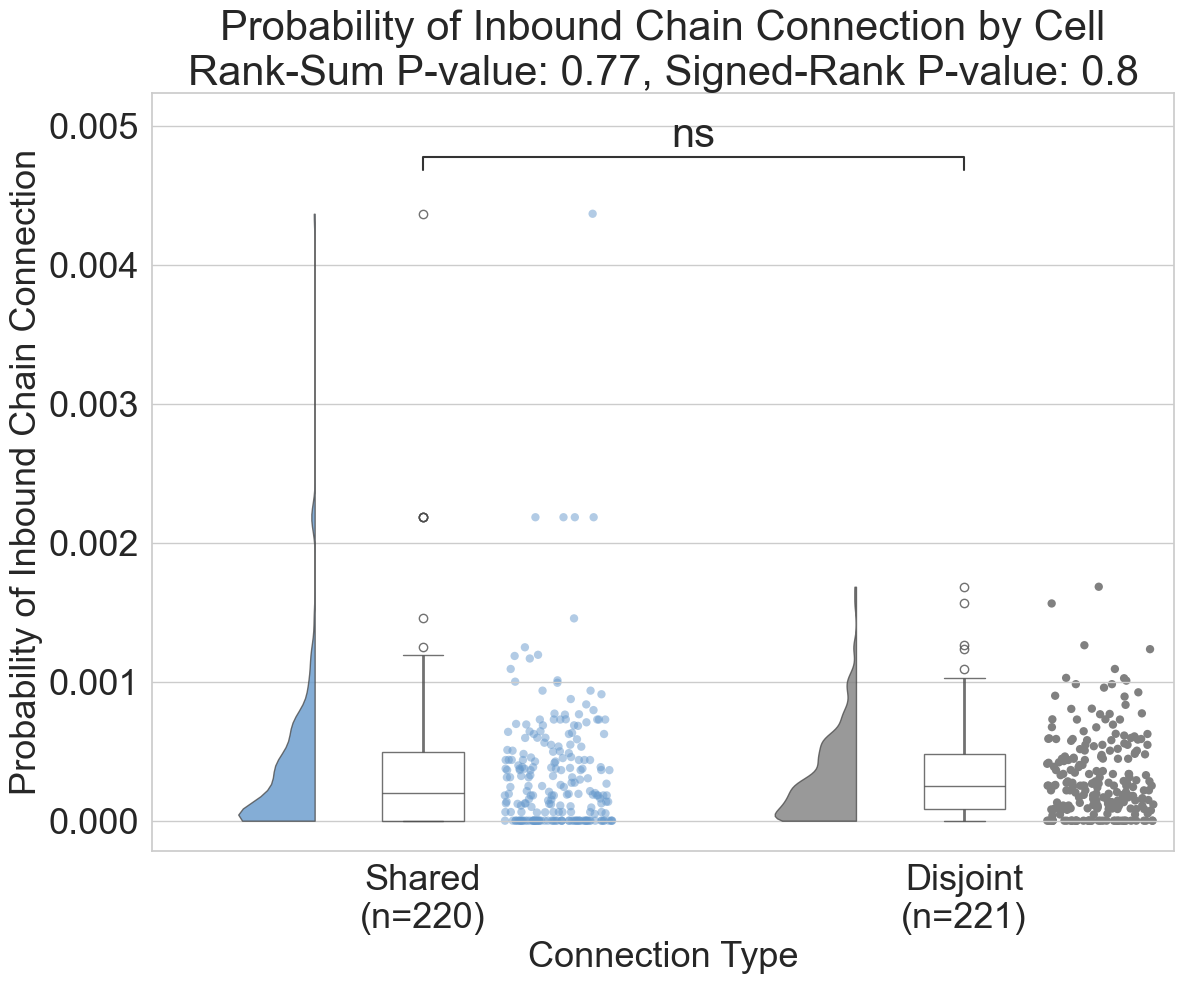

C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  wa

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=220) vs. Disjoint
(n=221): Custom statistical test, P_val:7.674e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


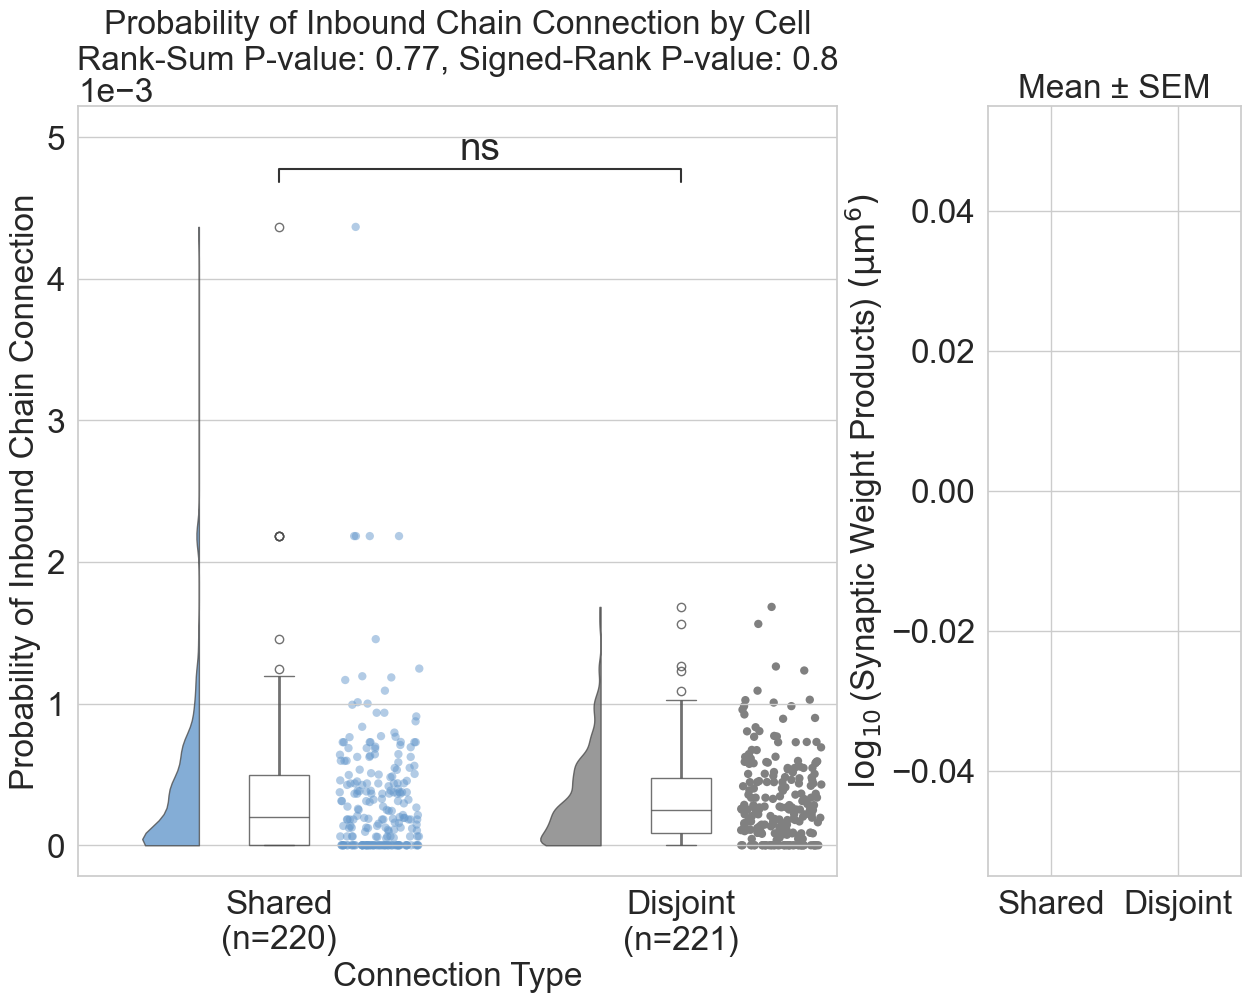

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -1.077, P-value: 0.1408

[UNPAIRED] Effect sizes (pos = 'less')  n1=220, n2=221
  Test p-value: 0.1409
  Shared median = 0.0276825, Disjoint median = 0.0287956

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.00122514 : CI [-0.00108636, 0.00349032]
    PS:       0.530 : CI [0.475, 0.584]   (δ=0.059 : CI [-0.049, 0.167])
    Cohen's d: 0.095 : CI [-0.093, 0.281]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 0.00122514 : CI [-0.000907831, 0.00373198]
    PS:       0.530 : CI [0.479, 0.589]   (δ=0.059 : CI [-0.043, 0.177])
    Cohen's d: 0.095 : CI [-0.080, 0.295]
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 7212, P-value: 8.493e-08

[PAIRED] Effect sizes (pos = 'less')  n_pairs=220
  Test p-value: 8.493e-08
  Median paired difference = -0.0012383

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 0.0012383 : CI [0.000699746, 0.00164113]
    PS:    

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


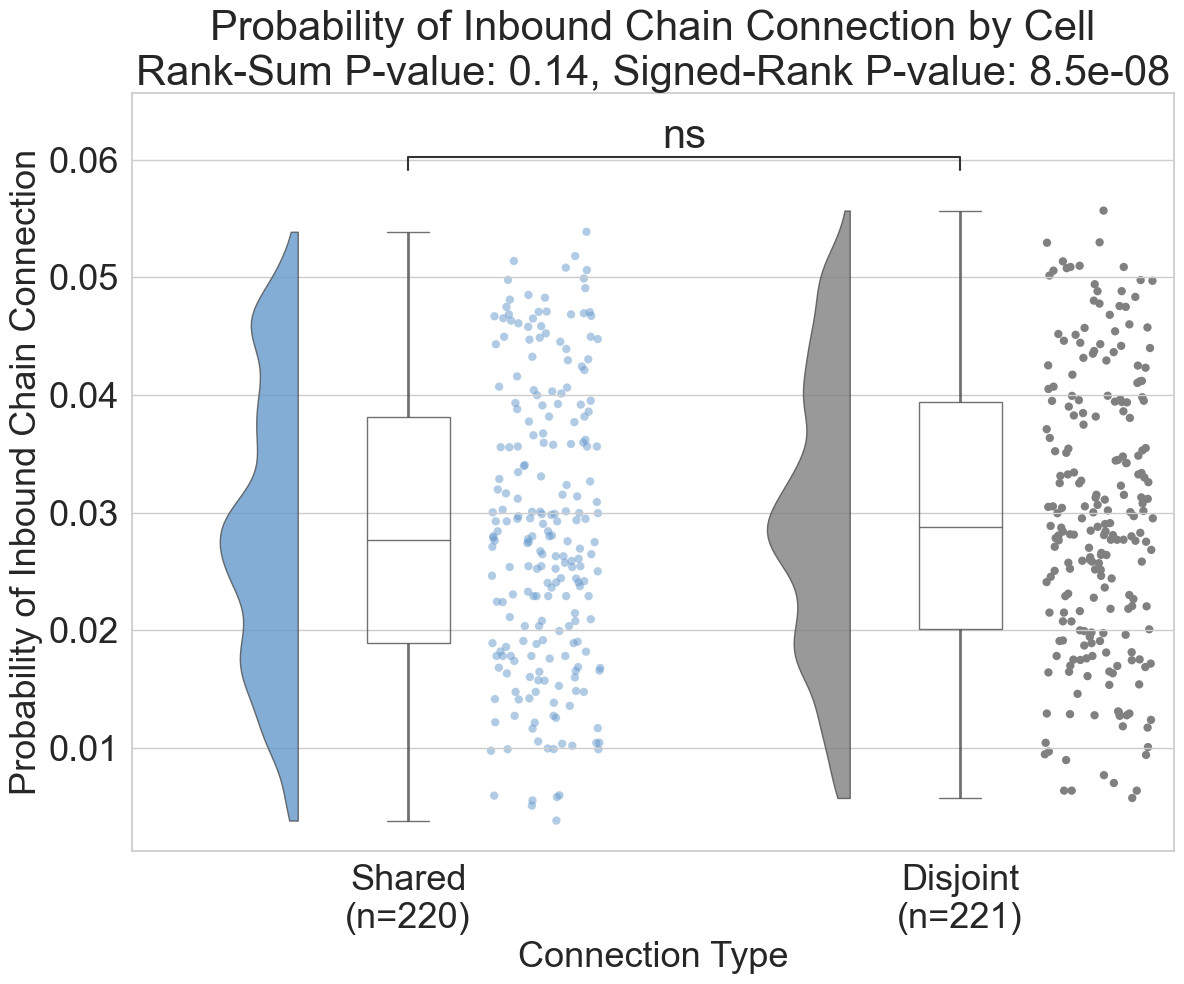

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=220) vs. Disjoint
(n=221): Custom statistical test, P_val:1.408e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


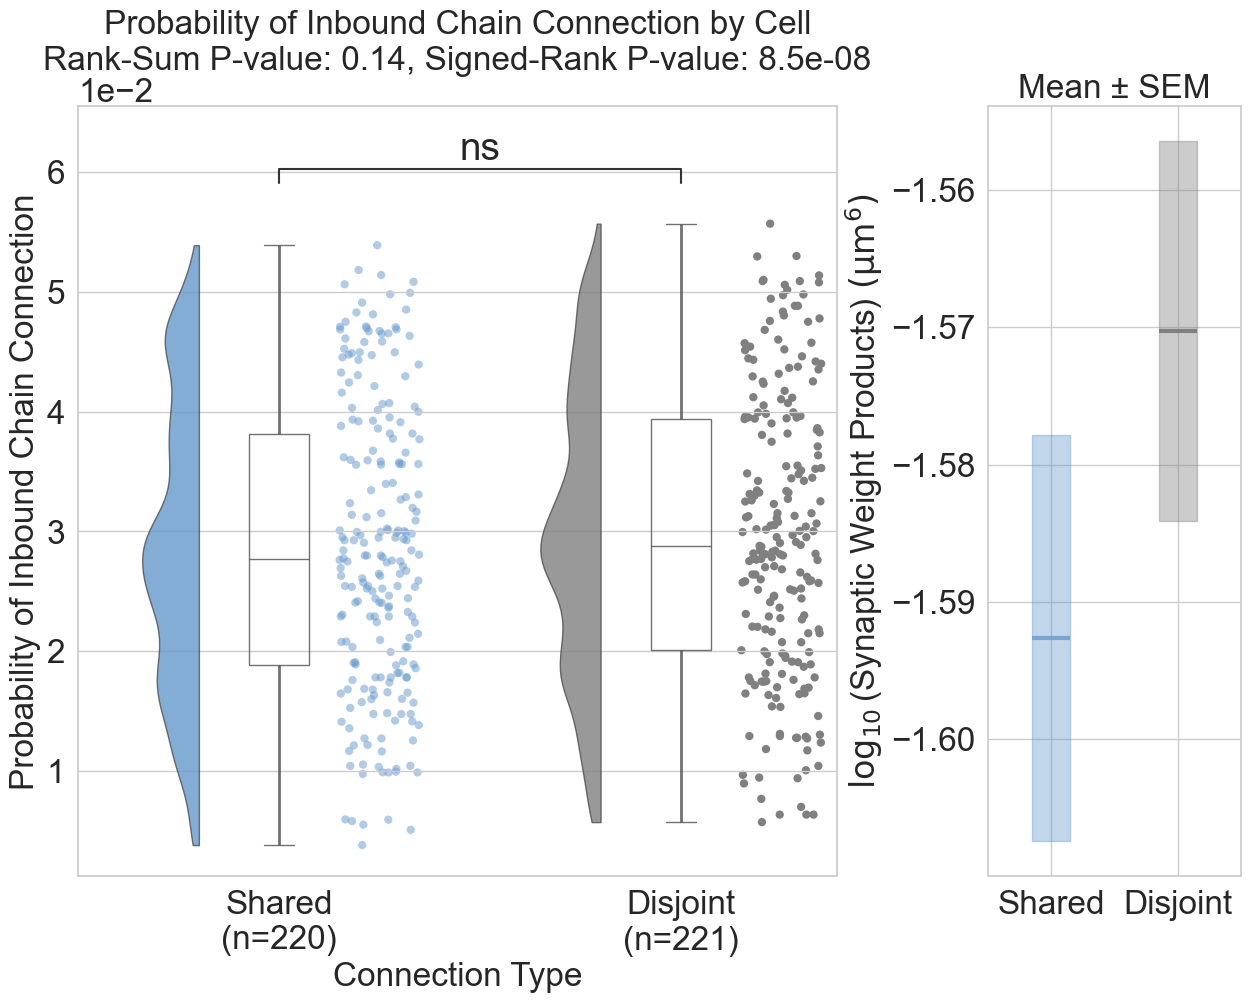

In [61]:
ranksum_signedrank_two_group_comparison(B_in['excitatory'],
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Prob_Inbound_Conn_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(B_in['inhibitory'],
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Prob_Inbound_Conn_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.9726, P-value: 0.8346

[UNPAIRED] Effect sizes (pos = 'greater')  n1=156, n2=179
  Test p-value: 0.8348
  Shared median = 4.91422e-05, Disjoint median = 5.29797e-05

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -4.05518e-06 : CI [-1.2397e-05, 4.75276e-06]
    PS:       0.469 : CI [0.410, 0.533]   (δ=-0.062 : CI [-0.180, 0.066])
    Cohen's d: -0.026 : CI [-0.225, 0.202]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -4.05518e-06 : CI [-1.28922e-05, 4.04753e-06]
    PS:       0.469 : CI [0.406, 0.530]   (δ=-0.062 : CI [-0.189, 0.059])
    Cohen's d: -0.026 : CI [-0.235, 0.188]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 4292, P-value: 0.9759

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=145
  Test p-value: 0.9759
  Median paired difference = -1.08239e-05

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -1.08239e-05 : CI [-1.86861e-05, -5

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


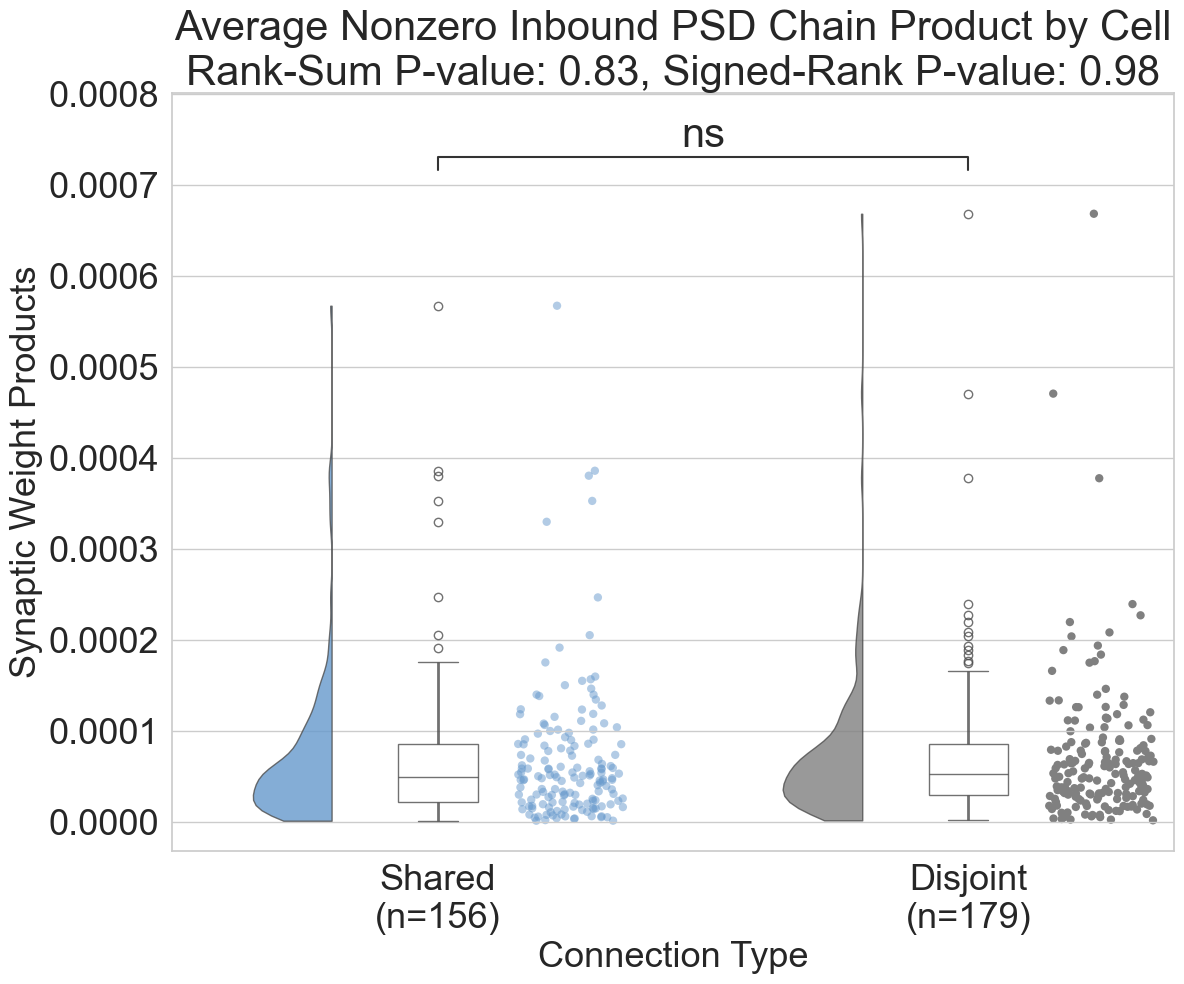

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=156) vs. Disjoint
(n=179): Custom statistical test, P_val:8.346e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


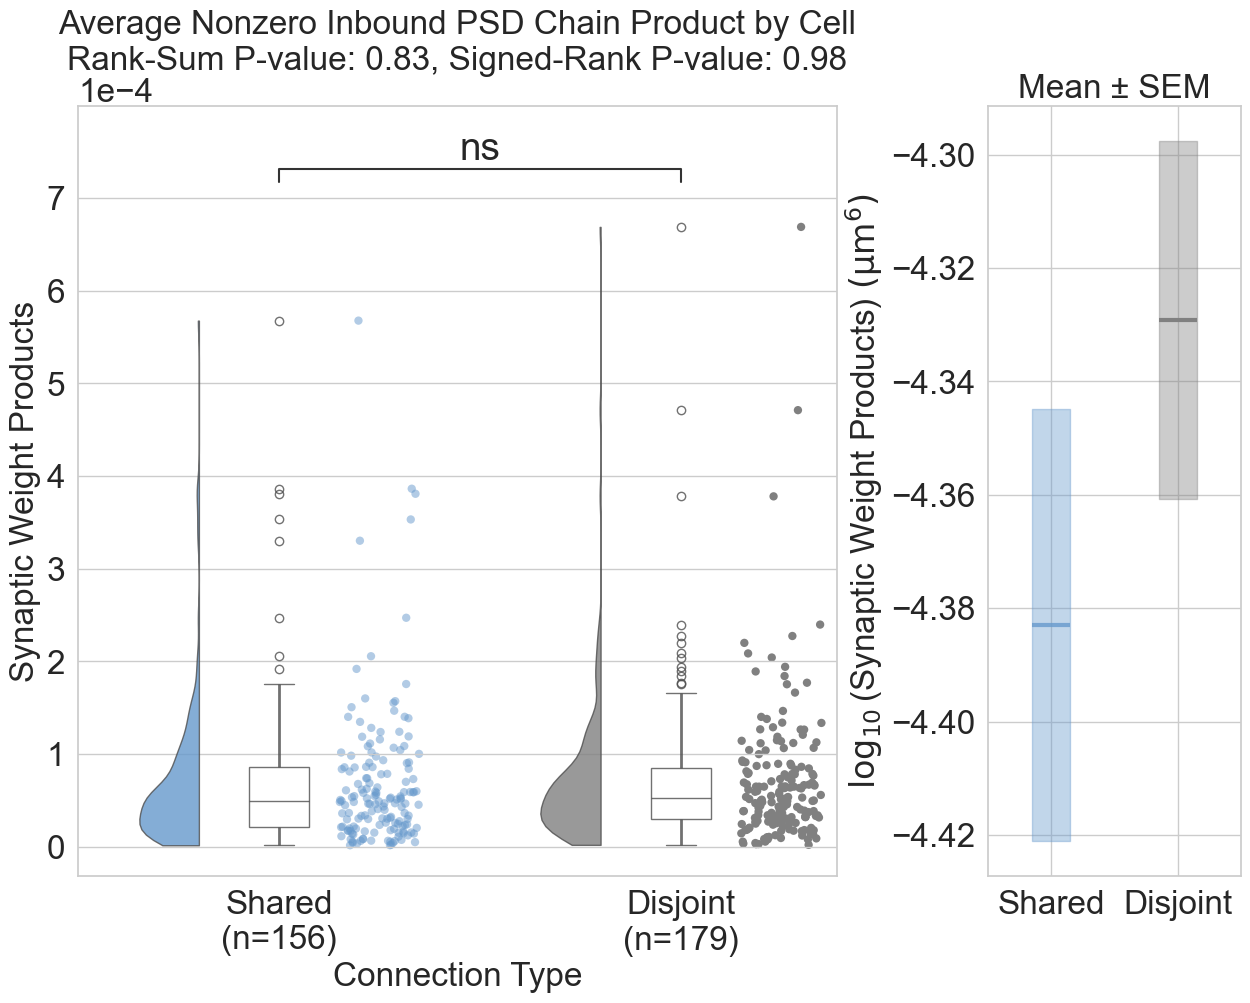

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -1.575, P-value: 0.0576

[UNPAIRED] Effect sizes (pos = 'less')  n1=220, n2=221
  Test p-value: 0.05765
  Shared median = 4.90573e-05, Disjoint median = 5.06235e-05

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 2.31829e-06 : CI [-6.17902e-07, 5.3003e-06]
    PS:       0.543 : CI [0.489, 0.598]   (δ=0.087 : CI [-0.022, 0.196])
    Cohen's d: 0.146 : CI [-0.041, 0.337]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: 2.31829e-06 : CI [-6.46241e-07, 5.16896e-06]
    PS:       0.543 : CI [0.488, 0.597]   (δ=0.087 : CI [-0.024, 0.195])
    Cohen's d: 0.146 : CI [-0.044, 0.335]
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 8485, P-value: 5.163e-05

[PAIRED] Effect sizes (pos = 'less')  n_pairs=220
  Test p-value: 5.163e-05
  Median paired difference = -1.90383e-06

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: 1.90383e-06 : CI [8.2202e-07, 2.59506e-06

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


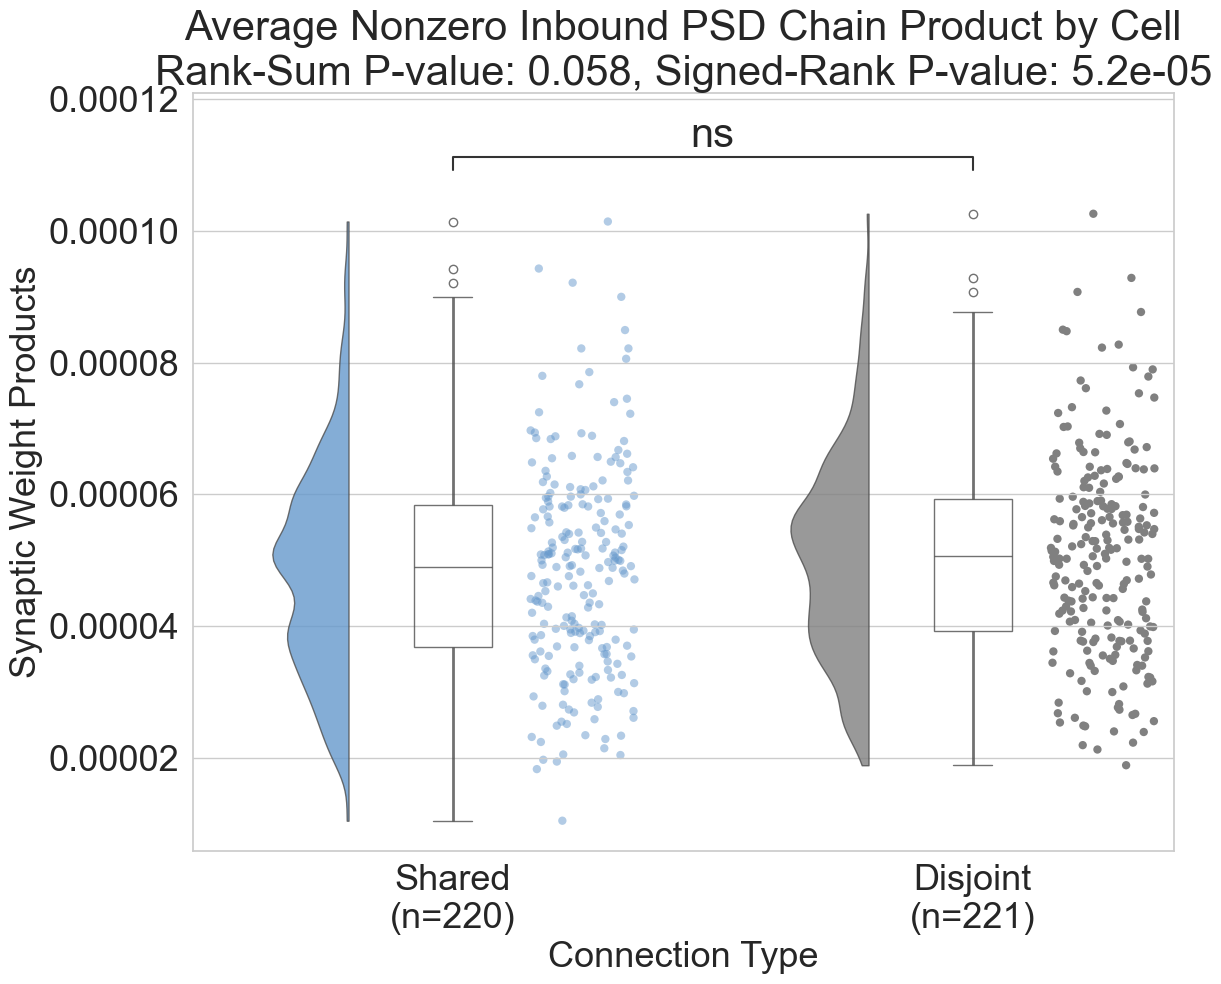

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=220) vs. Disjoint
(n=221): Custom statistical test, P_val:5.760e-02


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


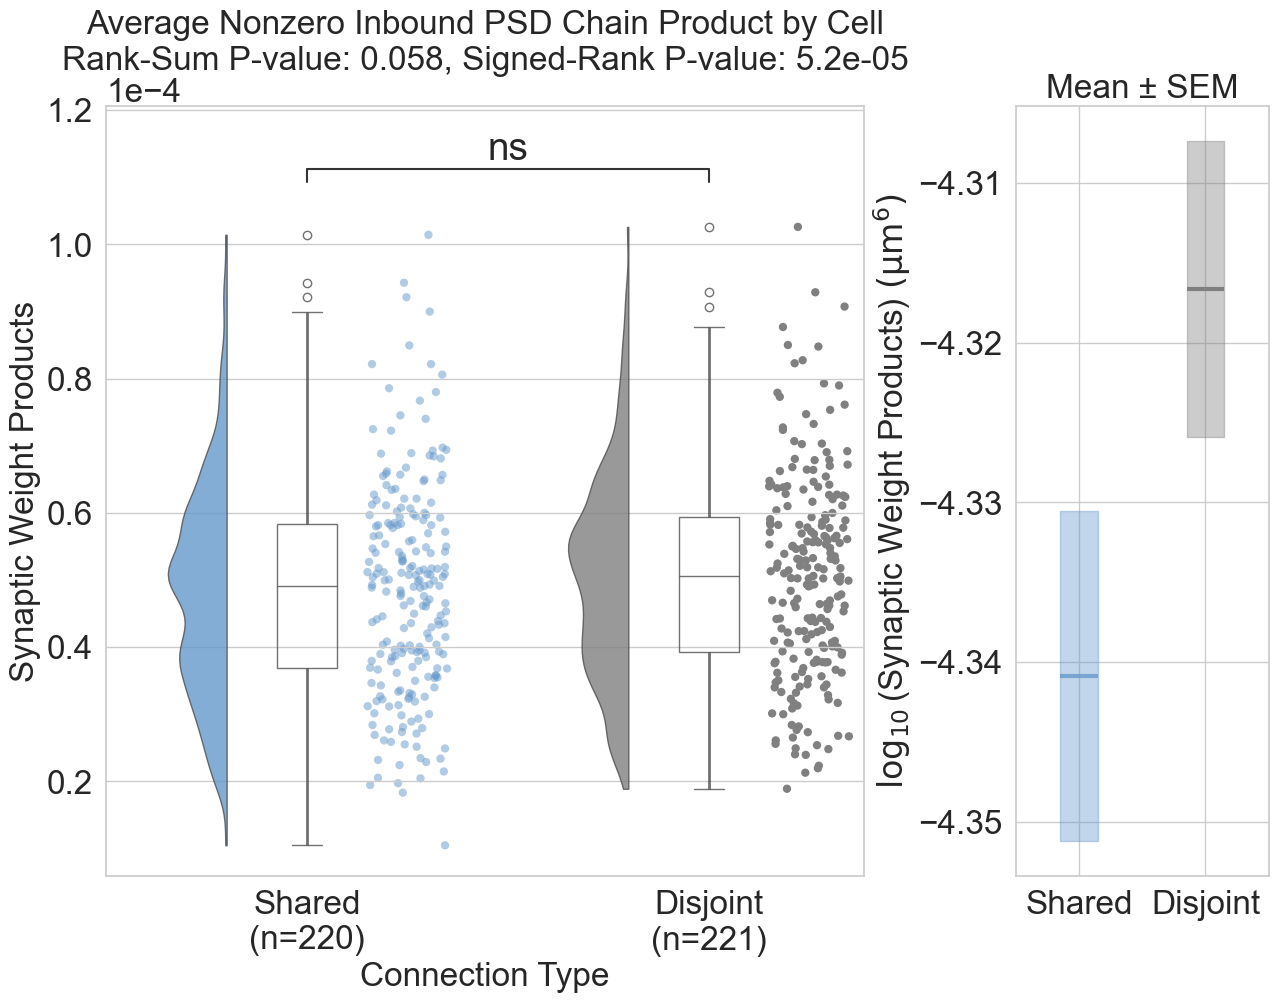

In [62]:
ranksum_signedrank_two_group_comparison(W_in['excitatory'],
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(W_in['inhibitory'],
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD_I_Chain'
                                        )

# Subsampling:

SUBSAMPLED
Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 0.9925, P-value: 0.8395

[UNPAIRED] Effect sizes (pos = 'less')  n1=645, n2=983
  Test p-value: 0.8395
  Shared median = 0.00045891, Disjoint median = 0.000446037

  Effect sizes with bootstrapped 95% CI (percentile):
    HL shift: -1.86773e-05 : CI [-5.85279e-05, 1.54553e-05]
    PS:       0.485 : CI [0.456, 0.512]   (δ=-0.029 : CI [-0.088, 0.024])
    Cohen's d: -0.045 : CI [-0.151, 0.054]

  Effect sizes with bootstrapped 95% CI (BCa):
    HL shift: -1.86773e-05 : CI [-5.4412e-05, 1.87564e-05]
    PS:       0.485 : CI [0.460, 0.514]   (δ=-0.029 : CI [-0.080, 0.029])
    Cohen's d: -0.045 : CI [-0.139, 0.066]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=645) vs. Disjoint
(n=983): Custom statistical test, P_val:8.395e-01


c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


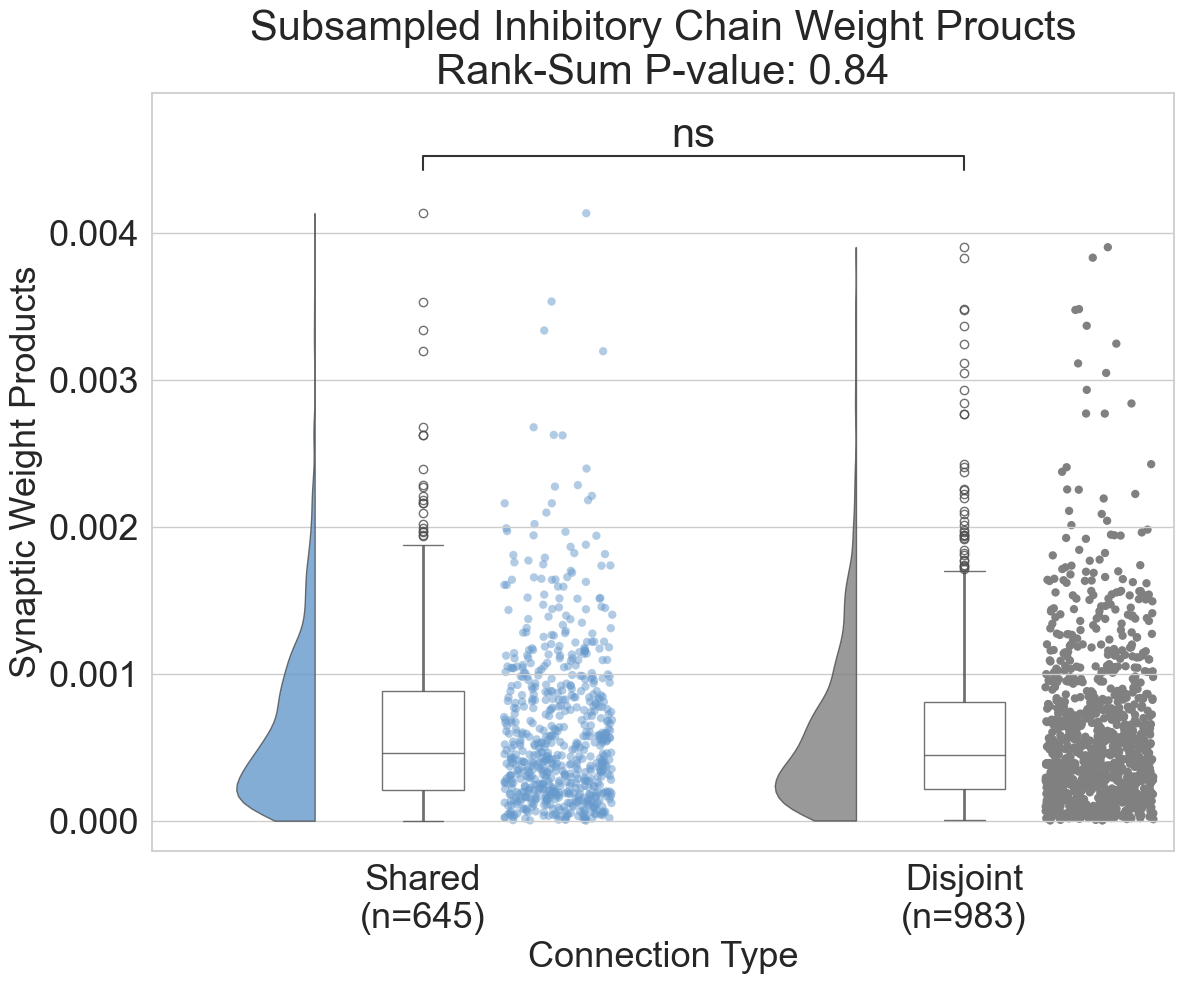

c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\trevo\anaconda3\envs\allen_env\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=645) vs. Disjoint
(n=983): Custom statistical test, P_val:8.395e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_23316\1161573534.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


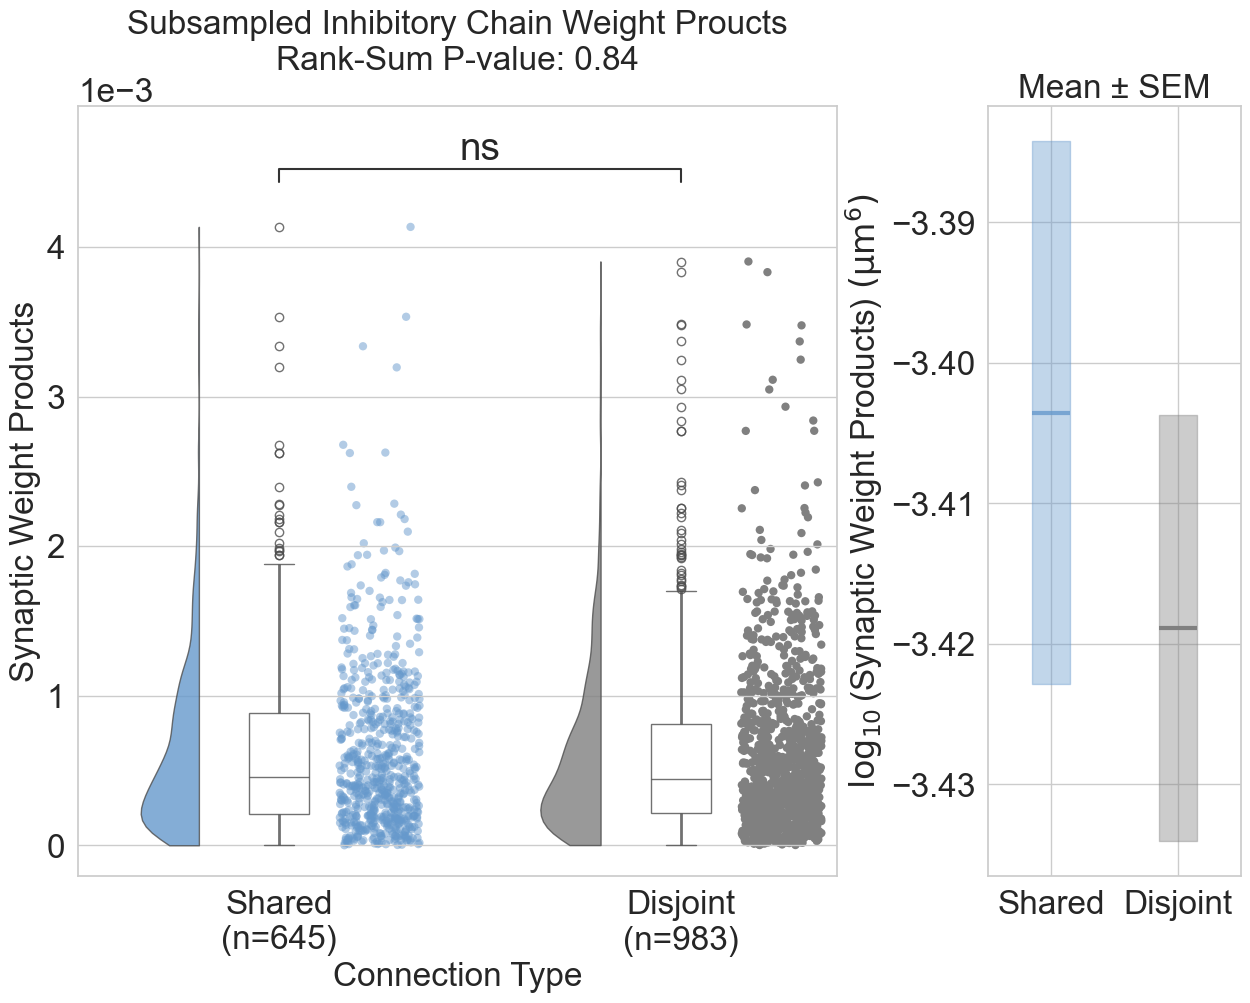


Resampling (B=10000) summary, resampling percentile CIs
Proportion significant (α=0.05): 0.0215
HL shift median: -4.51e-06 (95% CI -4.04e-05–3e-05)
PS median: 0.496 (95% CI 0.469–0.523)
Cohen's d median: -0.0127 (95% CI -0.108–0.0806)
δ median: -0.00701 (95% CI -0.0613–0.0468)


In [65]:
# ---------------- Helpers ----------------

def extract_vals_keys(dod):
    """Flatten dict-of-dicts into arrays (values) + arrays (keys) for each stratum."""
    vals, keys = {}, {}
    for k in ('shared', 'disjoint'):
        items = list(dod.get(k, {}).items())
        if items:
            k_arr, v_arr = zip(*items)         # tuples
            vals[k] = np.asarray(v_arr, dtype=float)
            keys[k] = np.asarray(k_arr, dtype=object)
        else:
            vals[k] = np.empty(0, float)
            keys[k] = np.empty(0, object)
    return vals, keys

def subsample_indices(n_avail, n_take, rng):
    if n_take > n_avail:
        raise ValueError(f"Requesting {n_take} from only {n_avail} available.")
    return rng.choice(n_avail, size=n_take, replace=False)

def build_dict_from_indices(keys, vals, idx_s, idx_d):
    """Rebuild dict-of-dicts for plotting/test function (keeps original (pre,post) keys)."""
    return {
        'shared':   {tuple(keys['shared'][i]): float(vals['shared'][i])     for i in idx_s},
        'disjoint': {tuple(keys['disjoint'][i]): float(vals['disjoint'][i]) for i in idx_d},
    }


def one_draw_stats(I_vals, n_shared, n_disjoint, rng):
    """One subsample: returns test results and effect sizes."""
    idx_s = subsample_indices(I_vals['shared'].size,   n_shared,   rng)
    idx_d = subsample_indices(I_vals['disjoint'].size, n_disjoint, rng)
    s = I_vals['shared'][idx_s]
    d = I_vals['disjoint'][idx_d]

    # Mann–Whitney U (direction shared < disjoint)
    U_s, p_mw = mannwhitneyu(s, d, alternative='less', method='asymptotic')
    n1, n2 = s.size, d.size
    delta = 1.0 - (2.0 * U_s) / (n1 * n2)

    # Other effect sizes
    d_cohen = cohens_d(s, d, alternative='less')
    HL = hodges_lehmann(s, d, alternative='less')
    PS, _ = ps_and_delta(s, d, alternative='less')

    return {
        "p": p_mw,
        "delta": delta,
        "d": d_cohen,
        "HL": HL,
        "PS": PS,
        "idx_s": idx_s,
        "idx_d": idx_d,
        "s": s,
        "d_vals": d,
    }


def resample_many(I_vals, n_shared, n_disjoint, B=10_000, rng=None):
    """Repeat subsampling many times: return arrays of effect sizes + p-values."""
    if rng is None:
        rng = default_rng()
    results = {"p": [], "delta": [], "d": [], "HL": [], "PS": []}
    for b in range(B):
        out = one_draw_stats(I_vals, n_shared, n_disjoint, rng)
        for k in results:
            results[k].append(out[k])
    return {k: np.array(v) for k, v in results.items()}


# ---------------- Subsampling Workflow ----------------

target = {'shared': 645, 'disjoint': 983}

# Flatten once
I_vals, I_keys = extract_vals_keys(W_pairwise['inhibitory'])
# ---- One subsample ----
rng = default_rng(747)
one = one_draw_stats(I_vals, target['shared'], target['disjoint'], rng)
I_sub_for_plot = build_dict_from_indices(I_keys, I_vals, one['idx_s'], one['idx_d'])

print("SUBSAMPLED")
ranksum_signedrank_two_group_comparison(
    I_sub_for_plot,
    aggregation_method='connection',
    data_type='summed_psd',
    non_zero=True,
    chain_test=True,
    chain_description="Inhibitory",
    save=True,
    figure_name='Subsampled_Nonzero_PSD_by_Conn_I_Chain',
    title_prefix="Subsampled "
)

# ---- Many subsamples ----
B = 10_000
res = resample_many(I_vals, target['shared'], target['disjoint'], B=B, rng=rng)

alpha = 0.05
prop_sig = (res['p'] < alpha).mean()

def summarize(arr):
    return np.median(arr), np.percentile(arr, [2.5, 97.5])

HL_med, HL_ci = summarize(res['HL'])
PS_med, PS_ci = summarize(res['PS'])
d_med, d_ci = summarize(res['d'])
delta_med, delta_ci = summarize(res['delta'])

print(f"\nResampling (B={B}) summary, resampling percentile CIs")
print(f"Proportion significant (α={alpha}): {prop_sig:.3g}")
print(f"HL shift median: {HL_med:.3g} (95% CI {HL_ci[0]:.3g}–{HL_ci[1]:.3g})")
print(f"PS median: {PS_med:.3g} (95% CI {PS_ci[0]:.3g}–{PS_ci[1]:.3g})")
print(f"Cohen's d median: {d_med:.3g} (95% CI {d_ci[0]:.3g}–{d_ci[1]:.3g})")
print(f"δ median: {delta_med:.3g} (95% CI {delta_ci[0]:.3g}–{delta_ci[1]:.3g})")
